# Problem Statement

Lending is one of the critical functions of any bank or financial institution. Customers are provided loans across different products (home loan, loan against property etc.) at competitive interest rates for an acceptable tenure. There is always a risk that a customer may default on the loan or may try and repay the loan in advance which leads to financial losses to the business.  

There may not be enough data or evidence available from the past which will help the firm to predict the loan default or prepayment and mitigate the above possible risk. However, it does have information about the customer demographics, loan details, EMI transactions etc. which contributes to more than 25-30 features (high-dimension data) related to a customer’s loan account. But due to high dimensions it is difficult to identify any patterns within the data. Unsupervised learning techniques like Principal Component Analysis comes to rescue here to reduce the high dimensionality and help in further analysis and pattern recognition.

## About Data

Data file contains information about the loan transactions done by the customer.

All important details regarding the loan i.e. loan amount, interest rate, outstanding principal, loan to value ratio (Net LTV), tenure, city where the loan was originated etc. has been provided.

Some of the features that correspond to multiple loan transactions (e.g. rate of interest, emi amount, frequency of emi payment etc.) for a loan account are summarized and captured for each loan account.

### Import  required libraries

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from factor_analyzer import FactorAnalyzer # Perform statistical tests before PCA
import warnings
warnings.filterwarnings("ignore")

### Read and view data

In [10]:
df = pd.read_excel('Short Term Home Loans.xlsx')

In [11]:
df.head()

,loan_account,age,gender,marital_status,qualification,gross_income,nettakehome,balance_tenure,city,completed_tenure,...,num_emi_changes,num_low_freq_transactions,num_of_emi_transactions,orignal_interest_rate,orignal_tenor,outstanding_principal,paid_interest,paid_principal,pre_emi_dueamt,pre_emi_received_amt
0,LA492,39,F,M,UG,63542.344735,63542.344735,111,MADURAI,70,...,11,10,73,17.479728,180,9.882910e+05,9.340537e+05,212745.625226,39959.331336,39959.331336
1,LA498,51,M,M,GRAD,81130.025032,81130.025032,107,MADURAI,68,...,3,11,73,17.479728,180,1.206218e+06,1.069305e+06,295078.188194,78774.632736,78774.632736
2,LA500,41,M,M,UG,56298.592500,56298.592500,50,MADURAI,70,...,13,10,73,17.479728,120,7.137100e+05,8.303592e+05,487326.621863,37918.629288,37918.629288
3,LA531,42,M,M,UG,74314.142100,74314.142100,110,MADURAI,70,...,13,17,72,17.479728,180,1.744746e+06,1.567354e+06,357068.193072,29375.950152,29375.950152
4,LA552,27,M,S,GRAD,64255.460240,64255.460240,112,MADURAI,69,...,14,10,71,17.479728,180,1.502039e+06,1.355995e+06,299516.018579,46048.309200,46048.309200


In [12]:
df.shape

(2319, 42)

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,2319.0,3.945106e+01,8.982396e+00,1.800000e+01,3.200000e+01,3.900000e+01,4.600000e+01,6.500000e+01
gross_income,2319.0,8.260822e+04,1.264007e+05,0.000000e+00,4.189591e+04,6.184963e+04,9.118946e+04,4.261664e+06
nettakehome,2319.0,8.134619e+04,1.268459e+05,0.000000e+00,4.109947e+04,6.050222e+04,9.046402e+04,4.261664e+06
balance_tenure,2319.0,1.466628e+02,4.513873e+01,0.000000e+00,1.290000e+02,1.500000e+02,1.670000e+02,3.070000e+02
completed_tenure,2319.0,2.950367e+01,1.349025e+01,0.000000e+00,2.200000e+01,2.800000e+01,3.700000e+01,7.000000e+01
current_interest_rate,2319.0,1.569870e+01,1.872893e+00,1.107466e+01,1.404621e+01,1.591904e+01,1.747973e+01,1.997683e+01
current_interest_rate_max,2319.0,1.578384e+01,1.832462e+00,1.107466e+01,1.435835e+01,1.591904e+01,1.747973e+01,1.997683e+01
current_interest_rate_min,2319.0,1.568473e+01,1.875045e+00,1.107466e+01,1.404621e+01,1.591904e+01,1.747973e+01,1.997683e+01
current_tenor,2319.0,1.759711e+02,4.224263e+01,1.000000e+01,1.730000e+02,1.800000e+02,1.810000e+02,3.160000e+02
diff_current_interest_rate_max_min,2319.0,1.042883e-01,5.631563e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.201107e+01


In [14]:
df.city.value_counts()

,count
city,
MUMBAI,586
HYDERABAD,268
AHMEDABAD,165
CHENNAI,164
MADURAI,157
COIMBATORE,156
SURAT,136
ERODE,85
PUNE,78


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2319 entries, 0 to 2318
Data columns (total 42 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   loan_account                         2319 non-null   object 
 1   age                                  2319 non-null   int64  
 2   gender                               2319 non-null   object 
 3   marital_status                       2319 non-null   object 
 4   qualification                        2319 non-null   object 
 5   gross_income                         2319 non-null   float64
 6   nettakehome                          2319 non-null   float64
 7   balance_tenure                       2319 non-null   int64  
 8   city                                 2319 non-null   object 
 9   completed_tenure                     2319 non-null   int64  
 10  current_interest_rate                2319 non-null   float64
 11  current_interest_rate_max     

In [16]:
df.gender.value_counts()

,count
gender,
M,1994
F,325


In [17]:
df.marital_status.value_counts()

,count
marital_status,
M,2086
S,233


In [18]:
df.qualification.value_counts()

,count
qualification,
UG,1548
GRAD,409
POSTGRAD,181
OTHERS,150
PRF,18
ENG,6
MAT,5
DOCTRATE,2


#### Observations:

- Data consists of 2319 customer loan transactions with 42 features

- Fields *‘diff_current_interest_rate_max_min’, ‘diff_original_current_interest_rate’, ‘diff_original_current_tenor’* have atleast 75% of the values as 0

- Field *'excess_adjusted_amt'* has atleast 50% of values as 0

- *'gross_income'* & *'nettakehome'* have minimum values as 0. Needs to be cleaned

- There are no missing values in the data

- We have 5 categorical fields *'gender', 'marital status', 'city' and 'qualification'*. *'city'* field needs cleanup.

- Very few observations available for customers with *ENG, MAT, DOCTRATE* qualification

### Data Cleanup

In [19]:
df.city.replace(to_replace='Mum',value='MUMBAI',inplace=True)
df.city.replace(to_replace='Hyd',value='HYDERABAD',inplace=True)
df.city.value_counts()

,count
city,
MUMBAI,607
HYDERABAD,299
AHMEDABAD,165
CHENNAI,164
MADURAI,157
COIMBATORE,156
SURAT,136
ERODE,85
TIRUCHIRAPPALLI,78


In [20]:
print('% of records with 0 value in diff_current_interest_rate_max_min field: {:.2%}'.format((df[df.diff_current_interest_rate_max_min == 0].shape[0])/df.shape[0]))
print('# of records with 0 value in diff_original_current_interest_rate field: {:.2%}'.format((df[df.diff_original_current_interest_rate == 0].shape[0])/df.shape[0]))
print('# of records with 0 value in diff_original_current_tenor field: {:.2%}'.format((df[df.diff_original_current_tenor == 0].shape[0])/df.shape[0]))
print('# of records with 0 value in excess_adjusted_amt field: {:.2%}'.format((df[df.excess_adjusted_amt == 0].shape[0])/df.shape[0]))

% of records with 0 value in diff_current_interest_rate_max_min field: 95.30%
# of records with 0 value in diff_original_current_interest_rate field: 96.03%
# of records with 0 value in diff_original_current_tenor field: 72.49%
# of records with 0 value in excess_adjusted_amt field: 67.96%


In [21]:
df.drop(['diff_current_interest_rate_max_min','diff_original_current_interest_rate','diff_original_current_tenor','excess_adjusted_amt'], axis=1, inplace=True)

In [22]:
df[df.gross_income==0]

,loan_account,age,gender,marital_status,qualification,gross_income,nettakehome,balance_tenure,city,completed_tenure,...,num_emi_changes,num_low_freq_transactions,num_of_emi_transactions,orignal_interest_rate,orignal_tenor,outstanding_principal,paid_interest,paid_principal,pre_emi_dueamt,pre_emi_received_amt
106,LA928,29,F,M,GRAD,0.0,0.0,159,COIMBATORE,21,...,1,1,21,17.479728,180,8.944886e+05,228711.906059,36314.844106,6923.810520,6923.810520
616,LA2297,54,F,M,UG,0.0,0.0,87,NAMAKKAL,45,...,3,4,46,17.479728,132,1.217339e+06,730542.546646,283956.588908,12884.692368,12884.692368
640,LA2348,46,M,M,OTHERS,0.0,0.0,138,MUMBAI,42,...,5,4,43,17.479728,180,6.839979e+05,361987.939409,66650.027041,12884.692368,12884.692368
1198,LA3410,35,M,M,GRAD,0.0,0.0,153,MUMBAI,28,...,4,4,35,14.670486,180,2.328519e+06,783168.969620,163632.234425,177258.383520,177258.383520
2315,LA5726,34,M,M,UG,0.0,0.0,240,MUMBAI,0,...,7,8,18,14.358348,240,1.280237e+06,130587.212571,0.000000,316114.464864,192106.478616


In [23]:
df[df.nettakehome==0]

,loan_account,age,gender,marital_status,qualification,gross_income,nettakehome,balance_tenure,city,completed_tenure,...,num_emi_changes,num_low_freq_transactions,num_of_emi_transactions,orignal_interest_rate,orignal_tenor,outstanding_principal,paid_interest,paid_principal,pre_emi_dueamt,pre_emi_received_amt
8,LA570,44,M,M,GRAD,90077.748000,0.0,0,CHENNAI,49,...,2,6,50,17.479728,180,0.000000e+00,1.213050e+06,3.753240e+06,10737.979824,10737.979824
106,LA928,29,F,M,GRAD,0.000000,0.0,159,COIMBATORE,21,...,1,1,21,17.479728,180,8.944886e+05,2.287119e+05,3.631484e+04,6923.810520,6923.810520
307,LA1496,25,F,S,GRAD,75759.889955,0.0,186,CHENNAI,54,...,2,1,55,17.479728,240,3.396424e+06,2.233865e+06,2.066864e+05,30919.728000,30919.728000
395,LA1783,44,M,M,OTHERS,15012.958000,0.0,138,HYDERABAD,42,...,9,6,50,17.479728,180,2.081138e+06,1.138929e+06,1.708054e+05,282875.757264,282875.757264
521,LA2100,34,M,S,UG,40228.722257,0.0,85,TUTICORIN,40,...,15,11,46,17.479728,156,8.974986e+05,5.893742e+05,3.035380e+05,106719.441192,106719.441192
545,LA2147,47,M,M,OTHERS,105090.706000,0.0,120,CHENNAI,45,...,3,2,46,17.479728,180,2.635998e+06,1.503699e+06,4.416587e+05,26412.073368,26412.073368
616,LA2297,54,F,M,UG,0.000000,0.0,87,NAMAKKAL,45,...,3,4,46,17.479728,132,1.217339e+06,7.305425e+05,2.839566e+05,12884.692368,12884.692368
640,LA2348,46,M,M,OTHERS,0.000000,0.0,138,MUMBAI,42,...,5,4,43,17.479728,180,6.839979e+05,3.619879e+05,6.665003e+04,12884.692368,12884.692368
662,LA2392,60,M,M,GRAD,89787.997911,0.0,53,MADURAI,44,...,4,2,45,14.982624,96,1.195590e+06,6.926213e+05,6.254819e+05,23227.341384,23227.341384
664,LA2395,48,F,M,UG,30660.964123,0.0,196,HYDERABAD,44,...,18,10,45,14.358348,240,1.084249e+06,4.744590e+05,6.574324e+04,14053.016376,14053.016376


In [24]:
df.gross_income.replace(to_replace=0, value=df.gross_income.median(),inplace=True)
df.nettakehome.replace(to_replace=0, value=df.nettakehome.median(),inplace=True)

### EDA

#### Univariate Analysis

Let us define a function **'univariateAnalysis_numeric'** to display information as part of univariate analysis of numeric variables. The function will accept coulmn name and number of bins as arguments.

The function will display the statistical description of the the numeric variable, histogram or distplot to view the distribution and the box plot to view 5 point summary and outliers if any.

In [25]:
def univariateAnalysis_numeric(column,nbins):
    print("Description of " + column)
    print("----------------------------------------------------------------------------")
    print(df[column].describe(),end=' ')


    plt.figure(figsize=[25,10])
    print("Distribution of " + column)
    print("----------------------------------------------------------------------------")
    a=round(df[column].min())
    b=round(df[column].max())
    freq, bins, patches = plt.hist(df[column], bins=nbins, range=[a,b], edgecolor='Black', color='cyan')
    bin_centers = np.diff(bins)*0.5 + bins[:-1]
    n = 0
    for fr, x, patch in zip(freq, bin_centers, patches):
      height = int(freq[n])
      plt.annotate("{}".format(height),
               xy = (x, height),             # top left corner of the histogram bar
               xytext = (0,0.2),             # offsetting label position above its bar
               textcoords = "offset points", # Offset (in points) from the *xy* value
               ha = 'center', va = 'bottom'
               )
      n = n+1

    #plt.legend()
    #plt.xticks(range(a,b,round((b-a)/nbins)))
    plt.show;
    plt.figure()
    print("BoxPlot of " + column)
    print("----------------------------------------------------------------------------")
    ax = sns.boxplot(x=df[column])
    #ax.legend()
    plt.show()

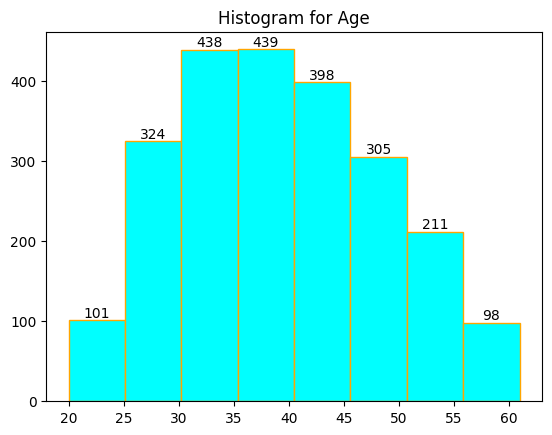

In [26]:
freq, bins, patches = plt.hist(df['age'], 8, range=[20, 61], edgecolor='Orange', color='cyan')
bin_centers = np.diff(bins)*0.5 + bins[:-1]
n = 0
for fr, x, patch in zip(freq, bin_centers, patches):
      height = int(freq[n])
      plt.annotate("{}".format(height),
               xy = (x, height),             # top left corner of the histogram bar
               xytext = (0,0.2),             # offsetting label position above its bar
               textcoords = "offset points", # Offset (in points) from the *xy* value
               ha = 'center', va = 'bottom'
               )
      n = n+1
plt.title('Histogram for Age')
plt.xticks(range(20,61,5))
plt.show()

In [27]:
df_num = df.select_dtypes(include = ['float64', 'int64'])
lstnumericcolumns = list(df_num.columns.values)
len(lstnumericcolumns)

33

In [28]:
df_num.head()

,age,gross_income,nettakehome,balance_tenure,completed_tenure,current_interest_rate,current_interest_rate_max,current_interest_rate_min,current_tenor,diff_emi_amount_max_min,...,num_emi_changes,num_low_freq_transactions,num_of_emi_transactions,orignal_interest_rate,orignal_tenor,outstanding_principal,paid_interest,paid_principal,pre_emi_dueamt,pre_emi_received_amt
0,39,63542.344735,63542.344735,111,70,17.479728,17.479728,17.479728,181,11557.38,...,11,10,73,17.479728,180,9.882910e+05,9.340537e+05,212745.625226,39959.331336,39959.331336
1,51,81130.025032,81130.025032,107,68,14.982624,17.479728,14.982624,175,13523.09,...,3,11,73,17.479728,180,1.206218e+06,1.069305e+06,295078.188194,78774.632736,78774.632736
2,41,56298.592500,56298.592500,50,70,17.479728,17.479728,17.479728,120,13608.59,...,13,10,73,17.479728,120,7.137100e+05,8.303592e+05,487326.621863,37918.629288,37918.629288
3,42,74314.142100,74314.142100,110,70,17.479728,17.479728,17.479728,180,38412.99,...,13,17,72,17.479728,180,1.744746e+06,1.567354e+06,357068.193072,29375.950152,29375.950152
4,27,64255.460240,64255.460240,112,69,17.479728,17.479728,17.479728,181,32346.11,...,14,10,71,17.479728,180,1.502039e+06,1.355995e+06,299516.018579,46048.309200,46048.309200


Description of age
----------------------------------------------------------------------------
count    2319.000000
mean       39.451056
std         8.982396
min        18.000000
25%        32.000000
50%        39.000000
75%        46.000000
max        65.000000
Name: age, dtype: float64 Distribution of age
----------------------------------------------------------------------------
BoxPlot of age
----------------------------------------------------------------------------


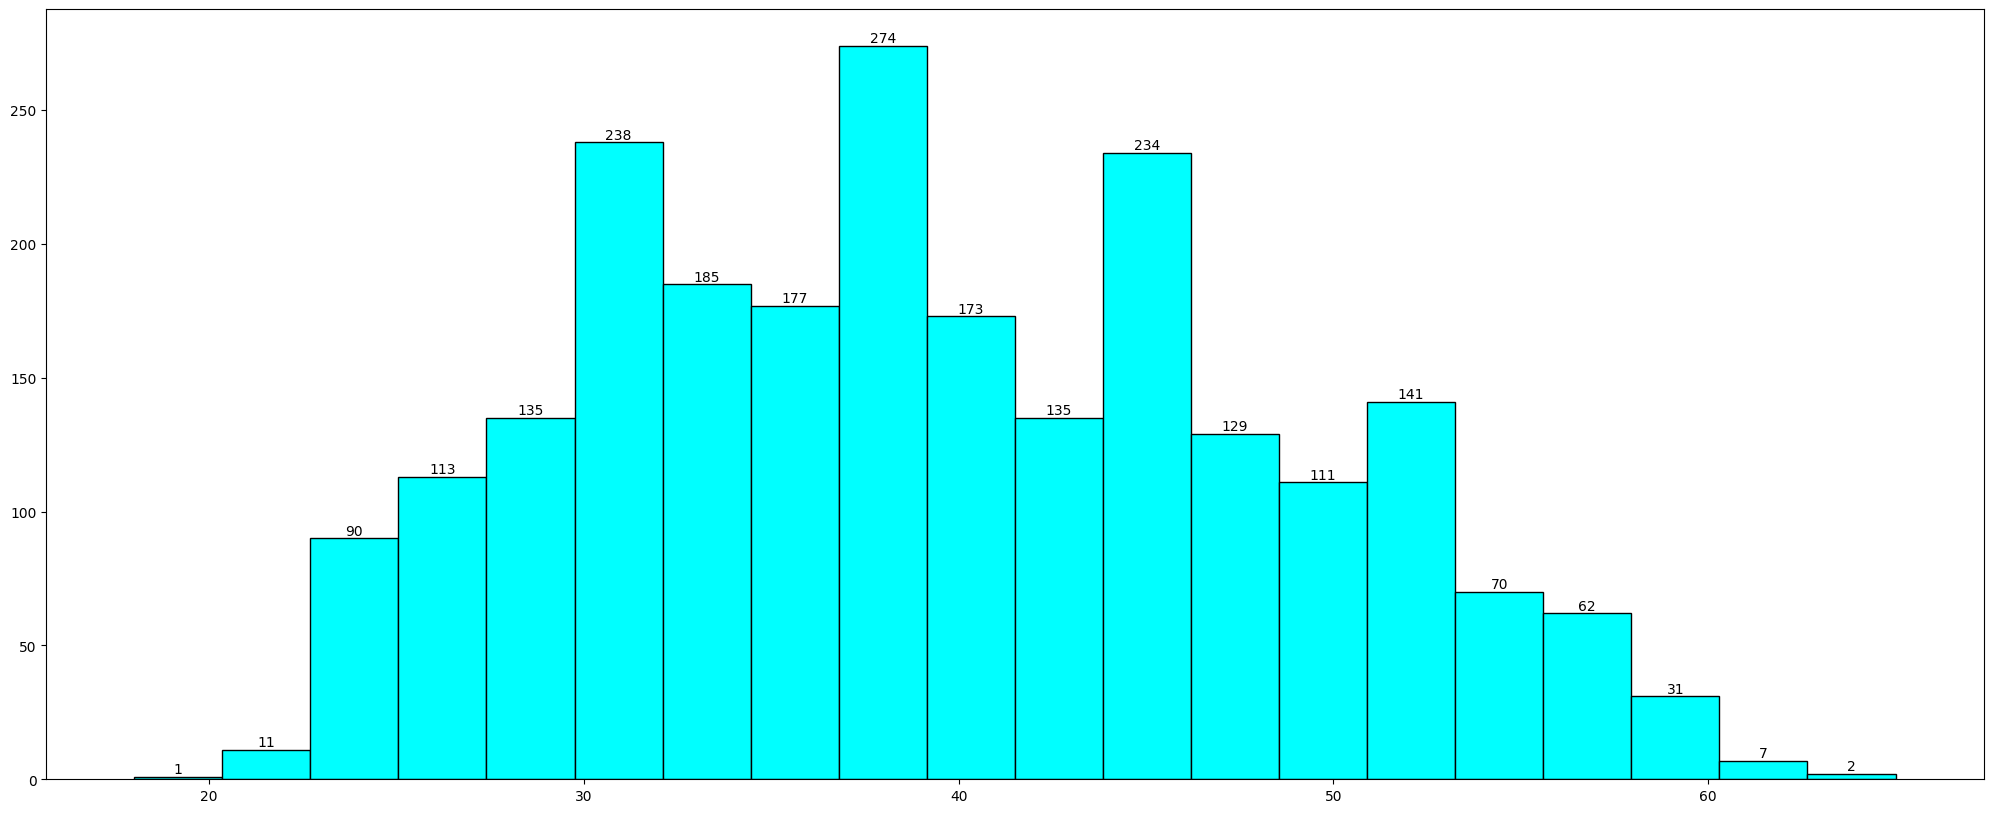

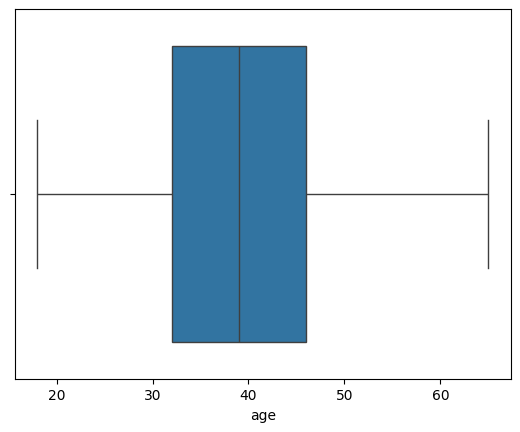

Description of gross_income
----------------------------------------------------------------------------
count    2.319000e+03
mean     8.274157e+04
std      1.263460e+05
min      1.250579e+01
25%      4.203628e+04
50%      6.184963e+04
75%      9.118946e+04
max      4.261664e+06
Name: gross_income, dtype: float64 Distribution of gross_income
----------------------------------------------------------------------------
BoxPlot of gross_income
----------------------------------------------------------------------------


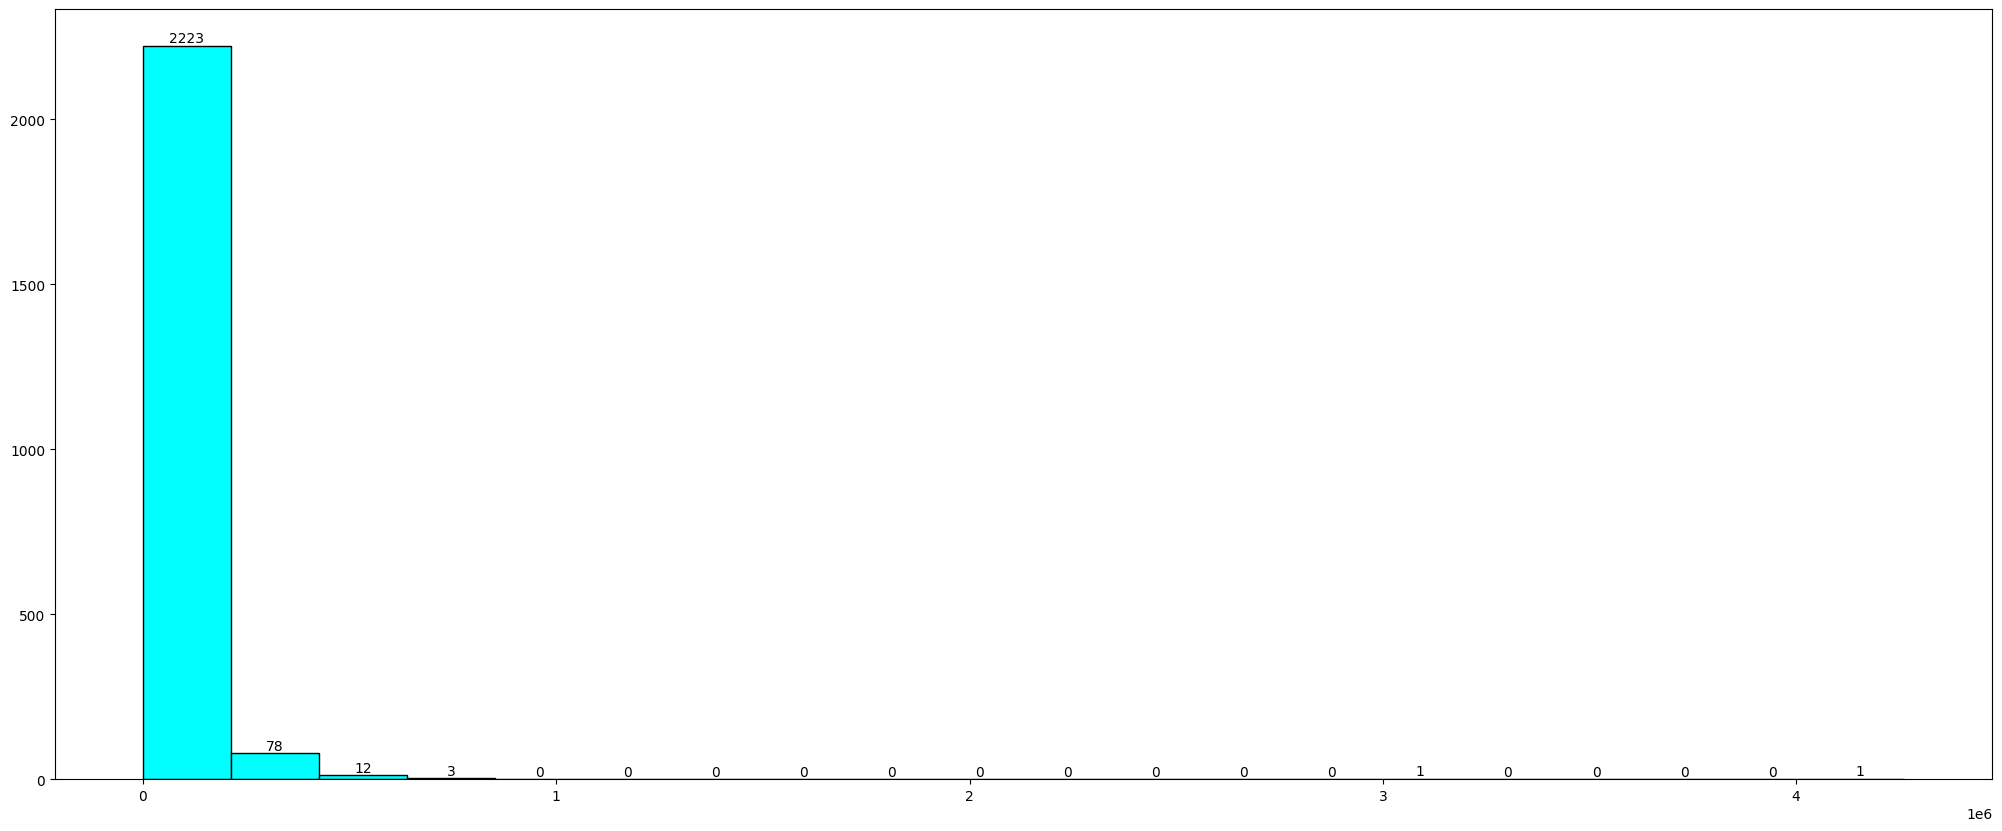

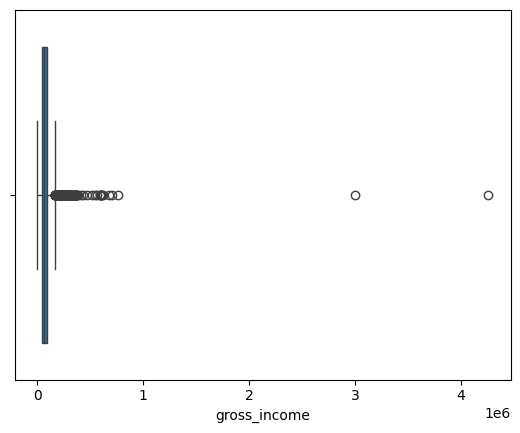

Description of nettakehome
----------------------------------------------------------------------------
count    2.319000e+03
mean     8.194625e+04
std      1.266025e+05
min      1.246076e-01
25%      4.198749e+04
50%      6.050222e+04
75%      9.046402e+04
max      4.261664e+06
Name: nettakehome, dtype: float64 Distribution of nettakehome
----------------------------------------------------------------------------
BoxPlot of nettakehome
----------------------------------------------------------------------------


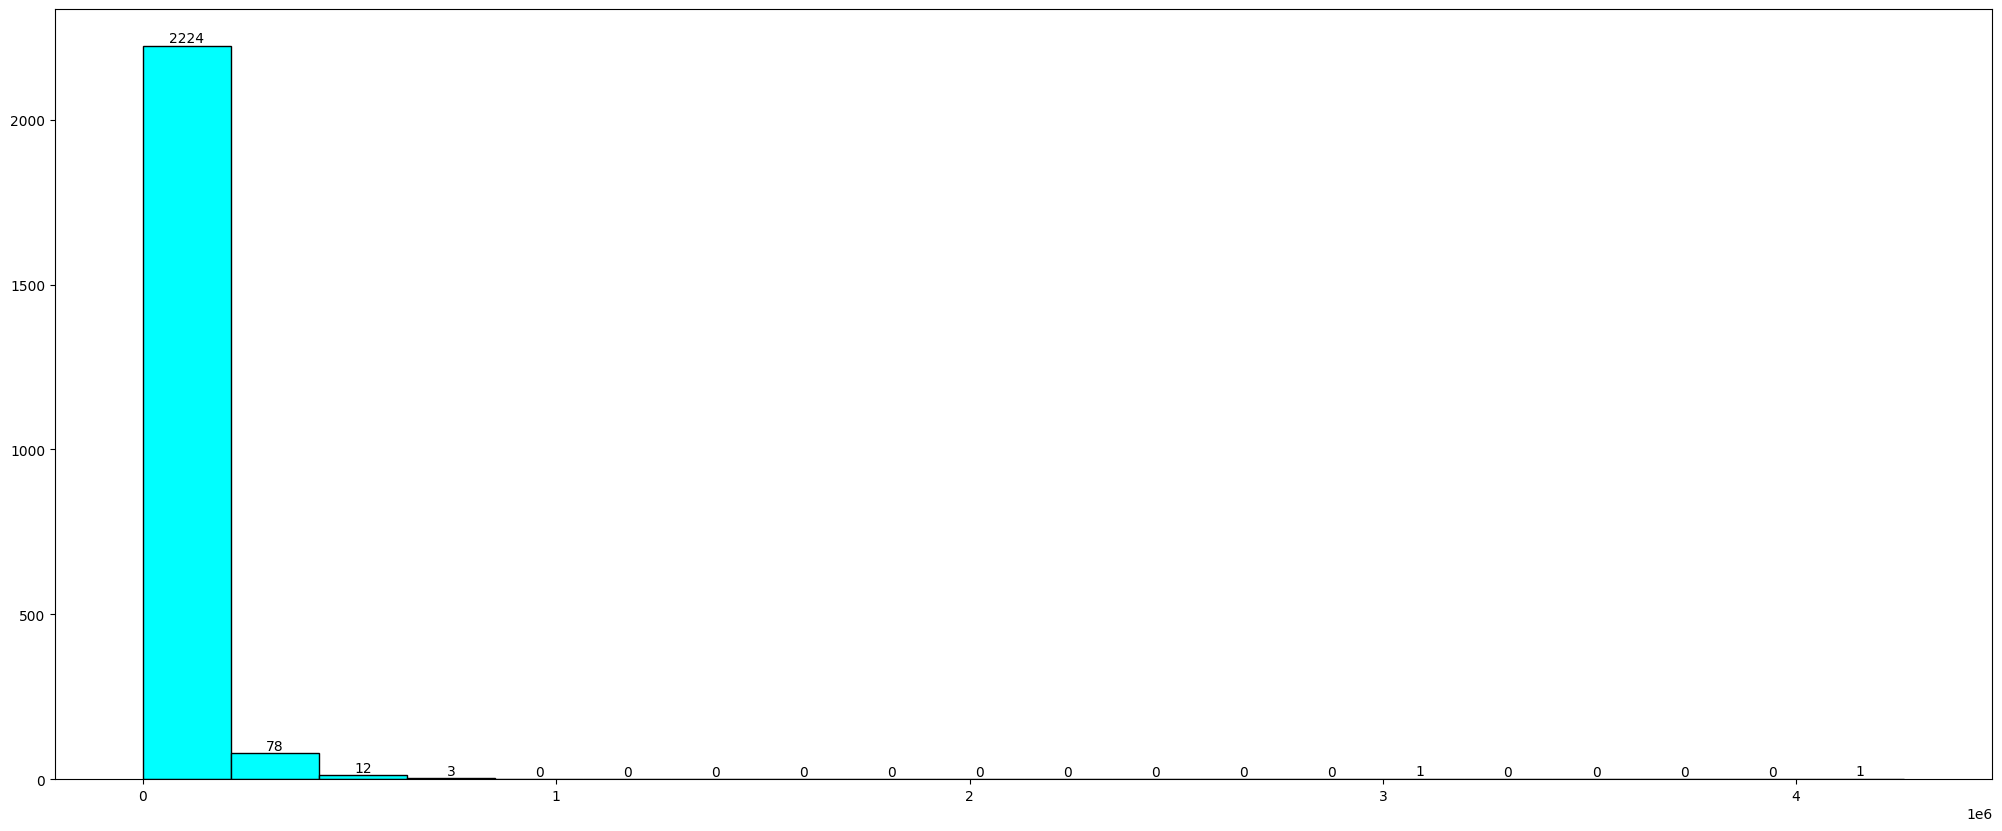

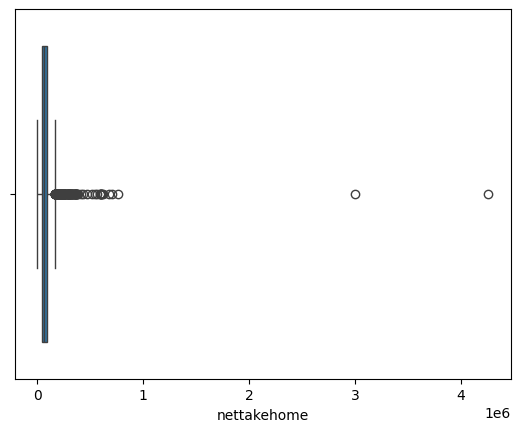

Description of balance_tenure
----------------------------------------------------------------------------
count    2319.000000
mean      146.662786
std        45.138729
min         0.000000
25%       129.000000
50%       150.000000
75%       167.000000
max       307.000000
Name: balance_tenure, dtype: float64 Distribution of balance_tenure
----------------------------------------------------------------------------
BoxPlot of balance_tenure
----------------------------------------------------------------------------


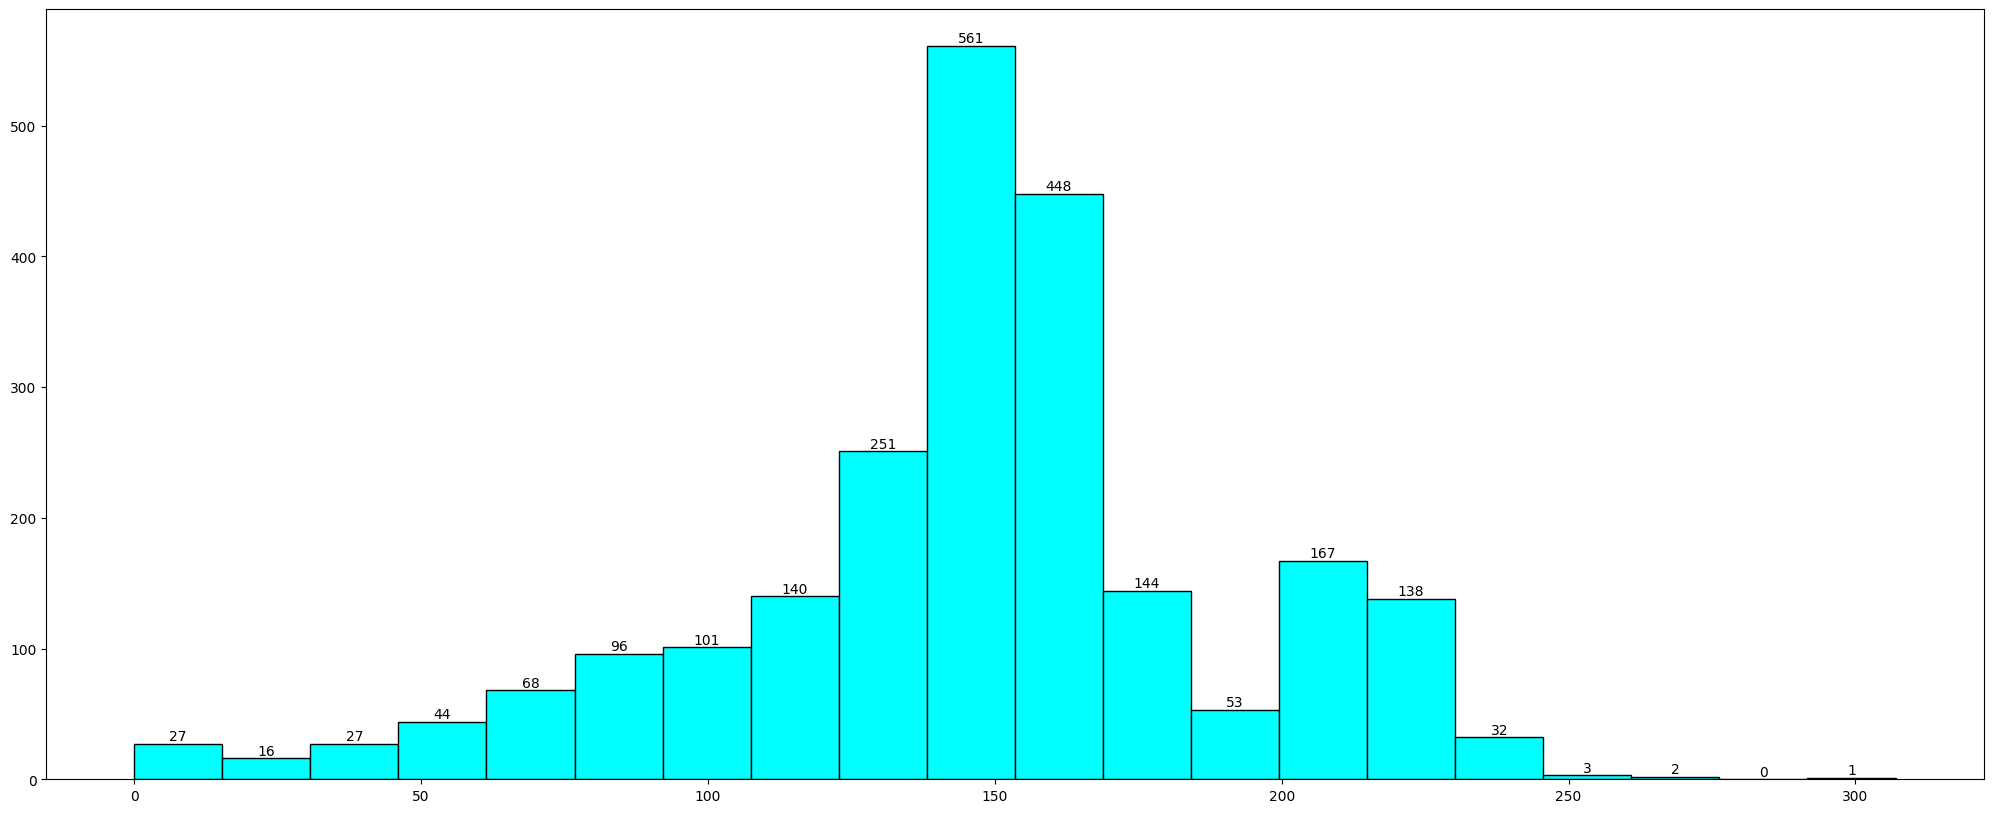

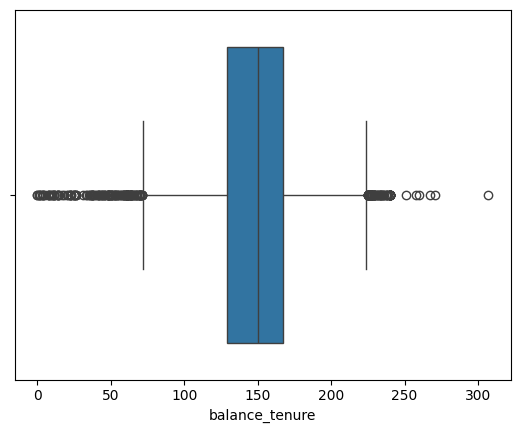

Description of completed_tenure
----------------------------------------------------------------------------
count    2319.000000
mean       29.503665
std        13.490253
min         0.000000
25%        22.000000
50%        28.000000
75%        37.000000
max        70.000000
Name: completed_tenure, dtype: float64 Distribution of completed_tenure
----------------------------------------------------------------------------
BoxPlot of completed_tenure
----------------------------------------------------------------------------


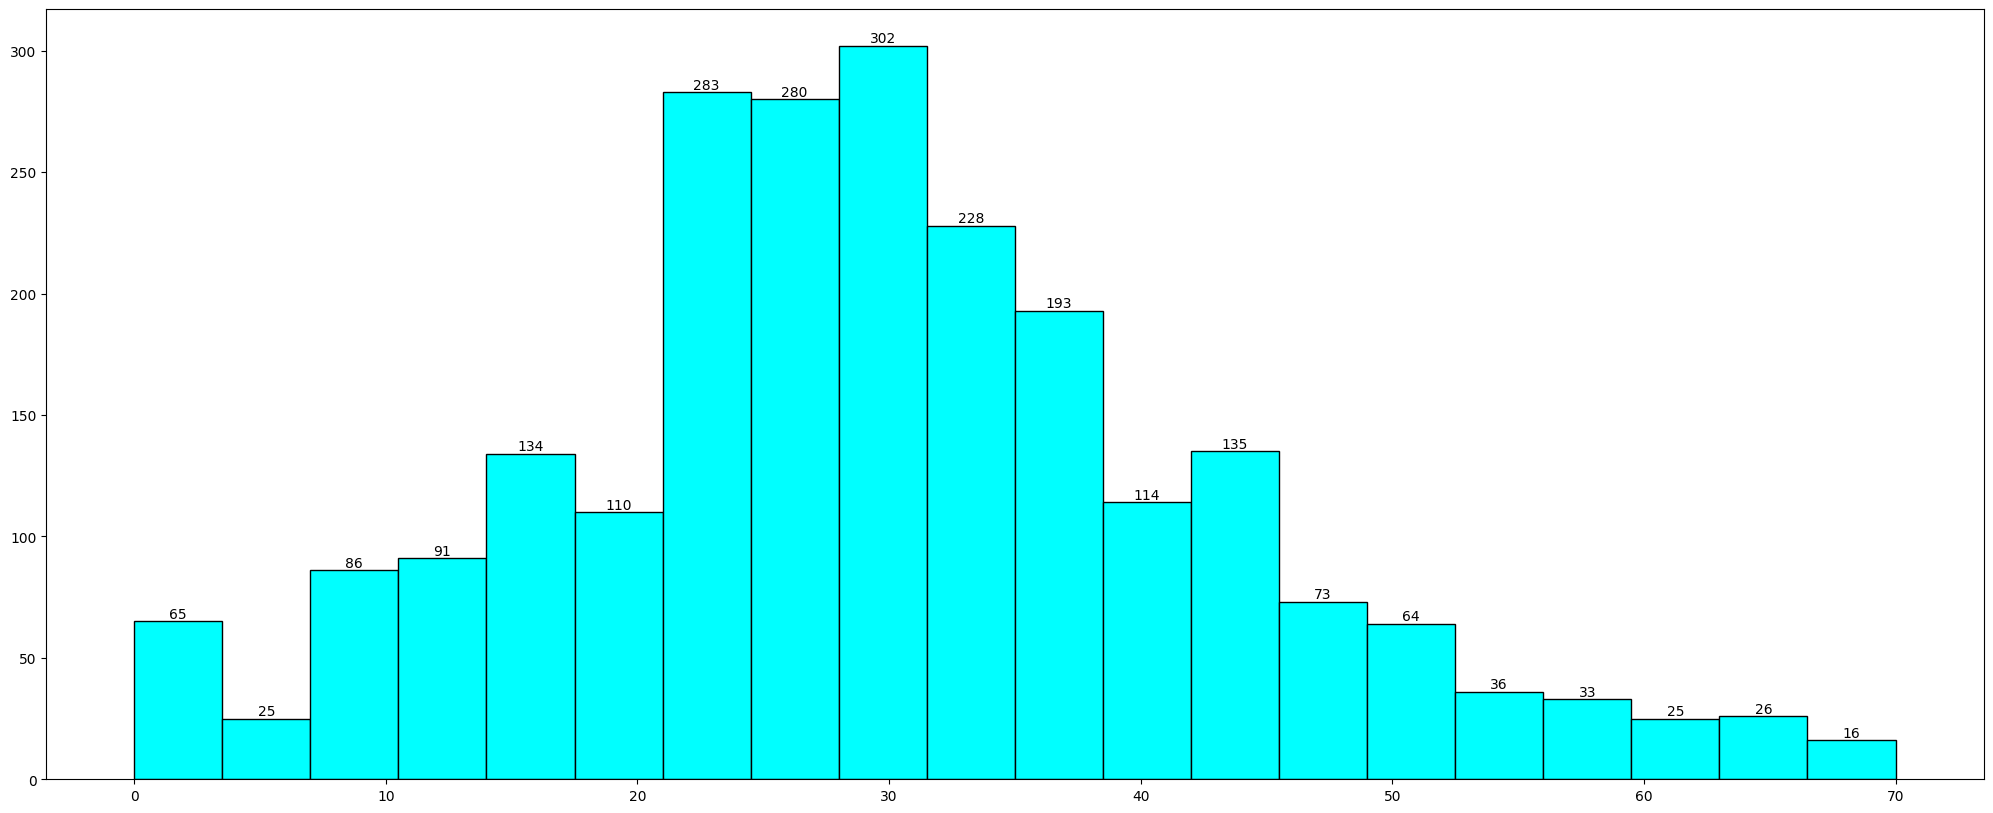

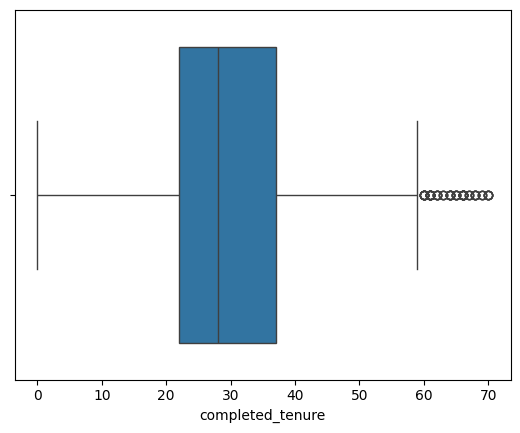

Description of current_interest_rate
----------------------------------------------------------------------------
count    2319.000000
mean       15.698703
std         1.872893
min        11.074656
25%        14.046210
50%        15.919038
75%        17.479728
max        19.976832
Name: current_interest_rate, dtype: float64 Distribution of current_interest_rate
----------------------------------------------------------------------------
BoxPlot of current_interest_rate
----------------------------------------------------------------------------


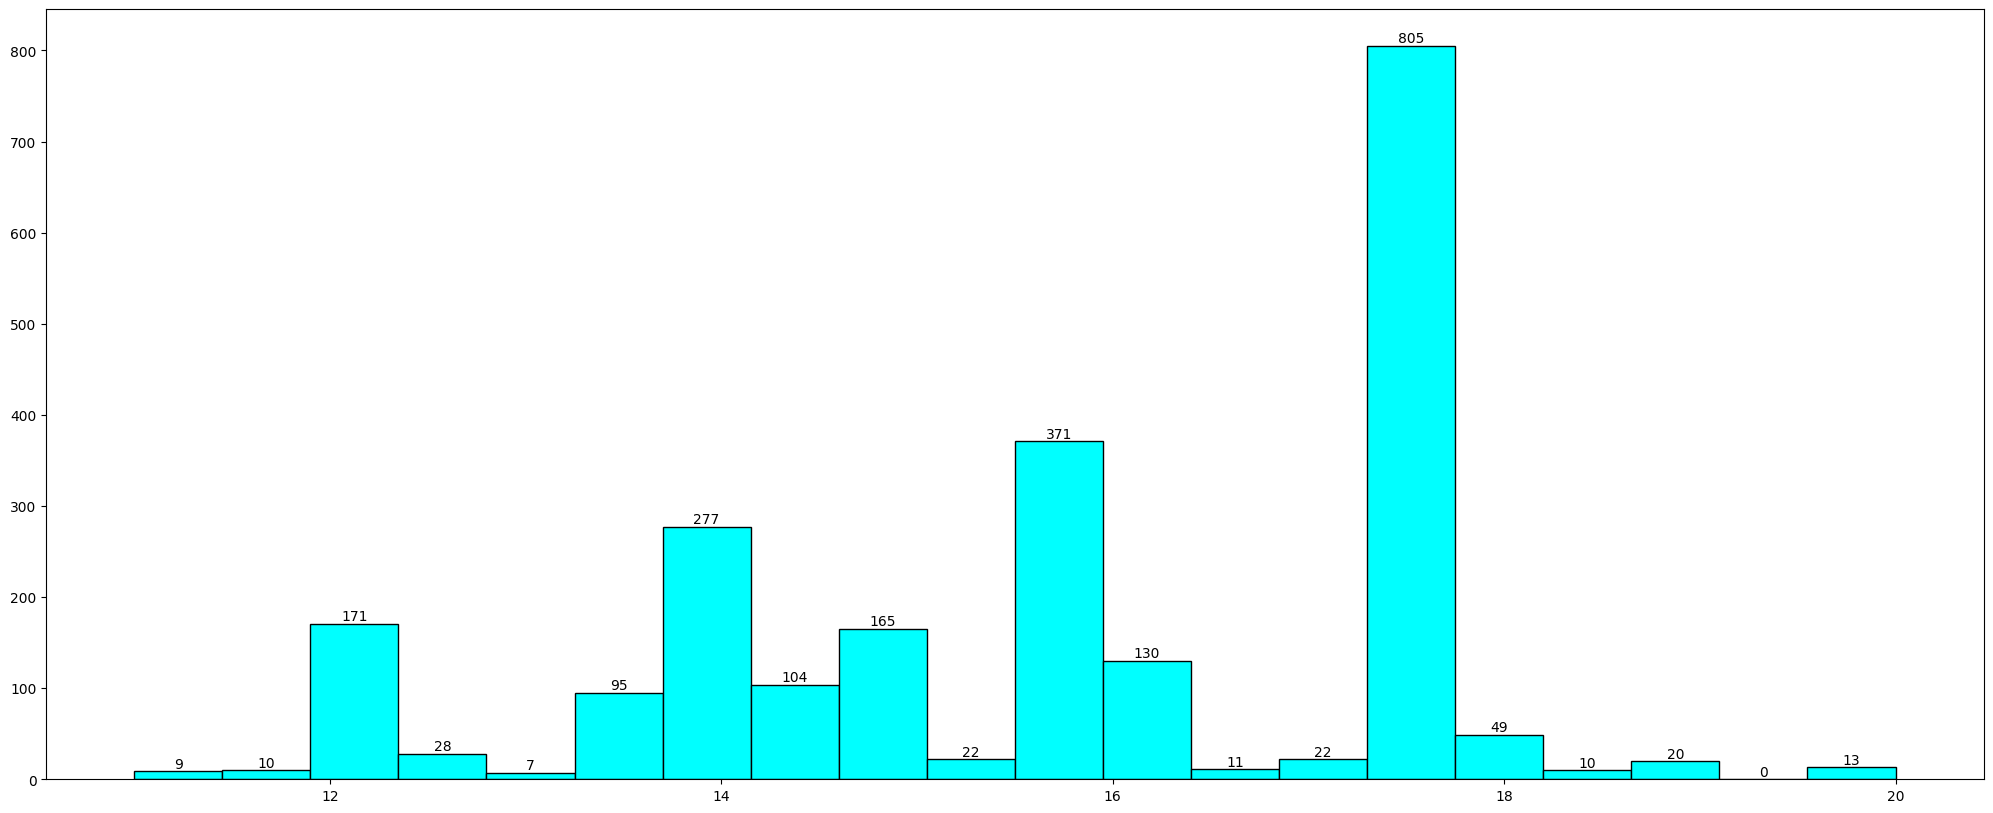

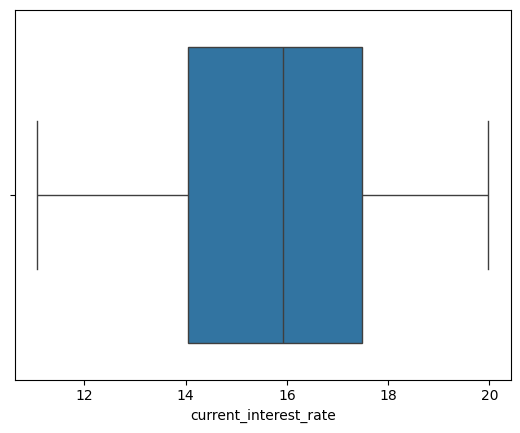

Description of current_interest_rate_max
----------------------------------------------------------------------------
count    2319.000000
mean       15.783840
std         1.832462
min        11.074656
25%        14.358348
50%        15.919038
75%        17.479728
max        19.976832
Name: current_interest_rate_max, dtype: float64 Distribution of current_interest_rate_max
----------------------------------------------------------------------------
BoxPlot of current_interest_rate_max
----------------------------------------------------------------------------


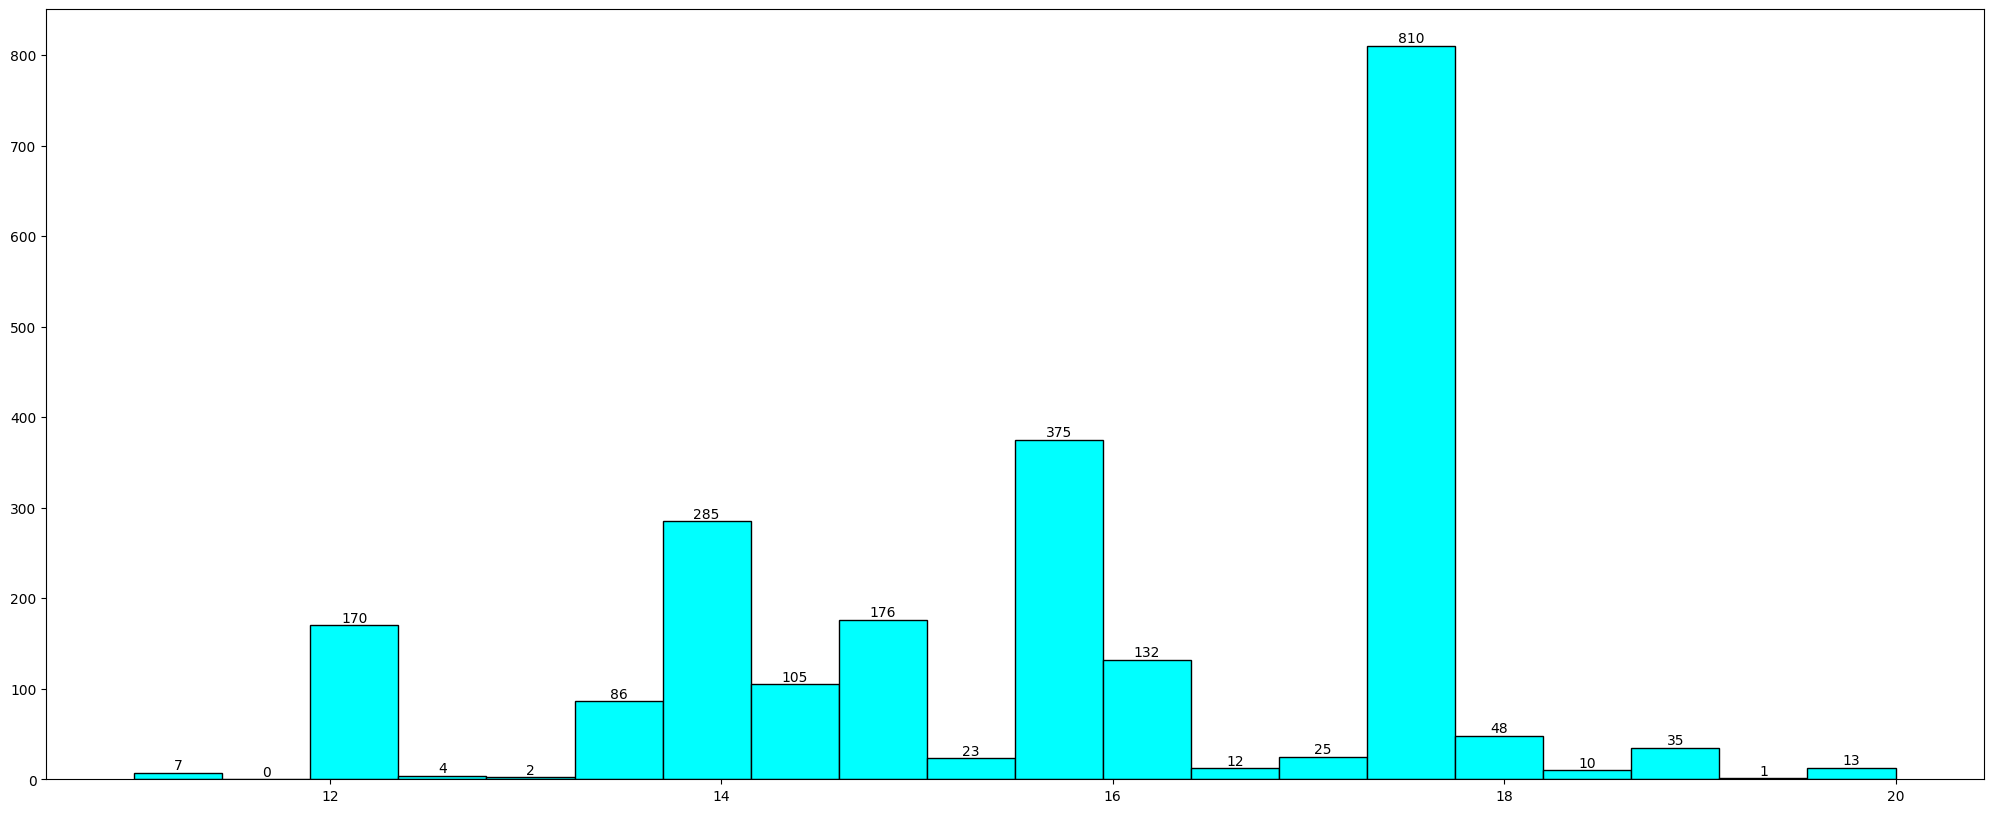

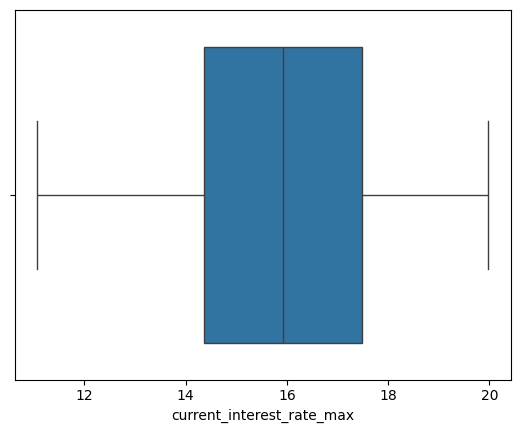

Description of current_interest_rate_min
----------------------------------------------------------------------------
count    2319.000000
mean       15.684731
std         1.875045
min        11.074656
25%        14.046210
50%        15.919038
75%        17.479728
max        19.976832
Name: current_interest_rate_min, dtype: float64 Distribution of current_interest_rate_min
----------------------------------------------------------------------------
BoxPlot of current_interest_rate_min
----------------------------------------------------------------------------


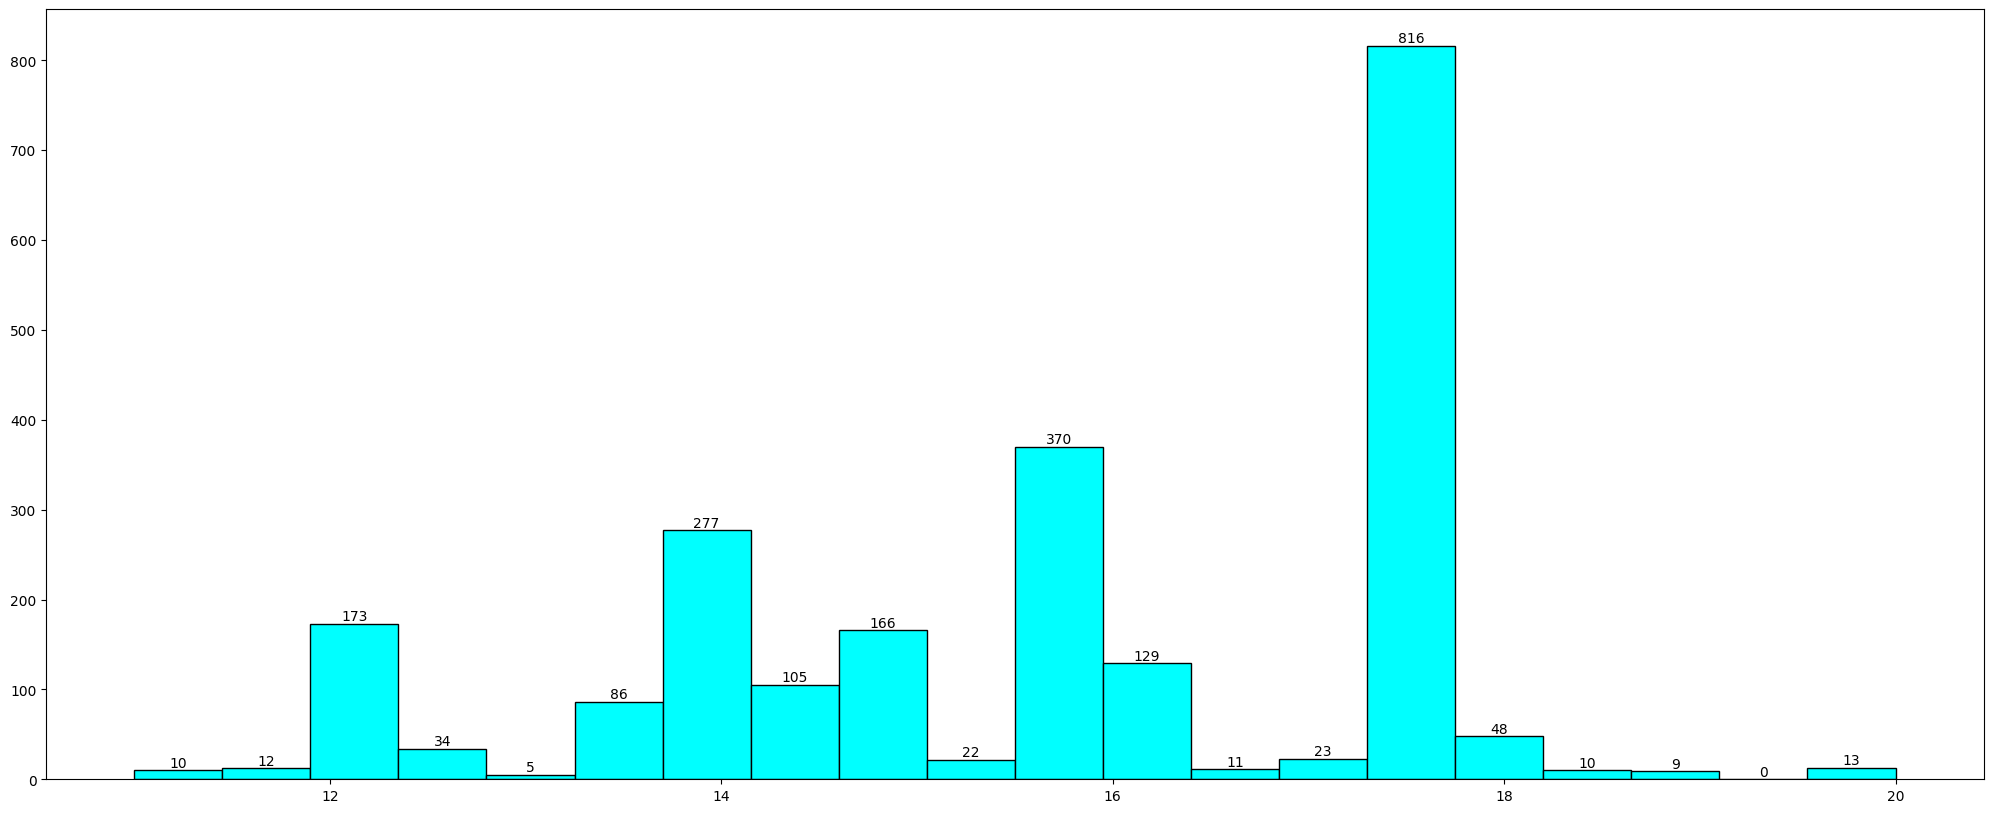

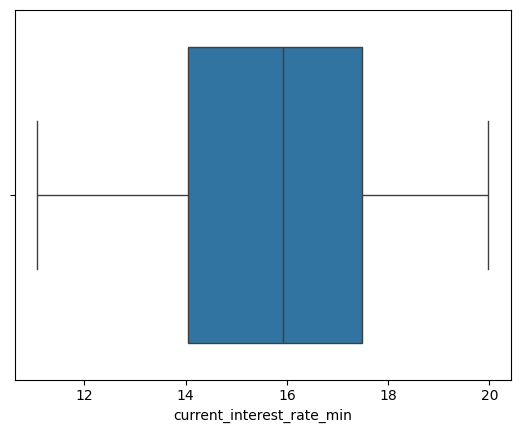

Description of current_tenor
----------------------------------------------------------------------------
count    2319.000000
mean      175.971108
std        42.242628
min        10.000000
25%       173.000000
50%       180.000000
75%       181.000000
max       316.000000
Name: current_tenor, dtype: float64 Distribution of current_tenor
----------------------------------------------------------------------------
BoxPlot of current_tenor
----------------------------------------------------------------------------


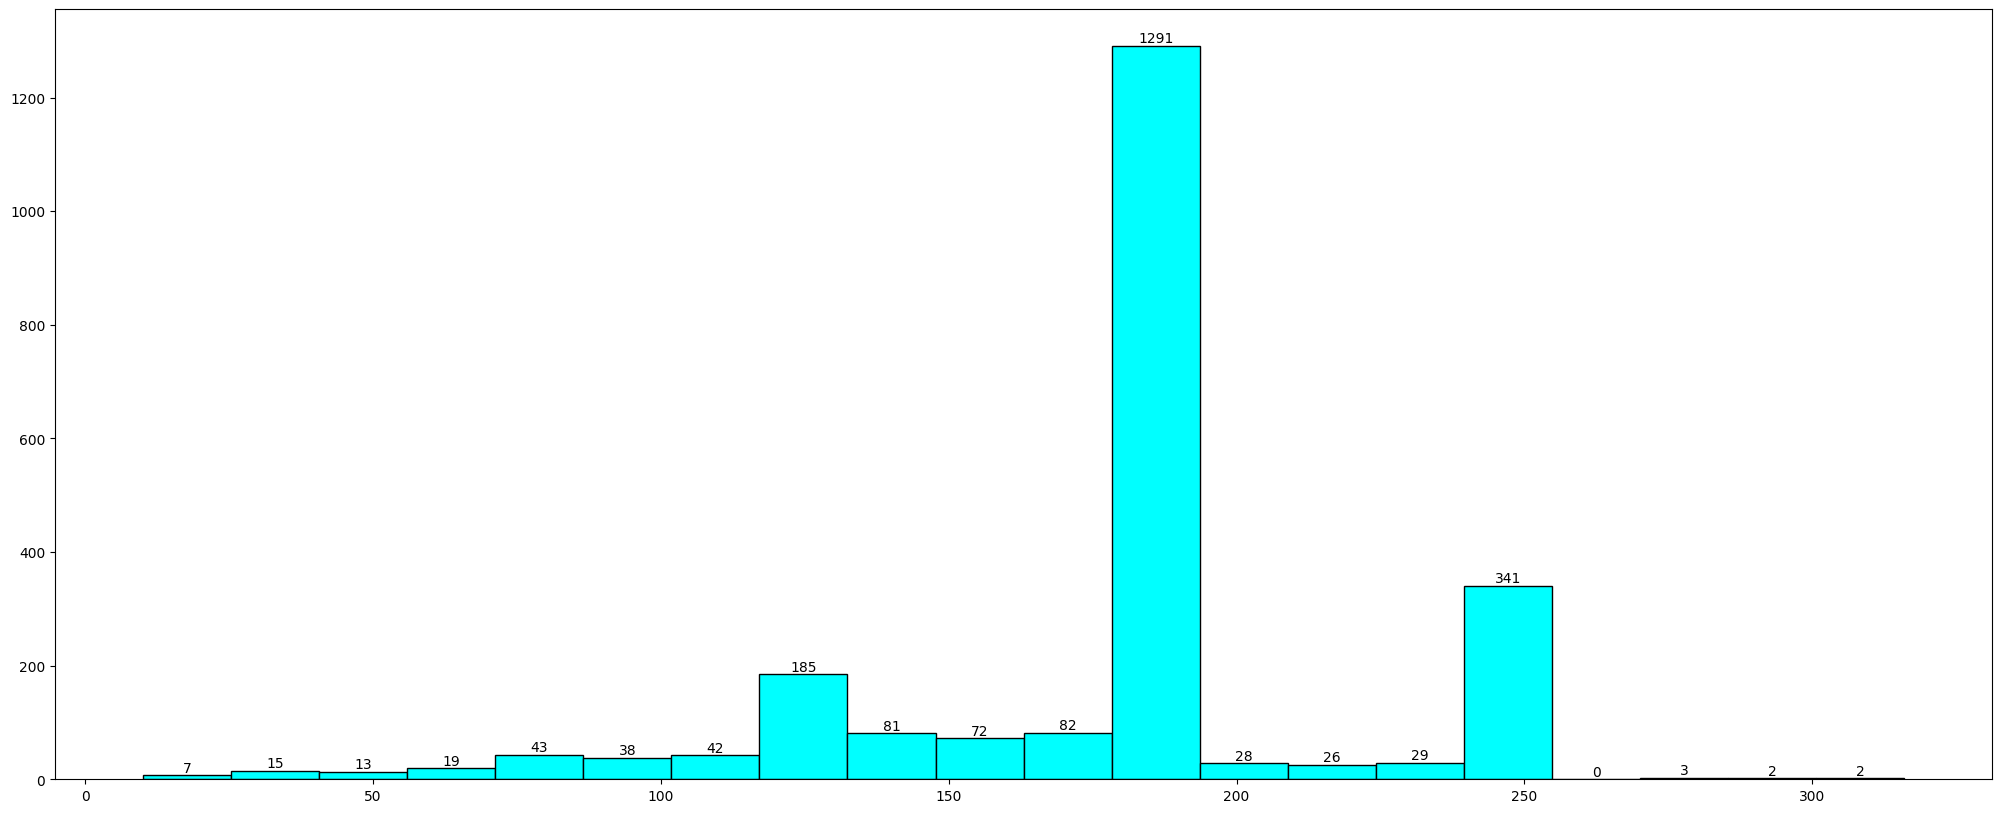

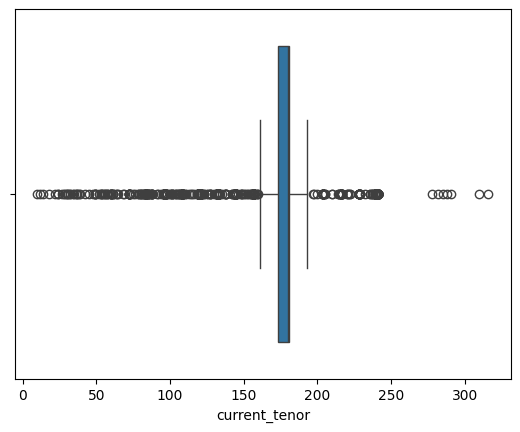

Description of diff_emi_amount_max_min
----------------------------------------------------------------------------
count    2.319000e+03
mean     5.635589e+04
std      1.959045e+05
min      0.000000e+00
25%      1.029850e+04
50%      1.735000e+04
75%      2.860478e+04
max      3.229383e+06
Name: diff_emi_amount_max_min, dtype: float64 Distribution of diff_emi_amount_max_min
----------------------------------------------------------------------------
BoxPlot of diff_emi_amount_max_min
----------------------------------------------------------------------------


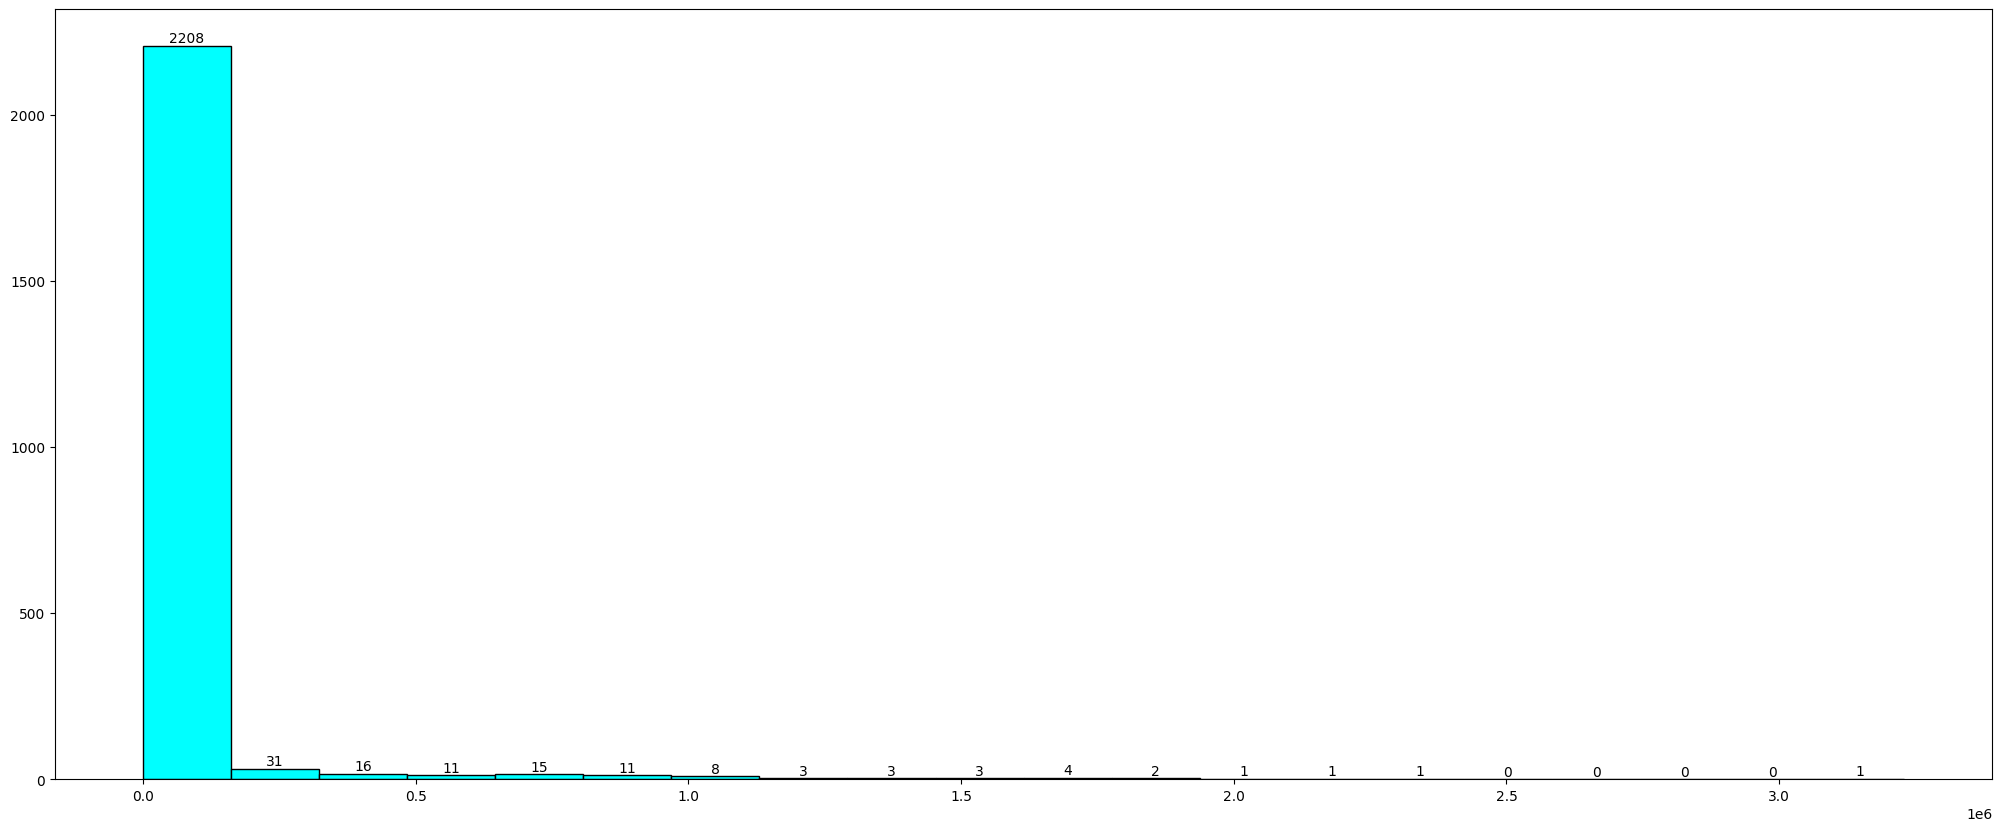

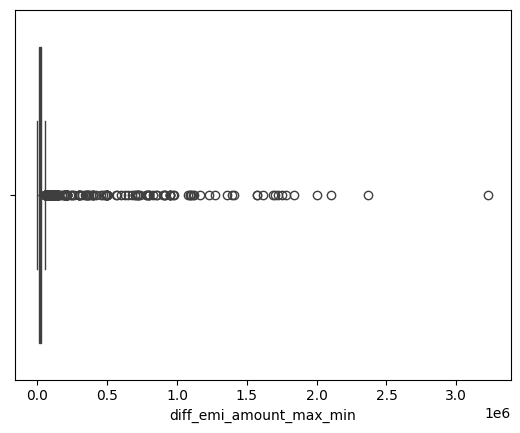

Description of emi_amount
----------------------------------------------------------------------------
count      2319.000000
mean      18012.023109
std       12373.175124
min          14.370000
25%        9727.000000
50%       14650.000000
75%       22640.000000
max      120000.000000
Name: emi_amount, dtype: float64 Distribution of emi_amount
----------------------------------------------------------------------------
BoxPlot of emi_amount
----------------------------------------------------------------------------


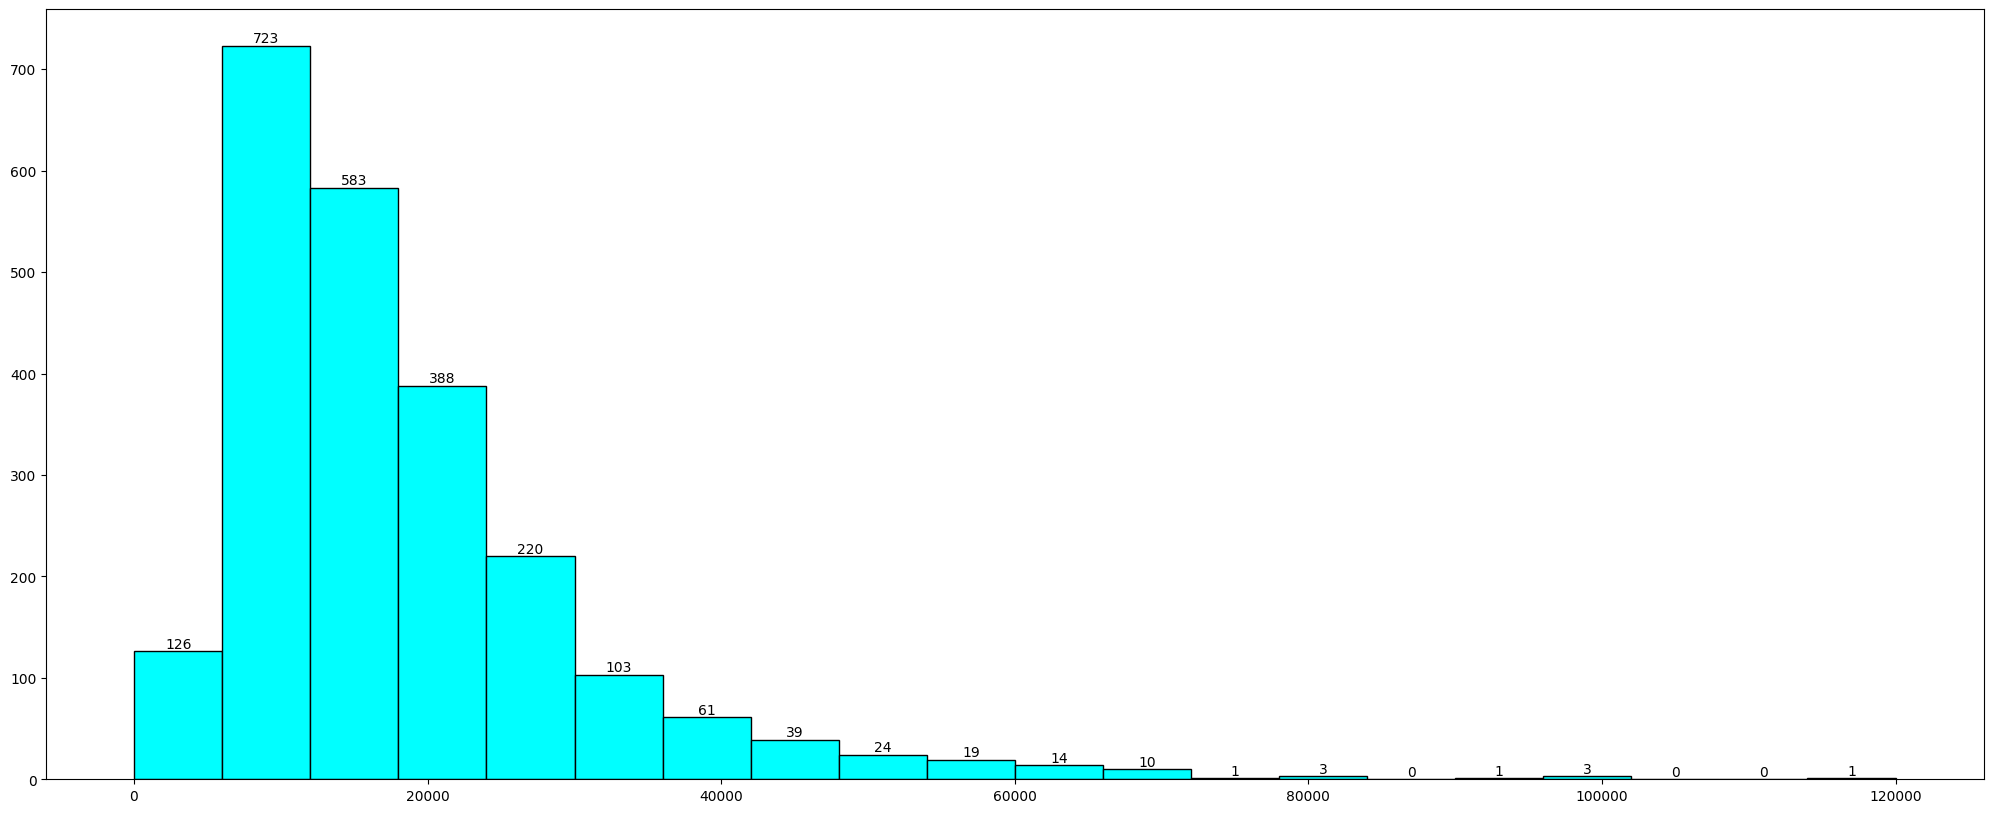

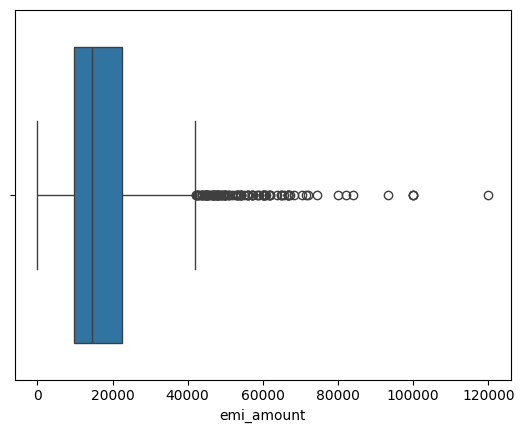

Description of emi_dueamt
----------------------------------------------------------------------------
count    2.319000e+03
mean     1.191197e+06
std      1.064387e+06
min      0.000000e+00
25%      5.517018e+05
50%      8.936884e+05
75%      1.453225e+06
max      9.853225e+06
Name: emi_dueamt, dtype: float64 Distribution of emi_dueamt
----------------------------------------------------------------------------
BoxPlot of emi_dueamt
----------------------------------------------------------------------------


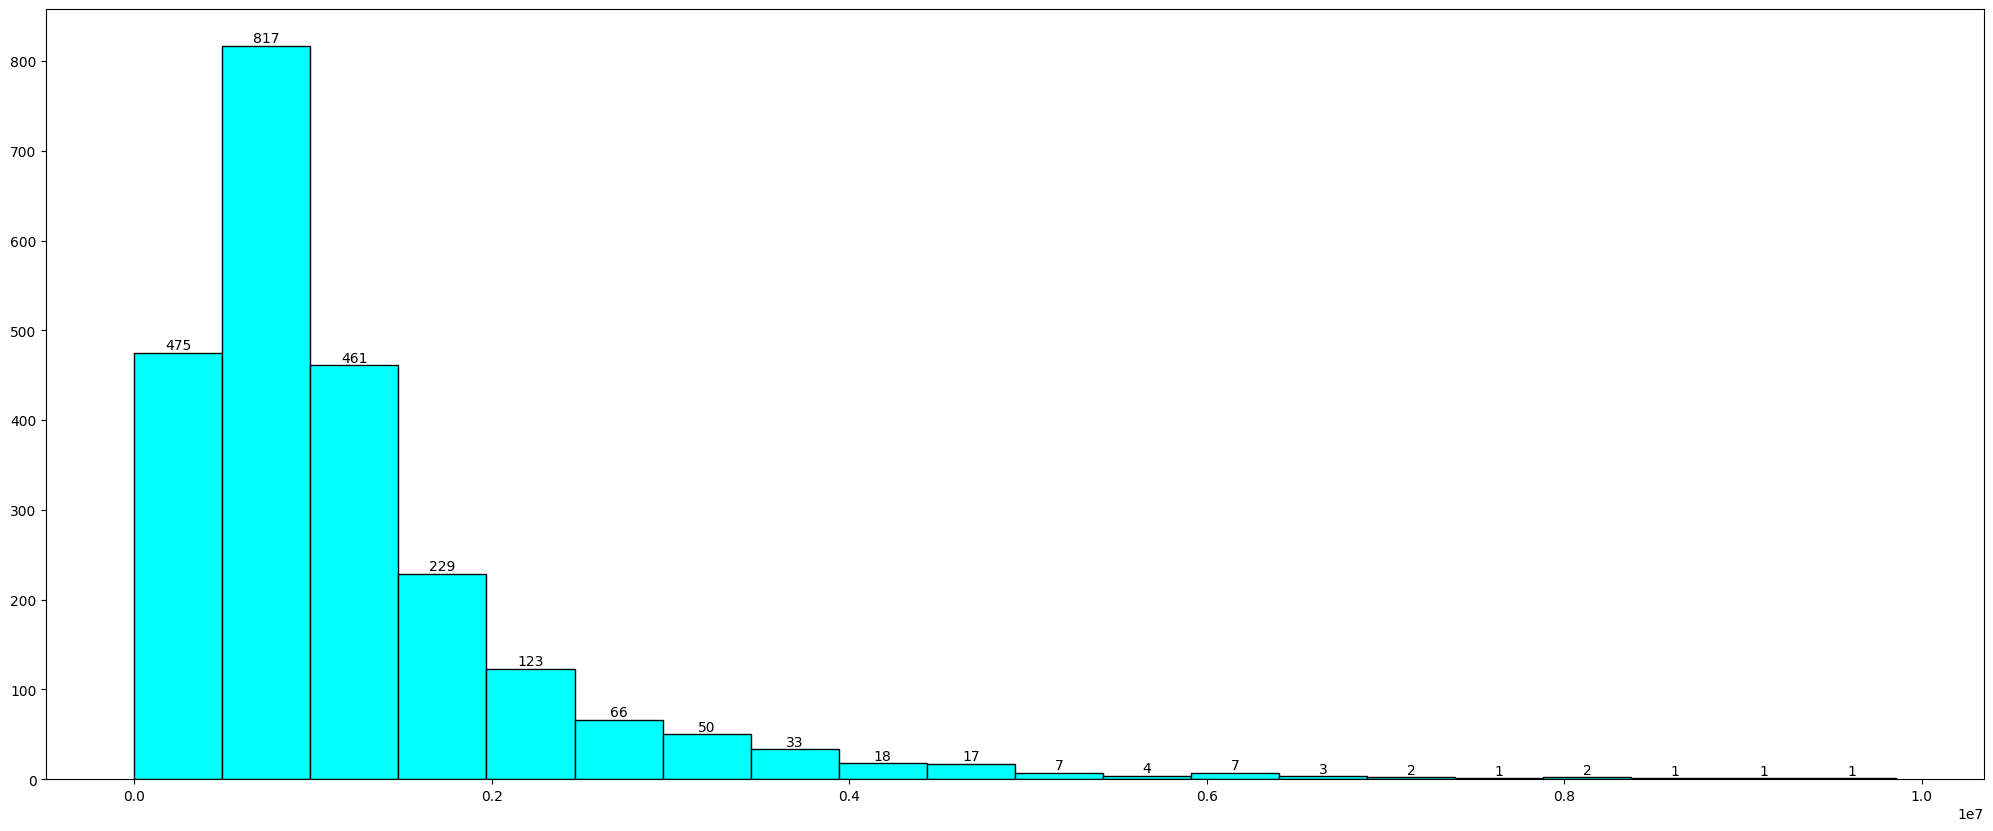

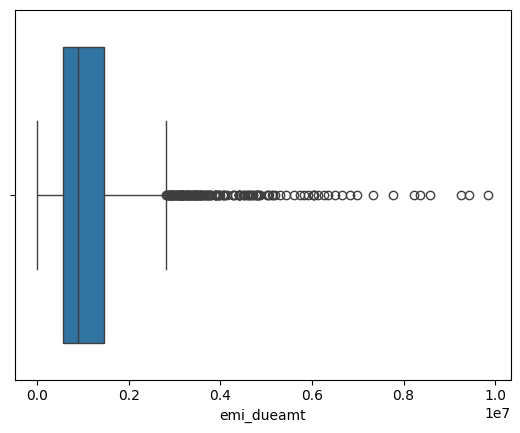

Description of emi_received_amt
----------------------------------------------------------------------------
count    2.319000e+03
mean     1.132347e+06
std      9.800945e+05
min      0.000000e+00
25%      5.325923e+05
50%      8.662891e+05
75%      1.397185e+06
max      9.853225e+06
Name: emi_received_amt, dtype: float64 Distribution of emi_received_amt
----------------------------------------------------------------------------
BoxPlot of emi_received_amt
----------------------------------------------------------------------------


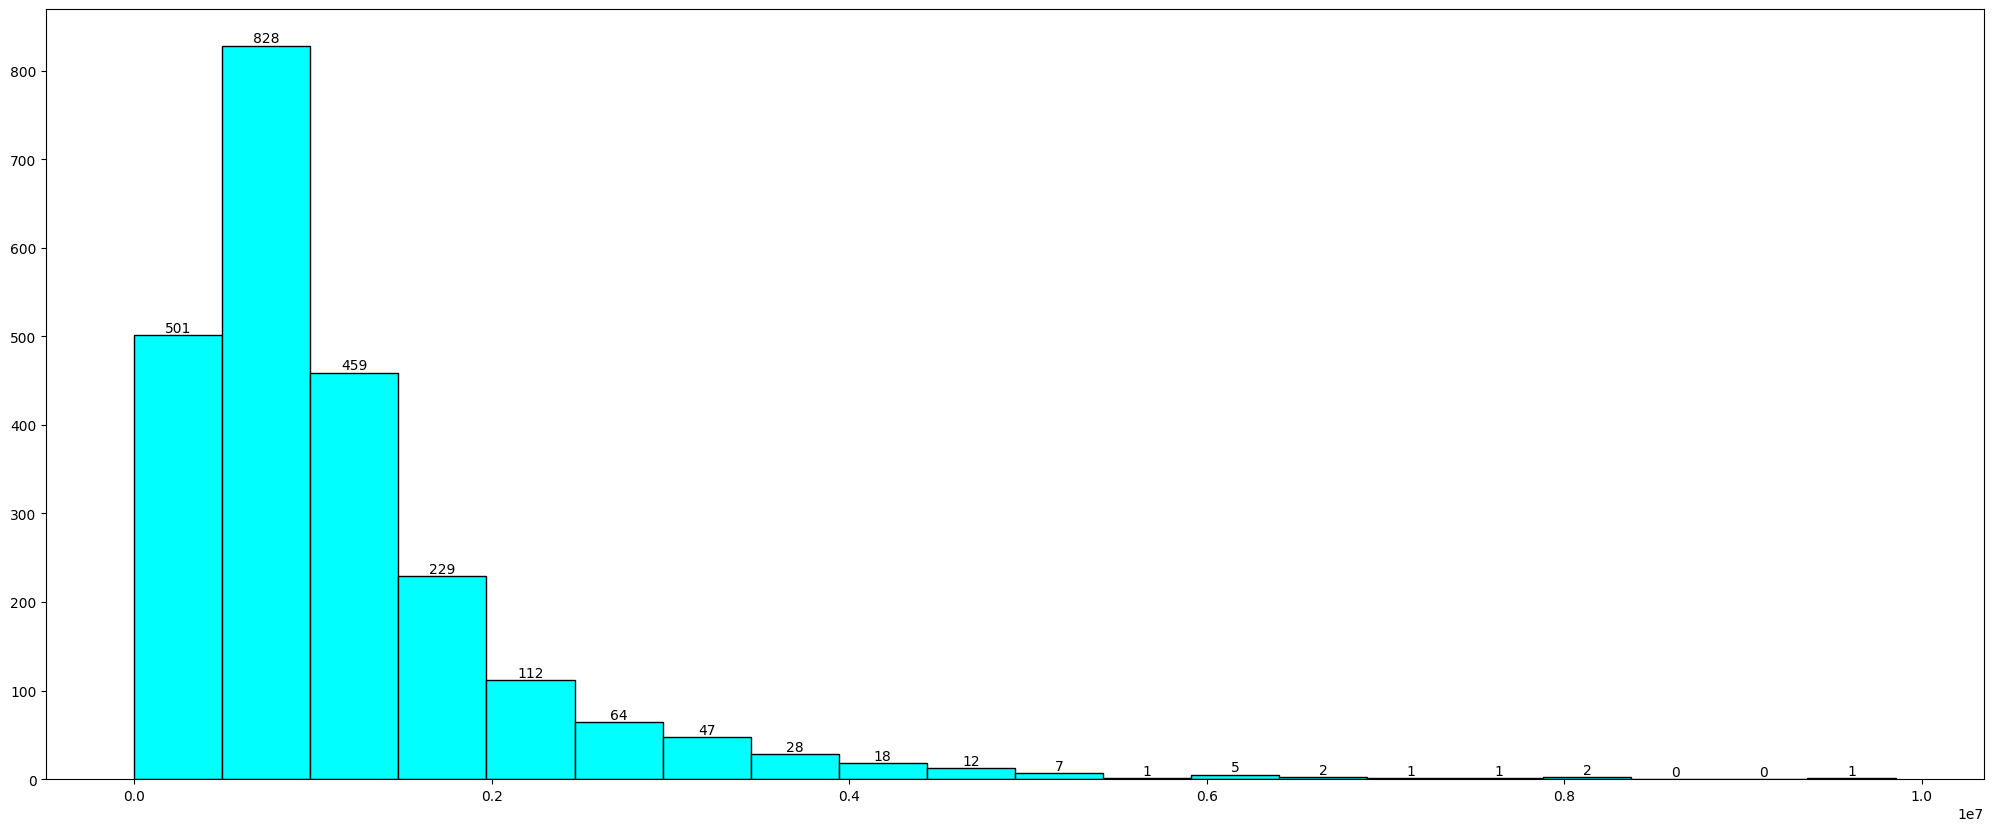

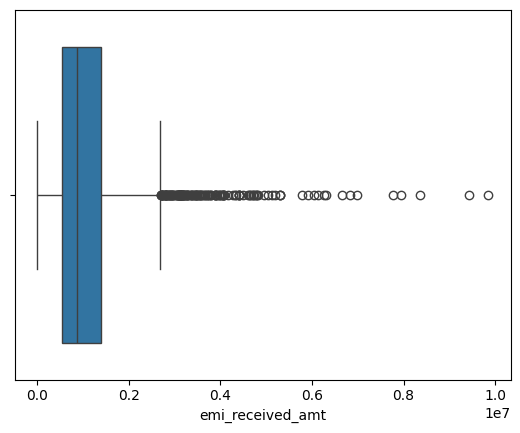

Description of excess_available
----------------------------------------------------------------------------
count    2.319000e+03
mean     1.865469e+05
std      7.175169e+05
min      0.000000e+00
25%      0.000000e+00
50%      1.727088e+02
75%      3.881751e+03
max      1.021953e+07
Name: excess_available, dtype: float64 Distribution of excess_available
----------------------------------------------------------------------------
BoxPlot of excess_available
----------------------------------------------------------------------------


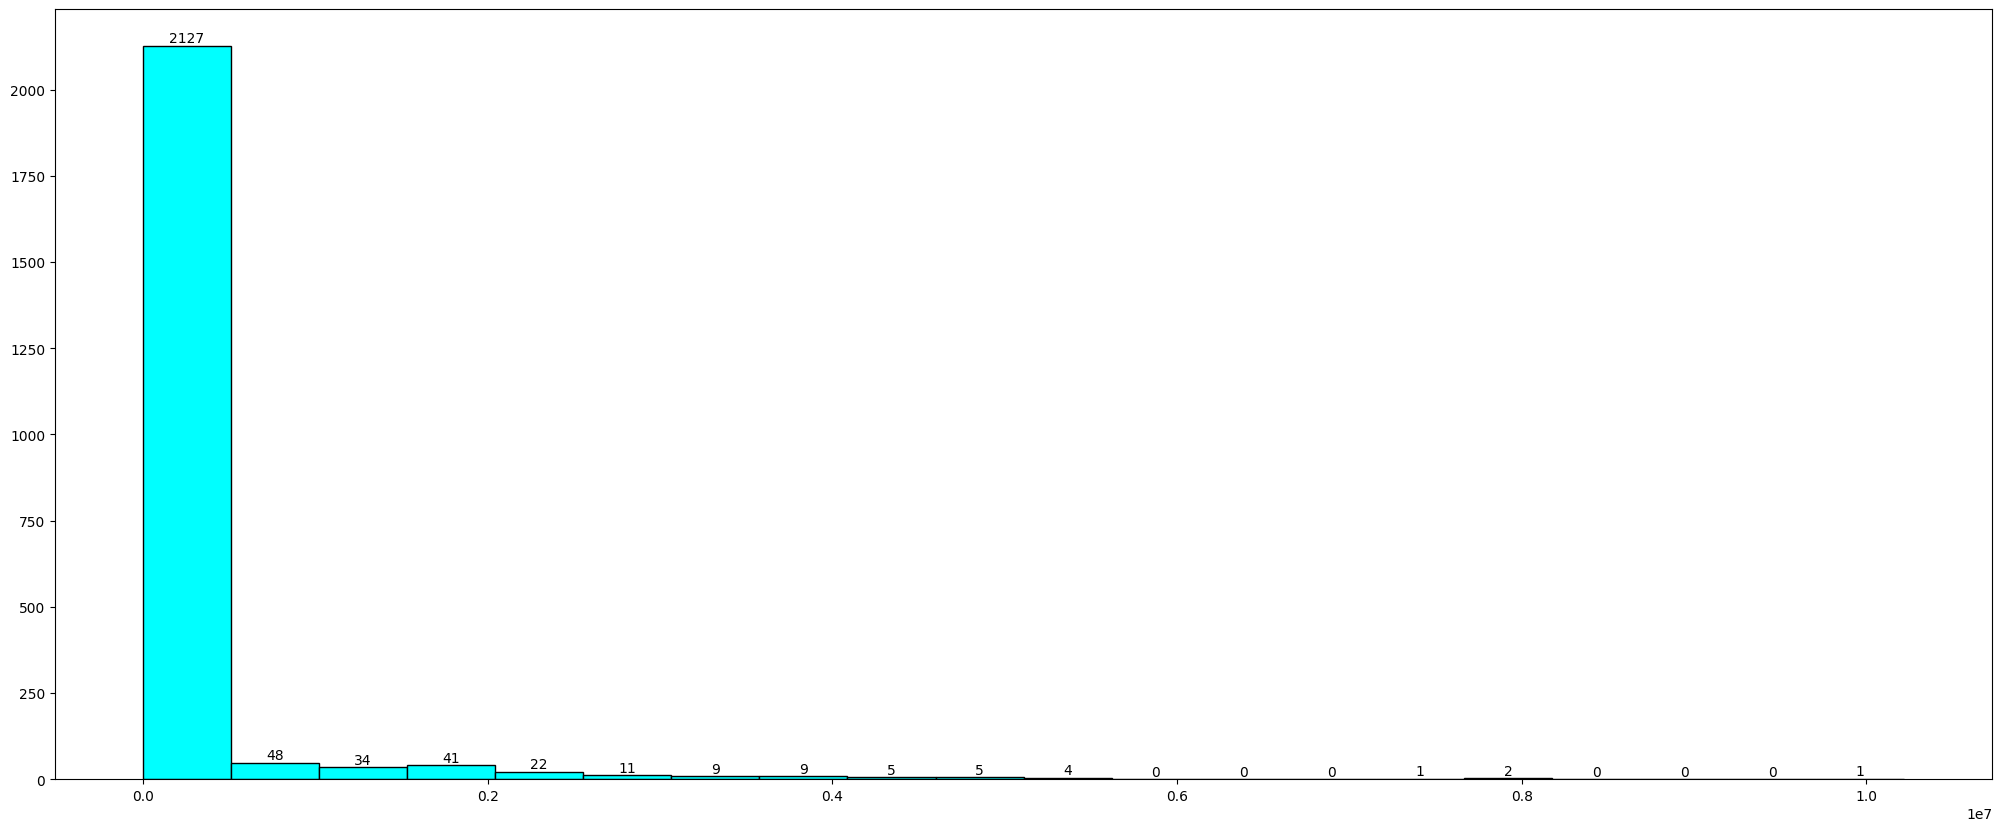

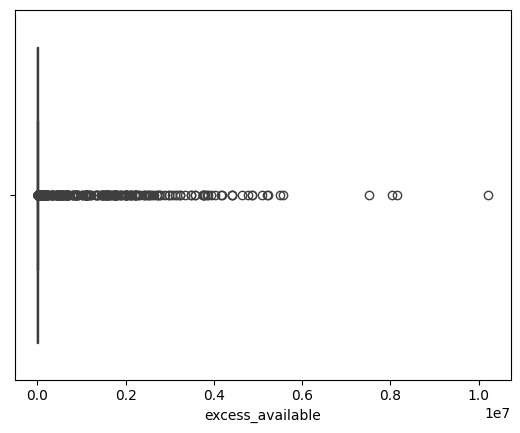

Description of foir
----------------------------------------------------------------------------
count    2319.000000
mean        0.426229
std         0.146320
min         0.000000
25%         0.340000
50%         0.420000
75%         0.490000
max         1.001000
Name: foir, dtype: float64 Distribution of foir
----------------------------------------------------------------------------
BoxPlot of foir
----------------------------------------------------------------------------


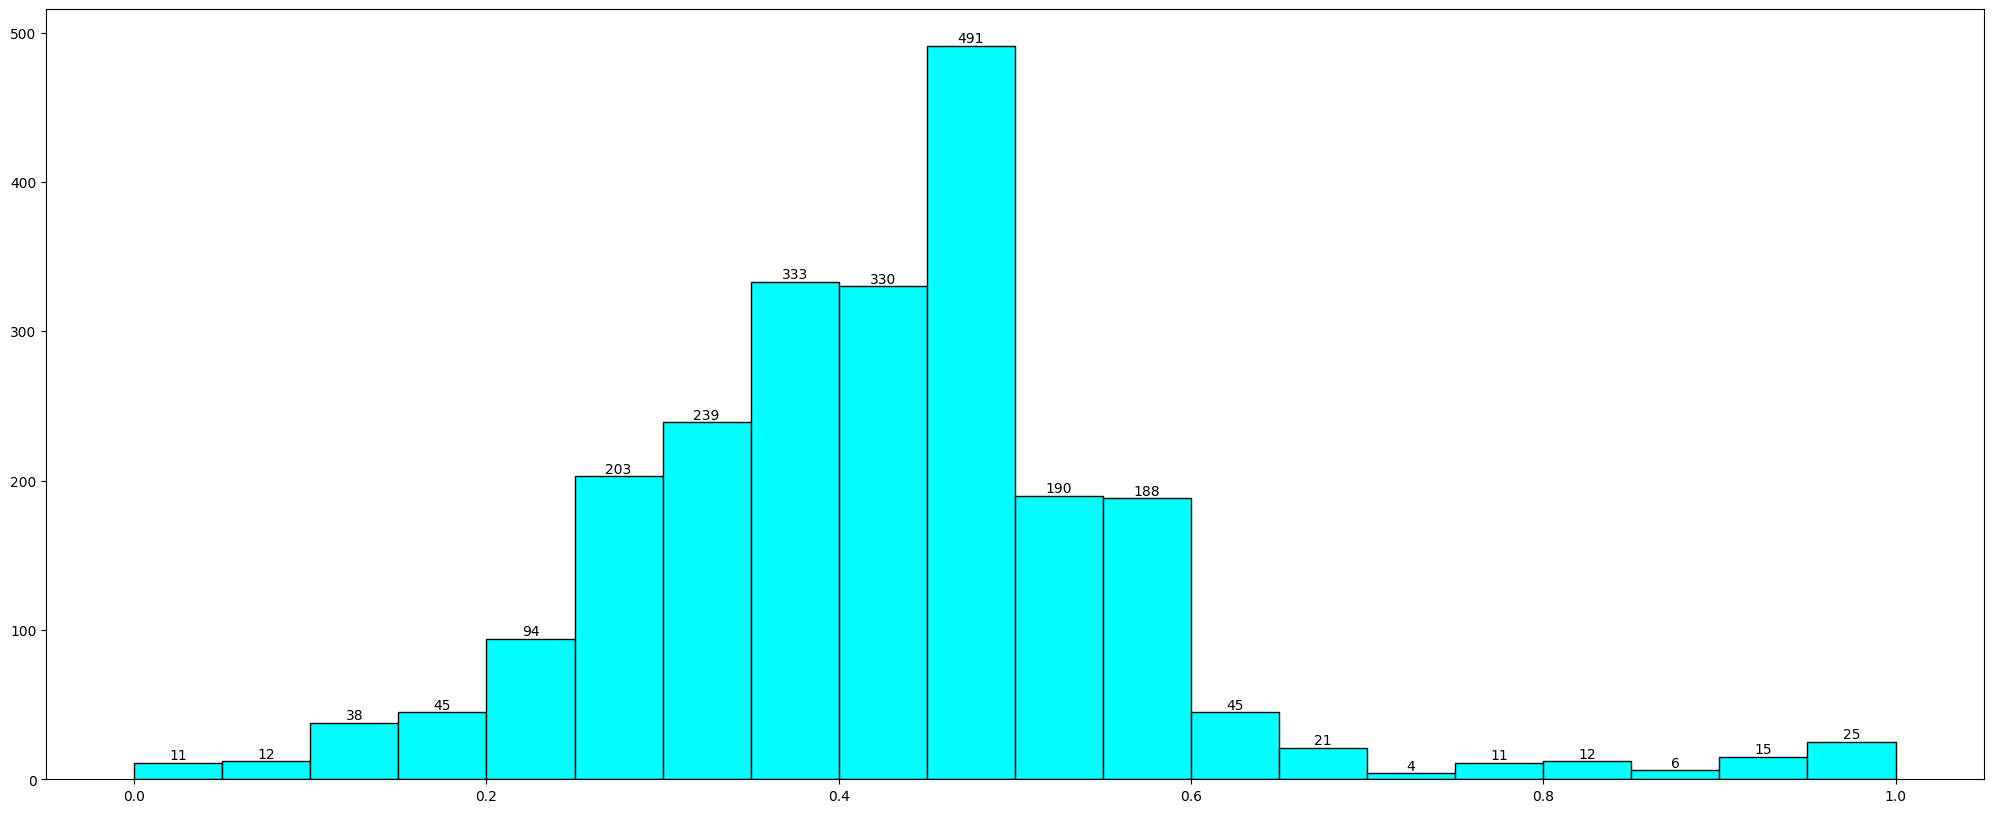

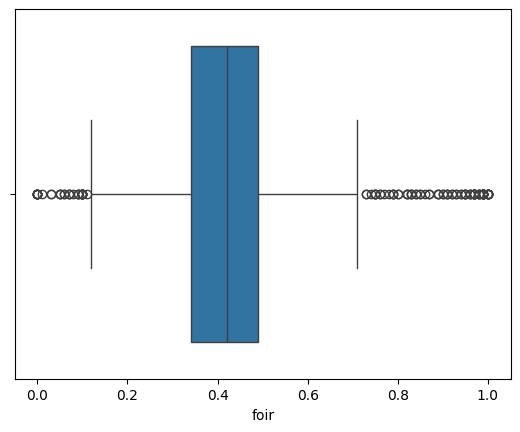

Description of last_receipt_amount
----------------------------------------------------------------------------
count    2.319000e+03
mean     4.114352e+04
std      1.748835e+05
min      2.000000e+00
25%      9.316000e+03
50%      1.440500e+04
75%      2.307700e+04
max      3.229945e+06
Name: last_receipt_amount, dtype: float64 Distribution of last_receipt_amount
----------------------------------------------------------------------------
BoxPlot of last_receipt_amount
----------------------------------------------------------------------------


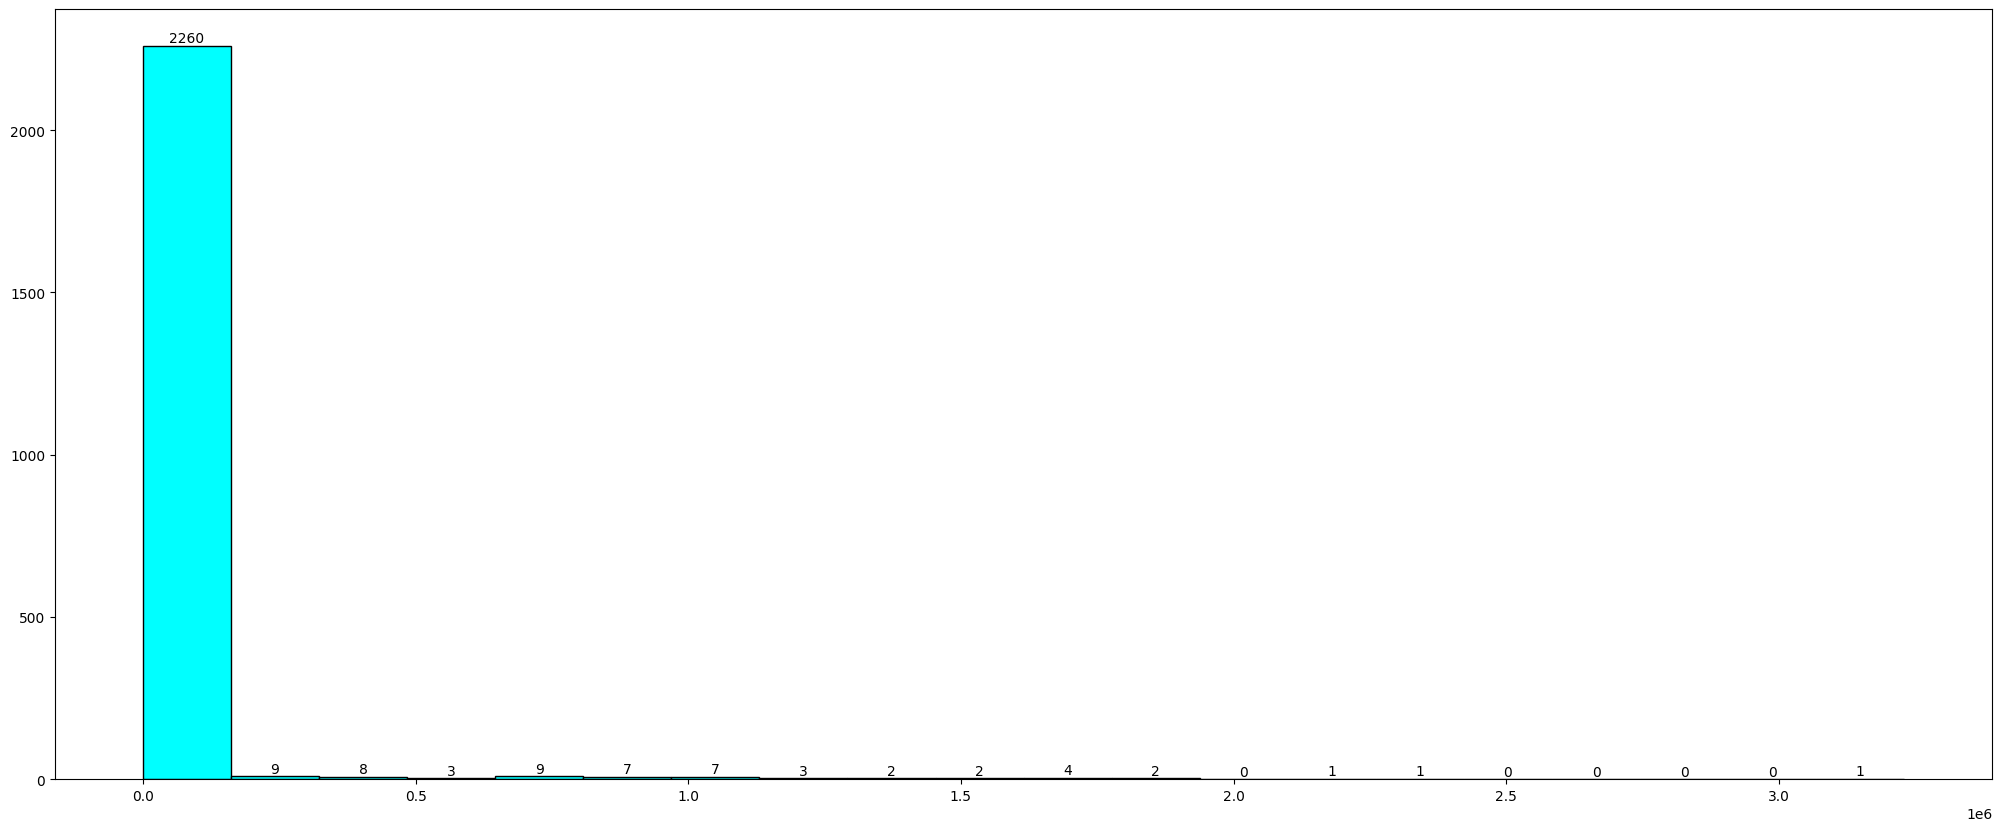

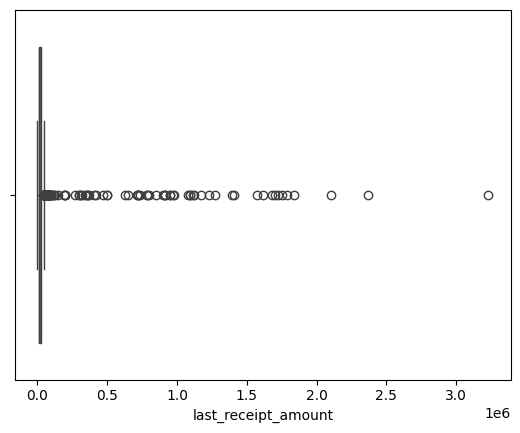

Description of loan_amt
----------------------------------------------------------------------------
count    2.319000e+03
mean     2.194991e+06
std      1.349637e+06
min      1.756516e+05
25%      1.238569e+06
50%      1.801555e+06
75%      2.818683e+06
max      1.089366e+07
Name: loan_amt, dtype: float64 Distribution of loan_amt
----------------------------------------------------------------------------
BoxPlot of loan_amt
----------------------------------------------------------------------------


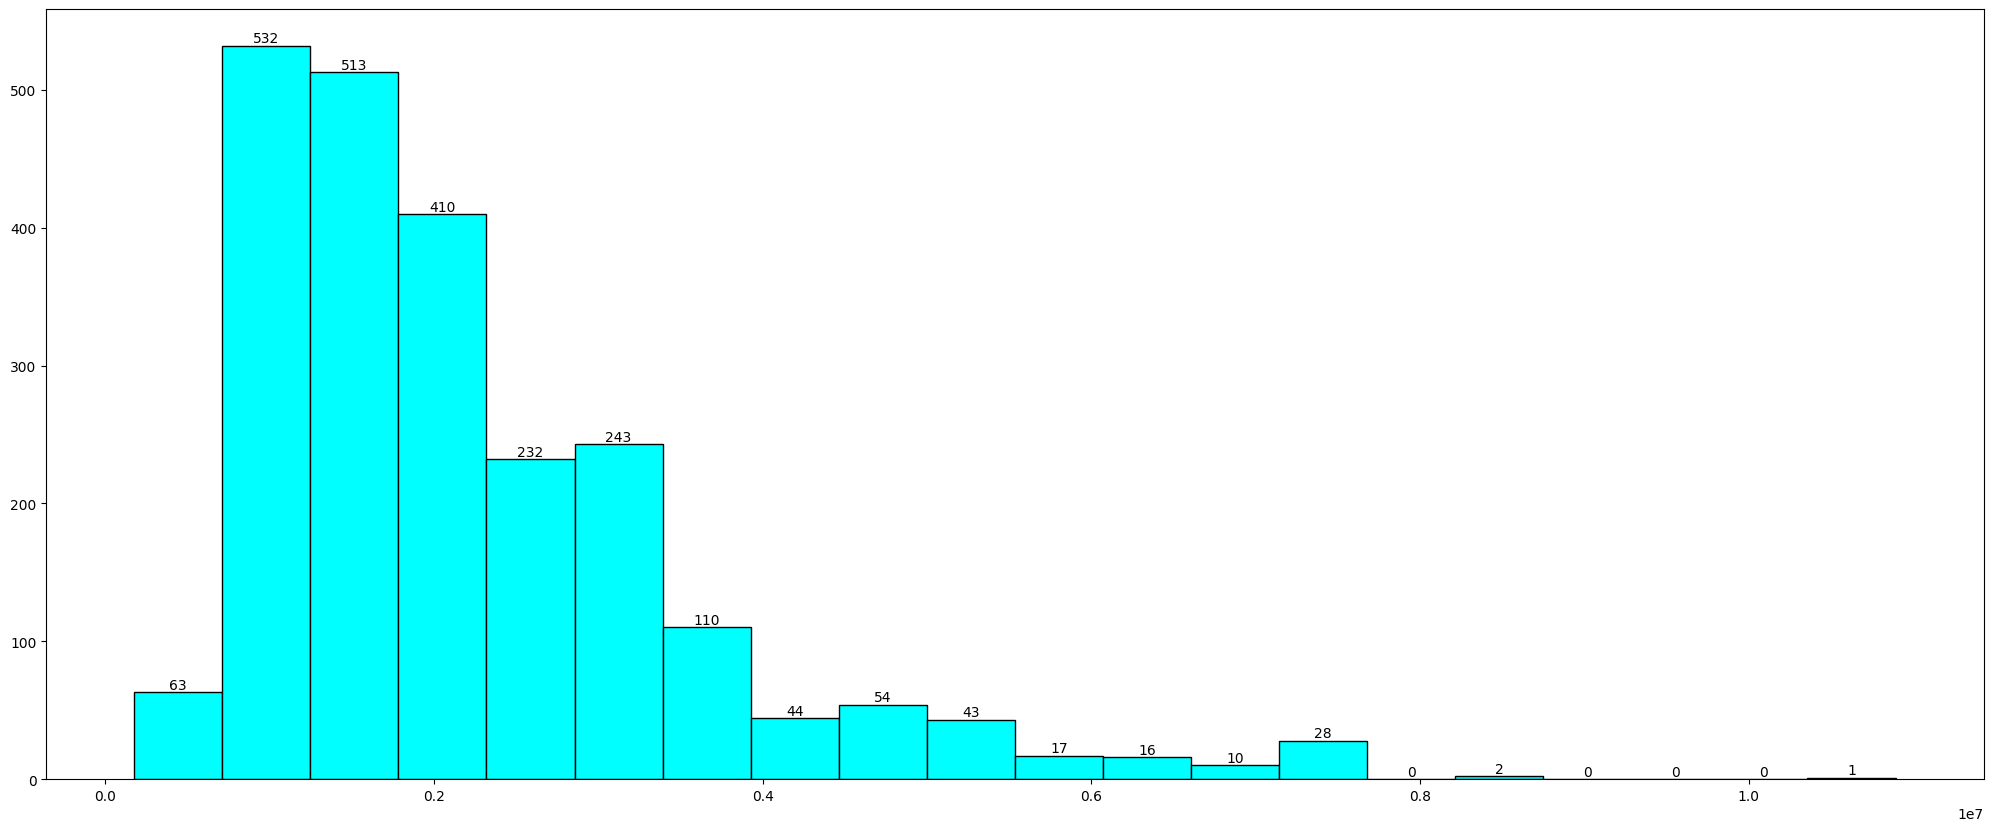

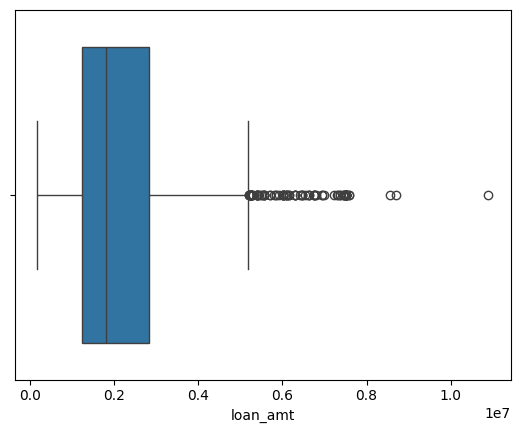

Description of max_emi_amount
----------------------------------------------------------------------------
count    2.319000e+03
mean     5.807497e+04
std      1.960221e+05
min      5.620000e+02
25%      1.157300e+04
50%      1.897500e+04
75%      2.967650e+04
max      3.229945e+06
Name: max_emi_amount, dtype: float64 Distribution of max_emi_amount
----------------------------------------------------------------------------
BoxPlot of max_emi_amount
----------------------------------------------------------------------------


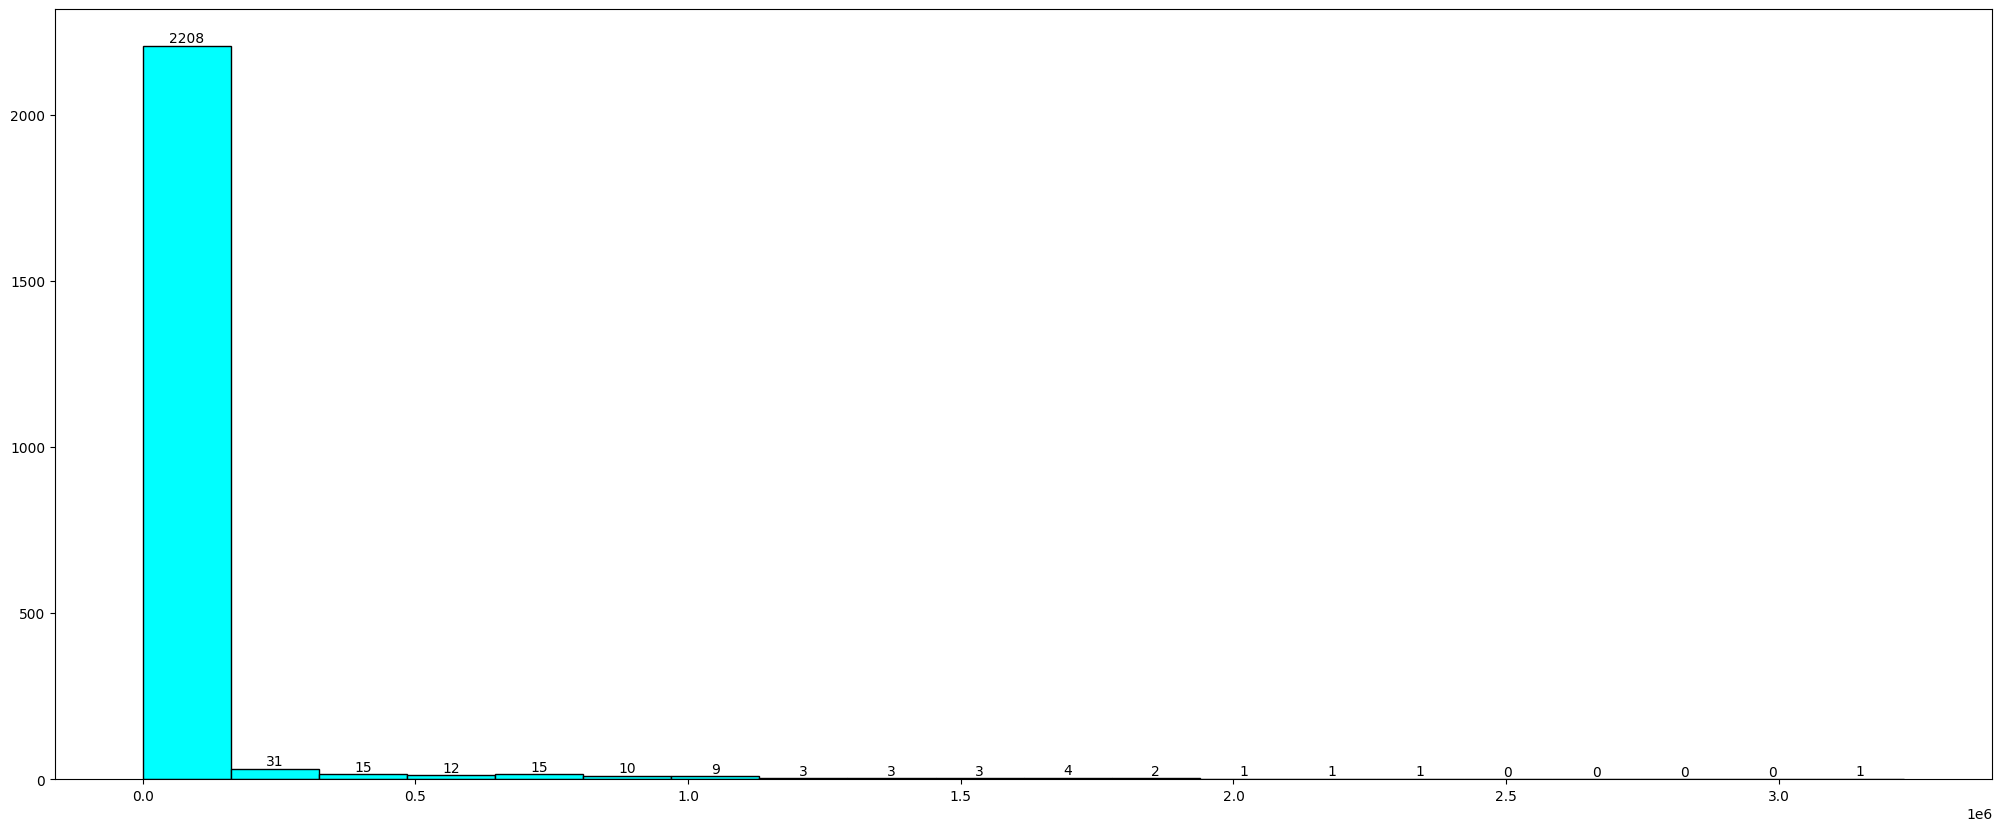

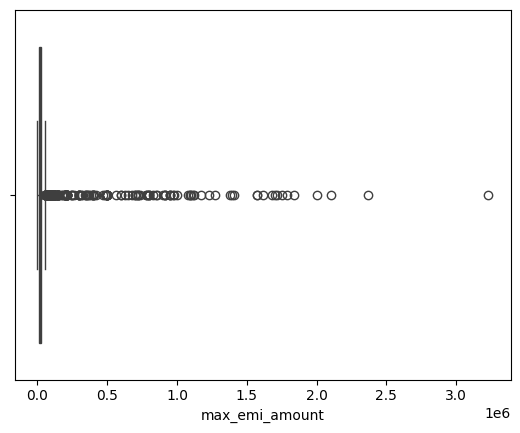

Description of min_emi_amount
----------------------------------------------------------------------------
count     2319.000000
mean      1723.590298
std       5332.764547
min          0.090000
25%        115.000000
50%        115.000000
75%        573.000000
max      84001.000000
Name: min_emi_amount, dtype: float64 Distribution of min_emi_amount
----------------------------------------------------------------------------
BoxPlot of min_emi_amount
----------------------------------------------------------------------------


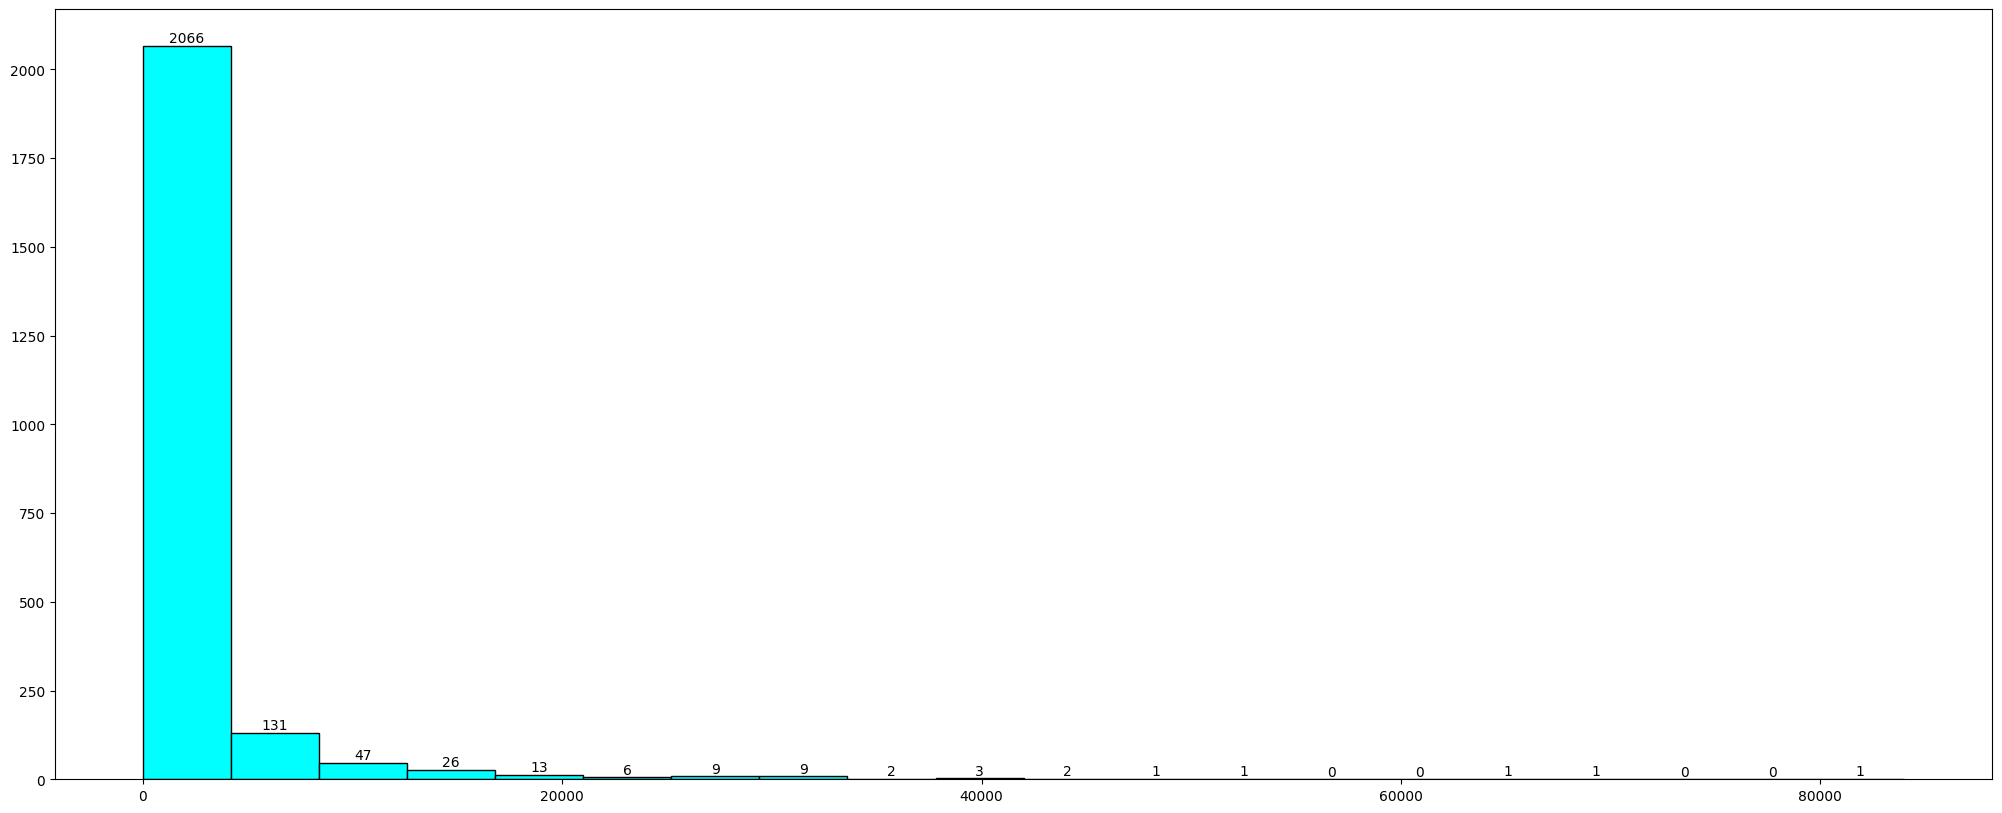

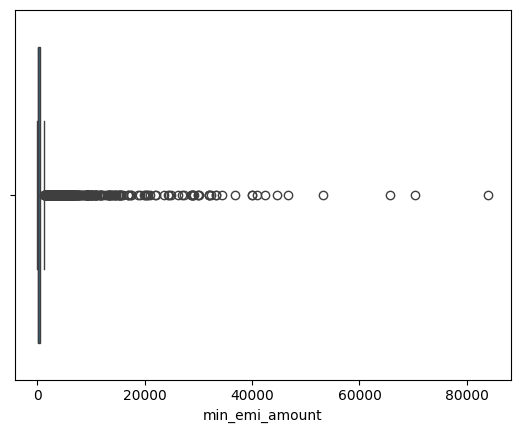

Description of monthopening
----------------------------------------------------------------------------
count    2.319000e+03
mean     2.035442e+06
std      1.286849e+06
min      1.514357e+05
25%      1.135780e+06
50%      1.688189e+06
75%      2.620309e+06
max      1.080242e+07
Name: monthopening, dtype: float64 Distribution of monthopening
----------------------------------------------------------------------------
BoxPlot of monthopening
----------------------------------------------------------------------------


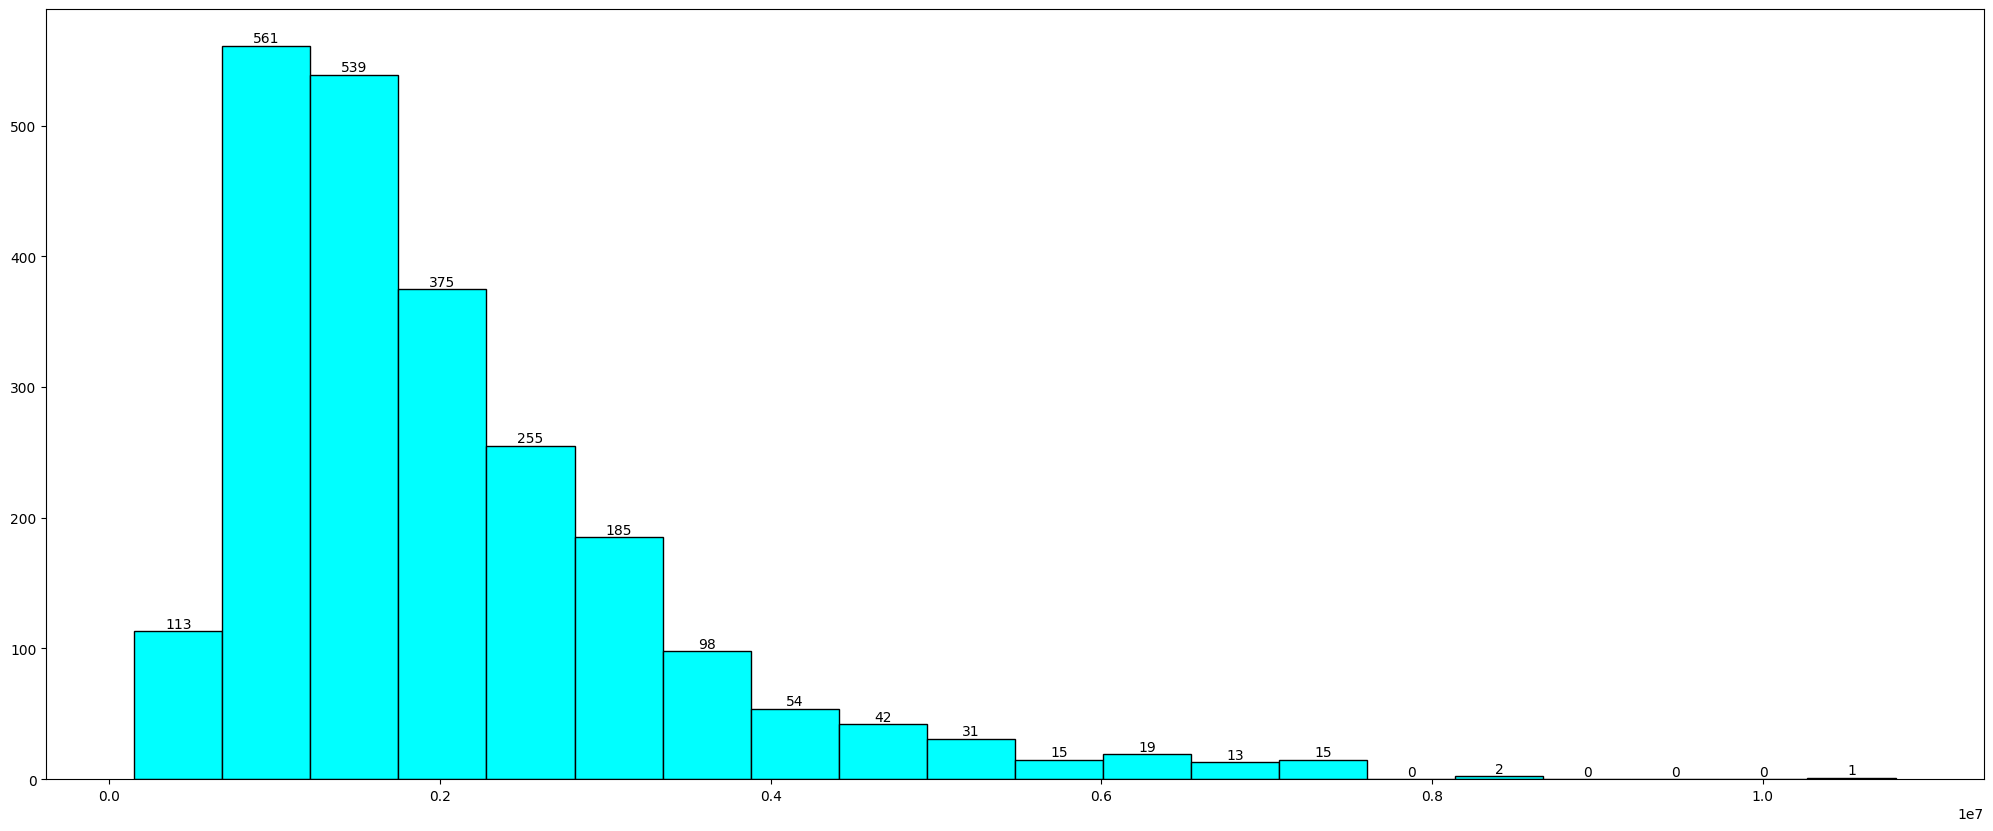

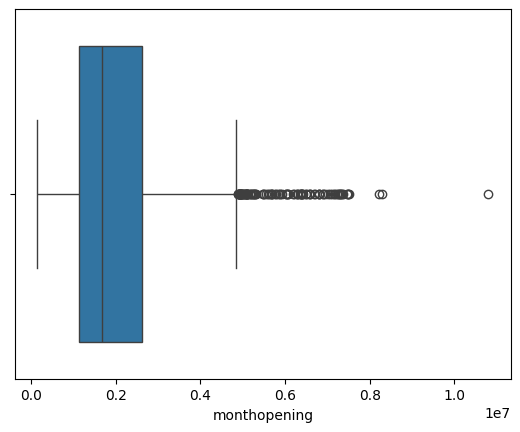

Description of net_disbursed_amt
----------------------------------------------------------------------------
count    2.319000e+03
mean     2.189517e+06
std      1.349531e+06
min      1.756516e+05
25%      1.231063e+06
50%      1.801555e+06
75%      2.800199e+06
max      1.089366e+07
Name: net_disbursed_amt, dtype: float64 Distribution of net_disbursed_amt
----------------------------------------------------------------------------
BoxPlot of net_disbursed_amt
----------------------------------------------------------------------------


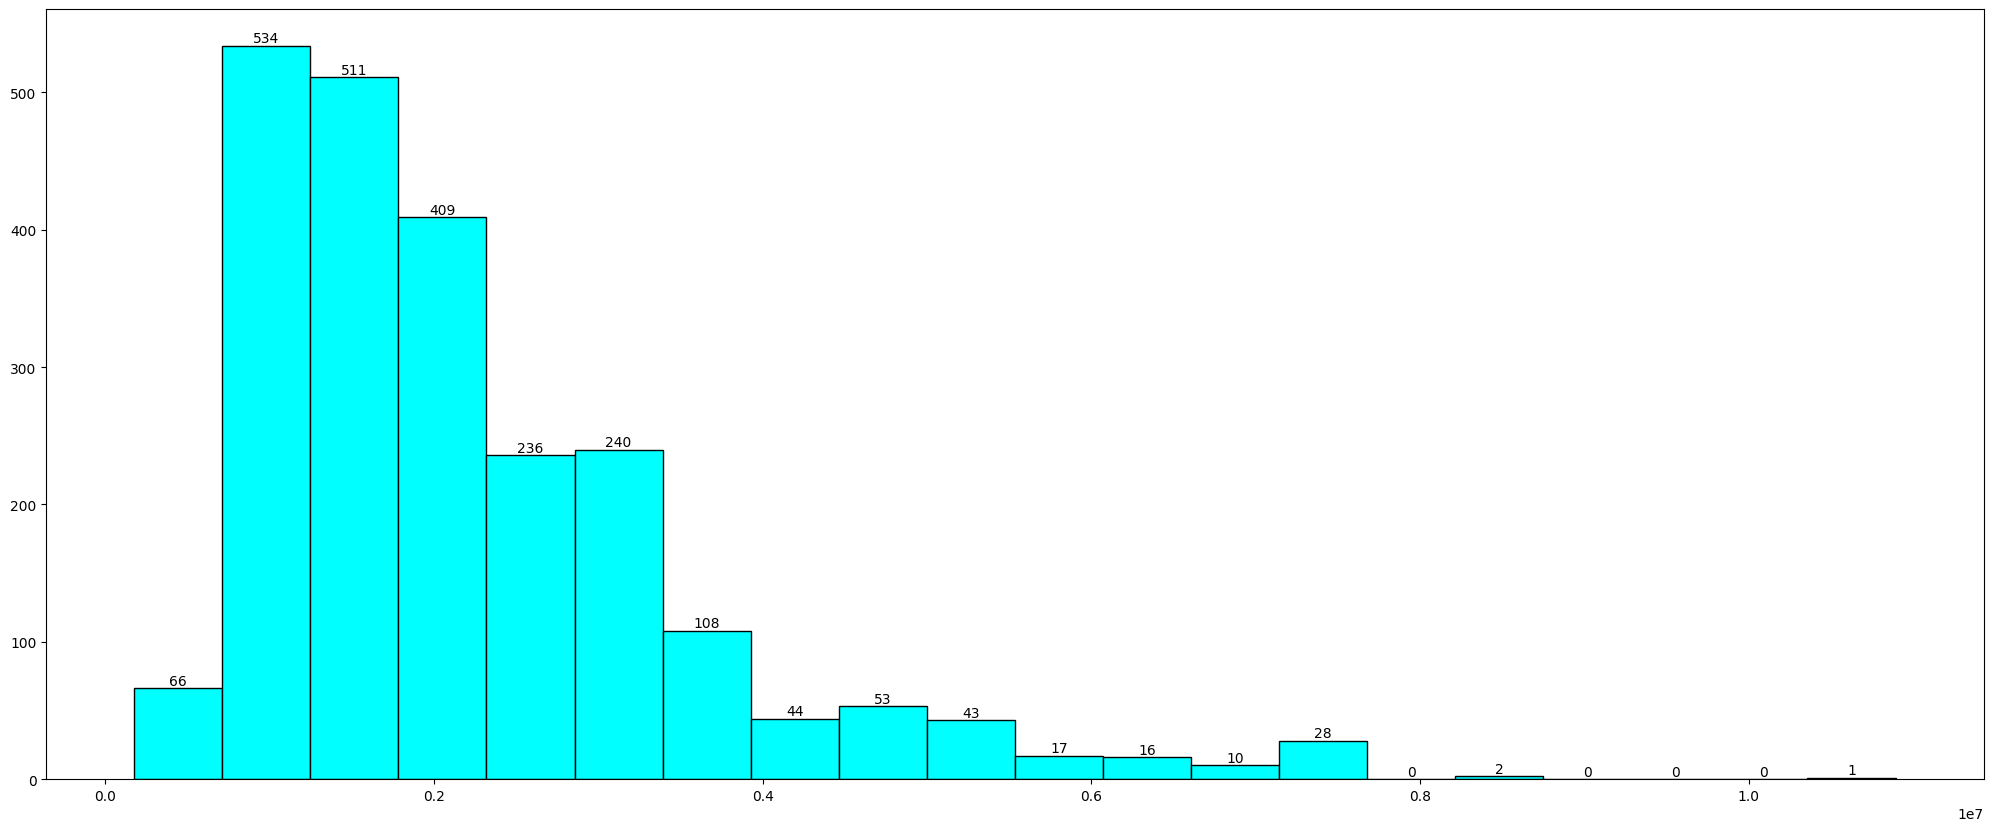

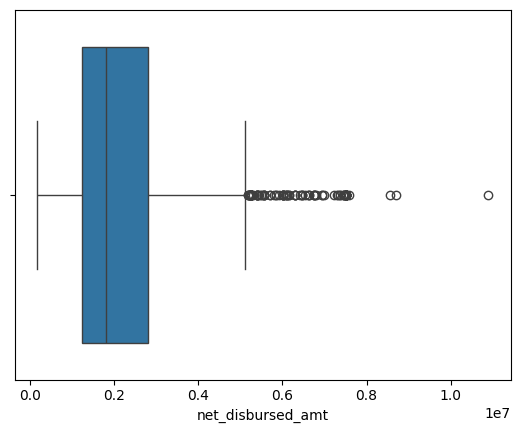

Description of net_ltv
----------------------------------------------------------------------------
count    2319.000000
mean       51.570013
std        18.757921
min         5.220000
25%        36.800000
50%        52.070000
75%        68.890000
max        84.390000
Name: net_ltv, dtype: float64 Distribution of net_ltv
----------------------------------------------------------------------------
BoxPlot of net_ltv
----------------------------------------------------------------------------


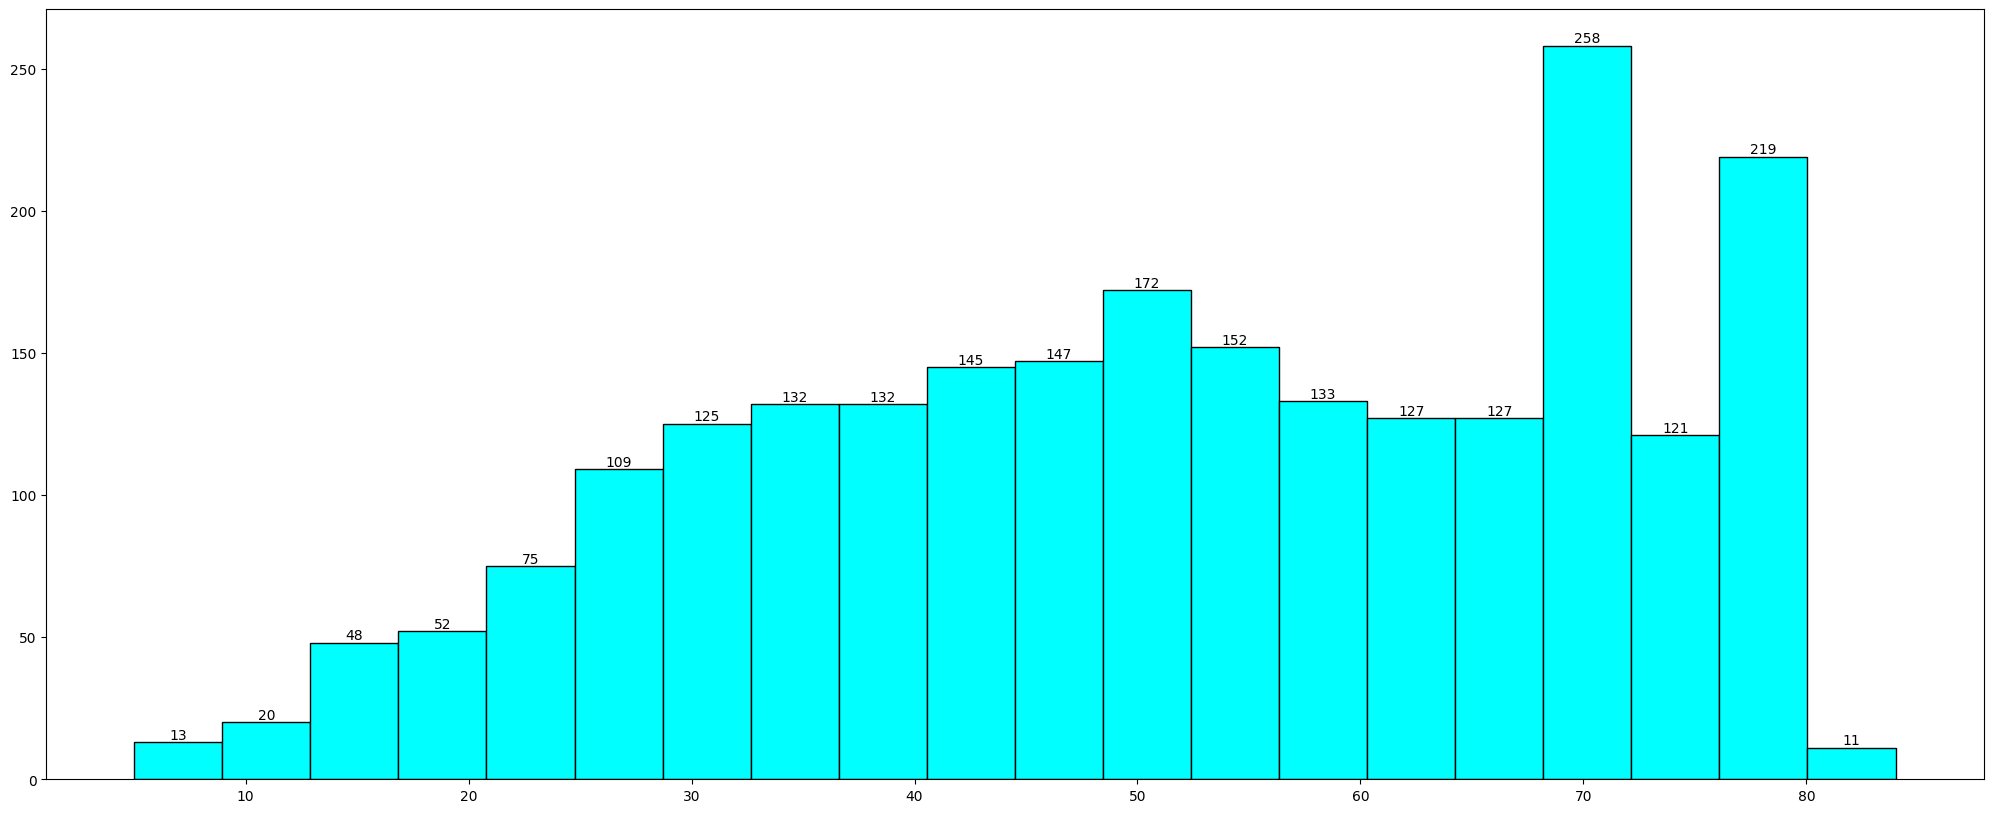

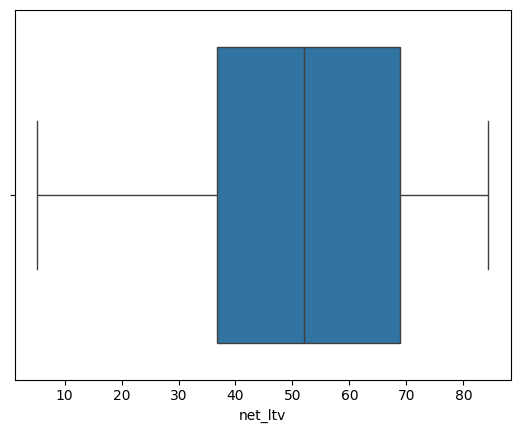

Description of net_receivable
----------------------------------------------------------------------------
count    2.319000e+03
mean     4.978290e+03
std      5.257671e+05
min     -7.133502e+06
25%     -3.259933e+02
50%     -4.417104e-01
75%      0.000000e+00
max      8.252080e+06
Name: net_receivable, dtype: float64 Distribution of net_receivable
----------------------------------------------------------------------------
BoxPlot of net_receivable
----------------------------------------------------------------------------


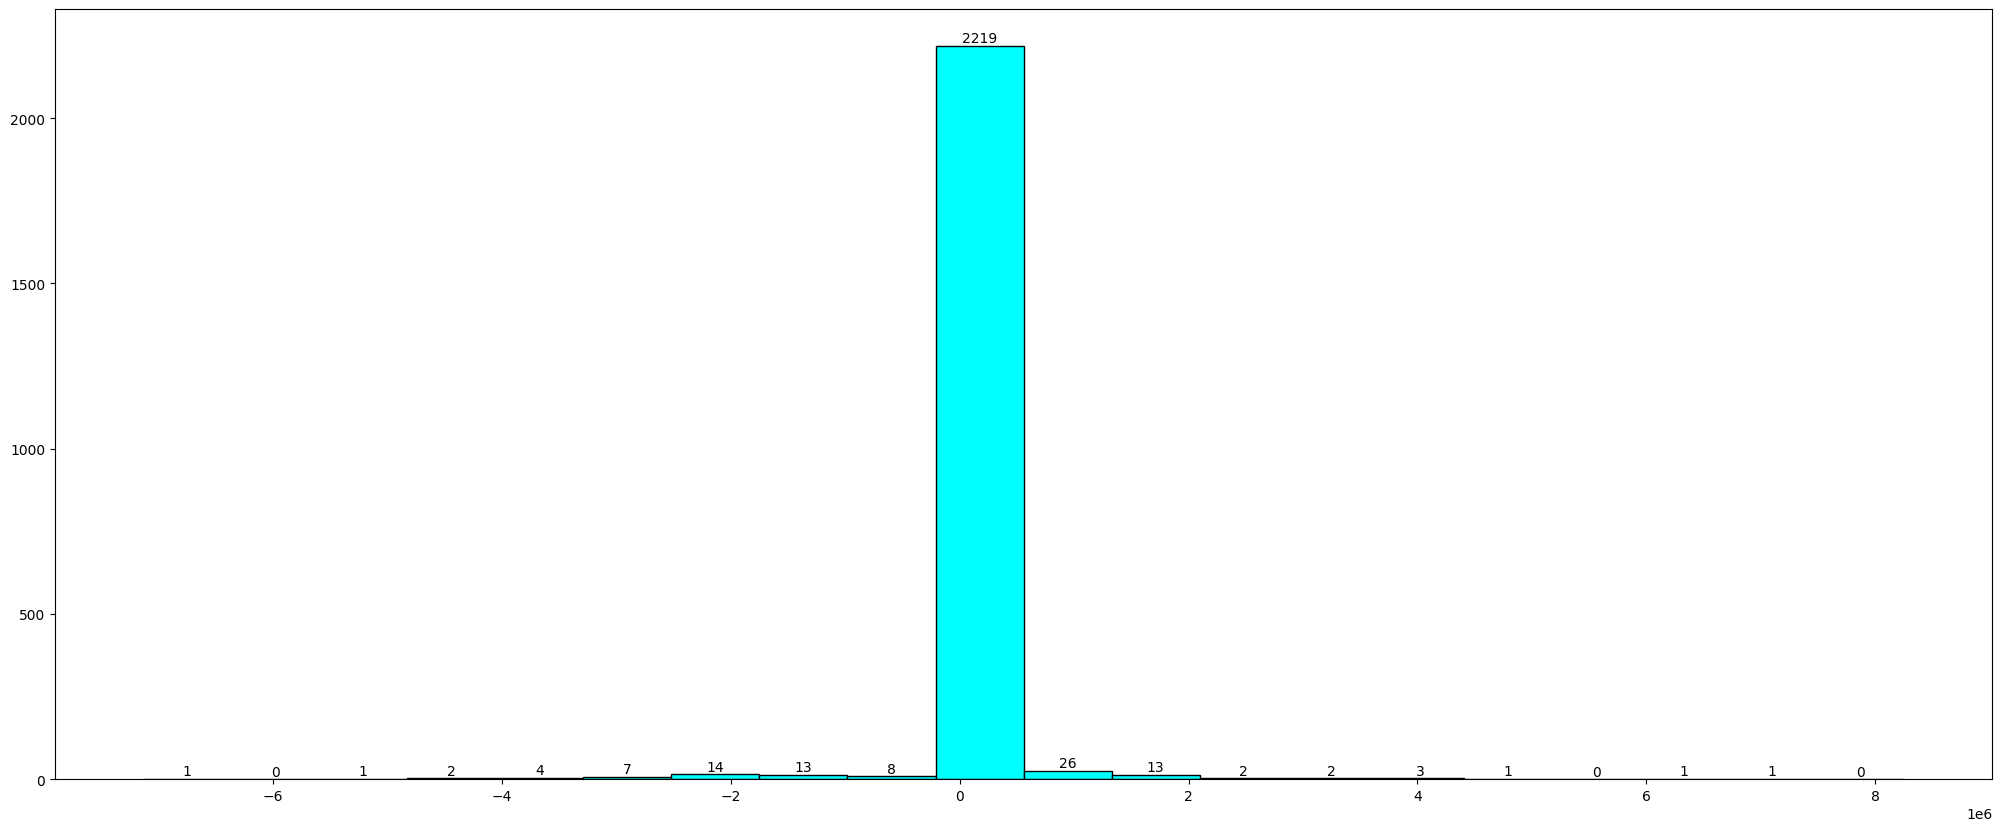

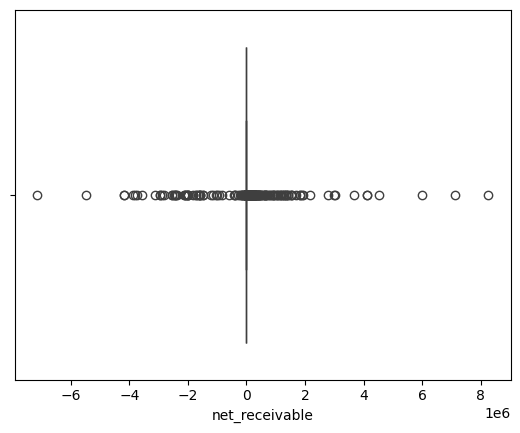

Description of num_emi_changes
----------------------------------------------------------------------------
count    2319.000000
mean        5.356188
std         3.809970
min         0.000000
25%         3.000000
50%         4.000000
75%         7.000000
max        27.000000
Name: num_emi_changes, dtype: float64 Distribution of num_emi_changes
----------------------------------------------------------------------------
BoxPlot of num_emi_changes
----------------------------------------------------------------------------


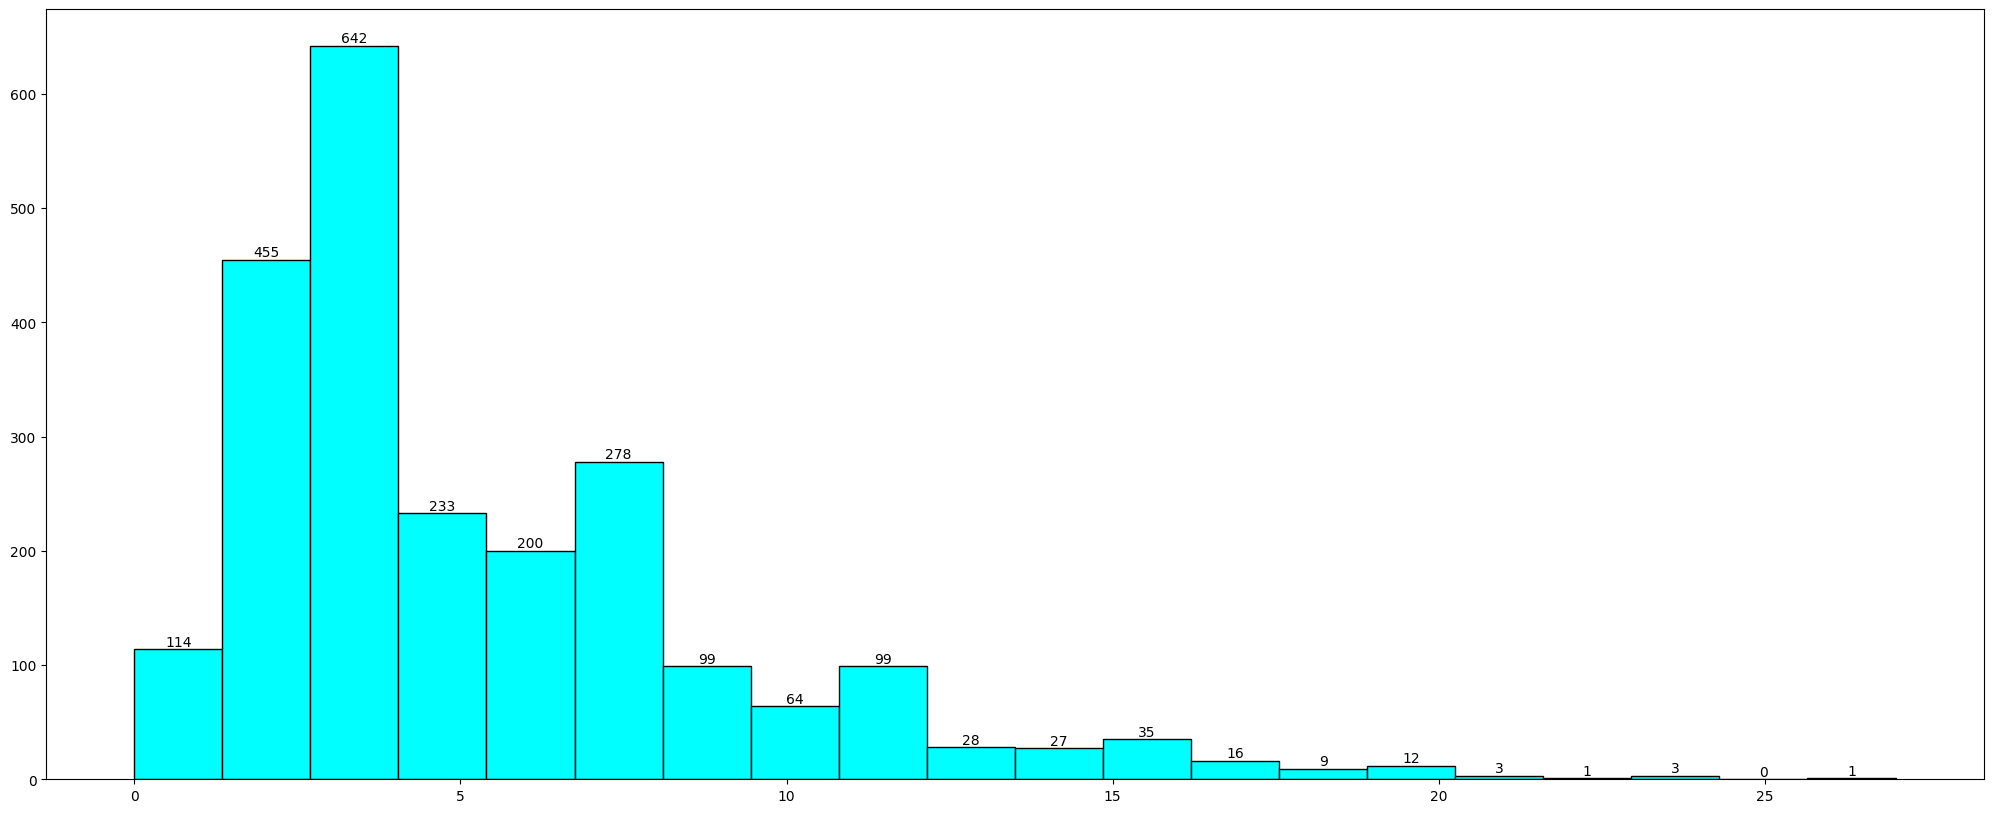

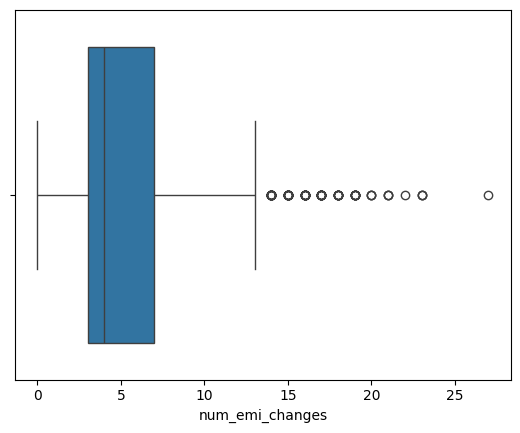

Description of num_low_freq_transactions
----------------------------------------------------------------------------
count    2319.000000
mean        4.567486
std         3.610644
min         0.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        21.000000
Name: num_low_freq_transactions, dtype: float64 Distribution of num_low_freq_transactions
----------------------------------------------------------------------------
BoxPlot of num_low_freq_transactions
----------------------------------------------------------------------------


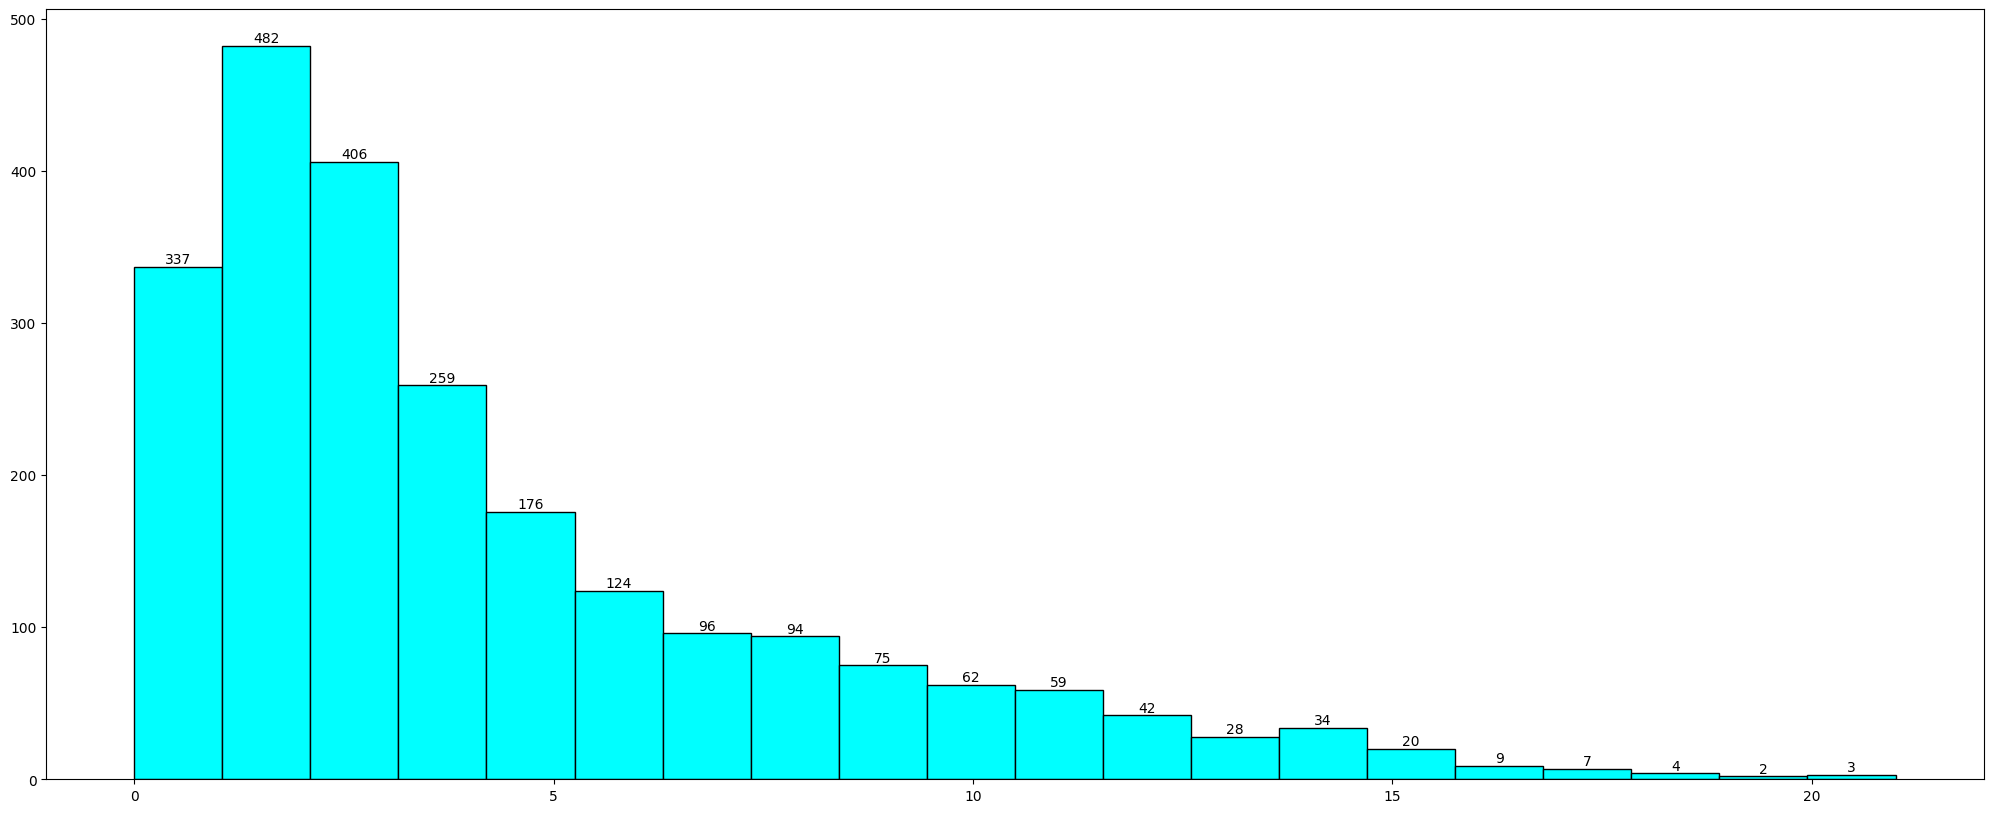

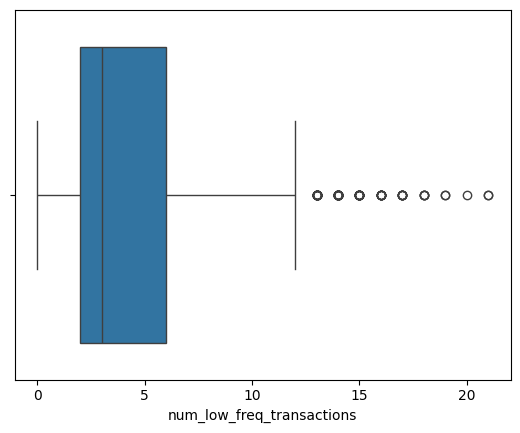

Description of num_of_emi_transactions
----------------------------------------------------------------------------
count    2319.000000
mean       32.156102
std        13.251947
min         0.000000
25%        24.000000
50%        31.000000
75%        40.000000
max        73.000000
Name: num_of_emi_transactions, dtype: float64 Distribution of num_of_emi_transactions
----------------------------------------------------------------------------
BoxPlot of num_of_emi_transactions
----------------------------------------------------------------------------


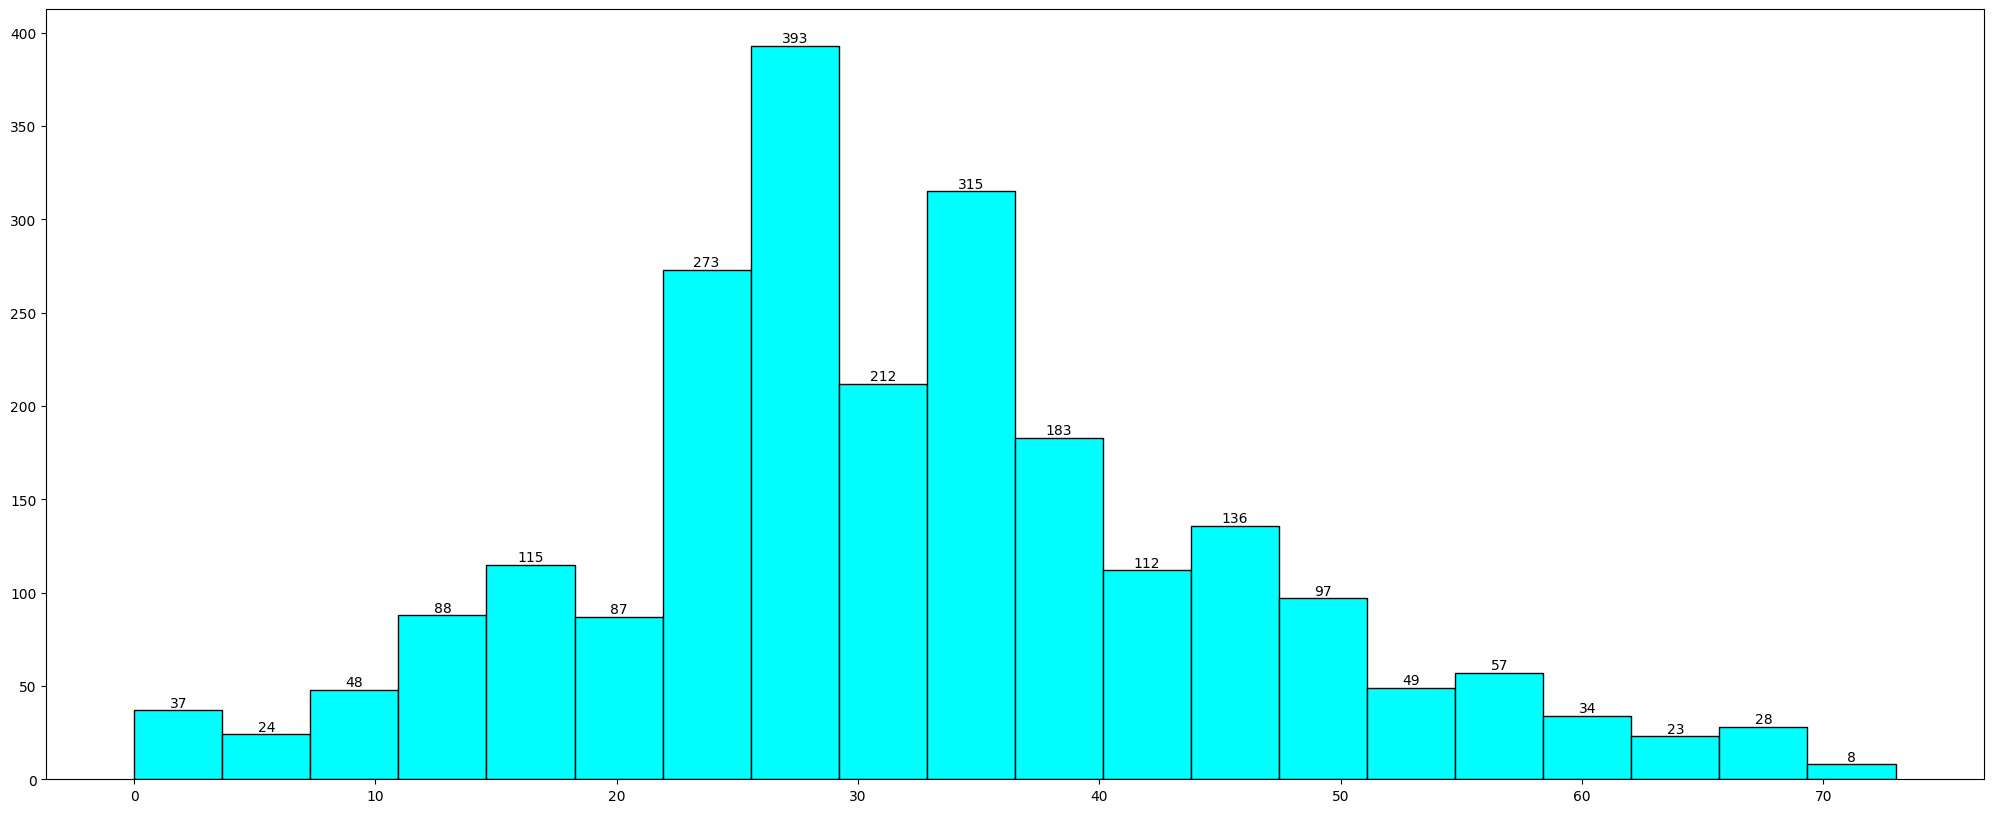

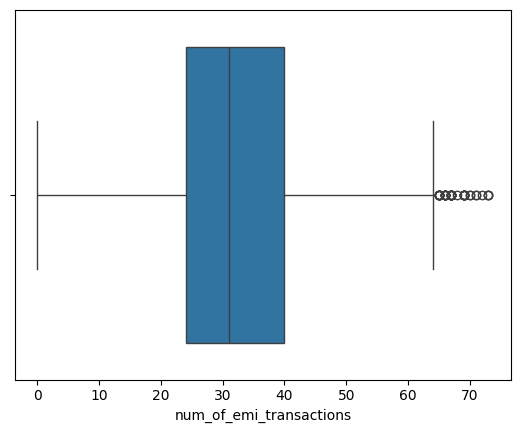

Description of orignal_interest_rate
----------------------------------------------------------------------------
count    2319.000000
mean       15.768140
std         1.814290
min        11.074656
25%        14.358348
50%        15.919038
75%        17.479728
max        19.976832
Name: orignal_interest_rate, dtype: float64 Distribution of orignal_interest_rate
----------------------------------------------------------------------------
BoxPlot of orignal_interest_rate
----------------------------------------------------------------------------


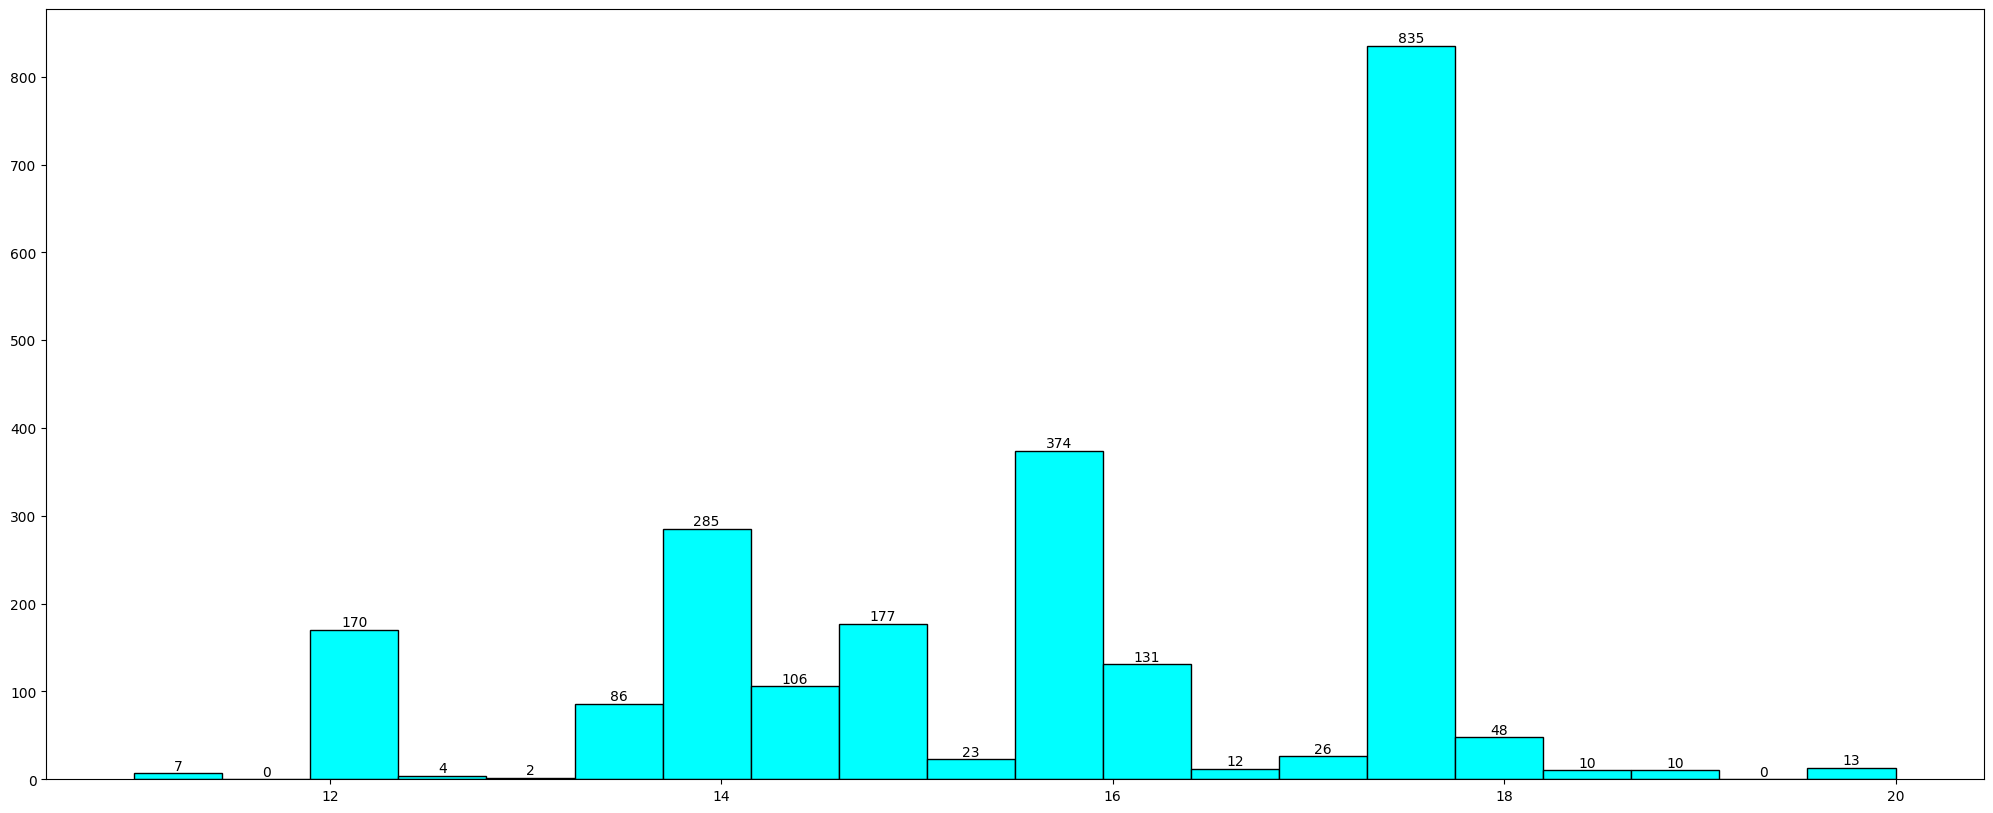

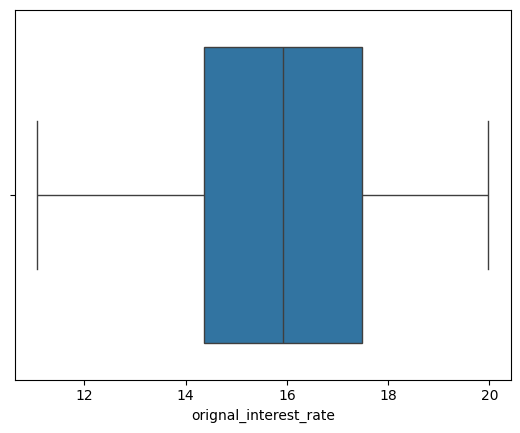

Description of orignal_tenor
----------------------------------------------------------------------------
count    2319.000000
mean      180.867615
std        35.859160
min        60.000000
25%       180.000000
50%       180.000000
75%       180.000000
max       240.000000
Name: orignal_tenor, dtype: float64 Distribution of orignal_tenor
----------------------------------------------------------------------------
BoxPlot of orignal_tenor
----------------------------------------------------------------------------


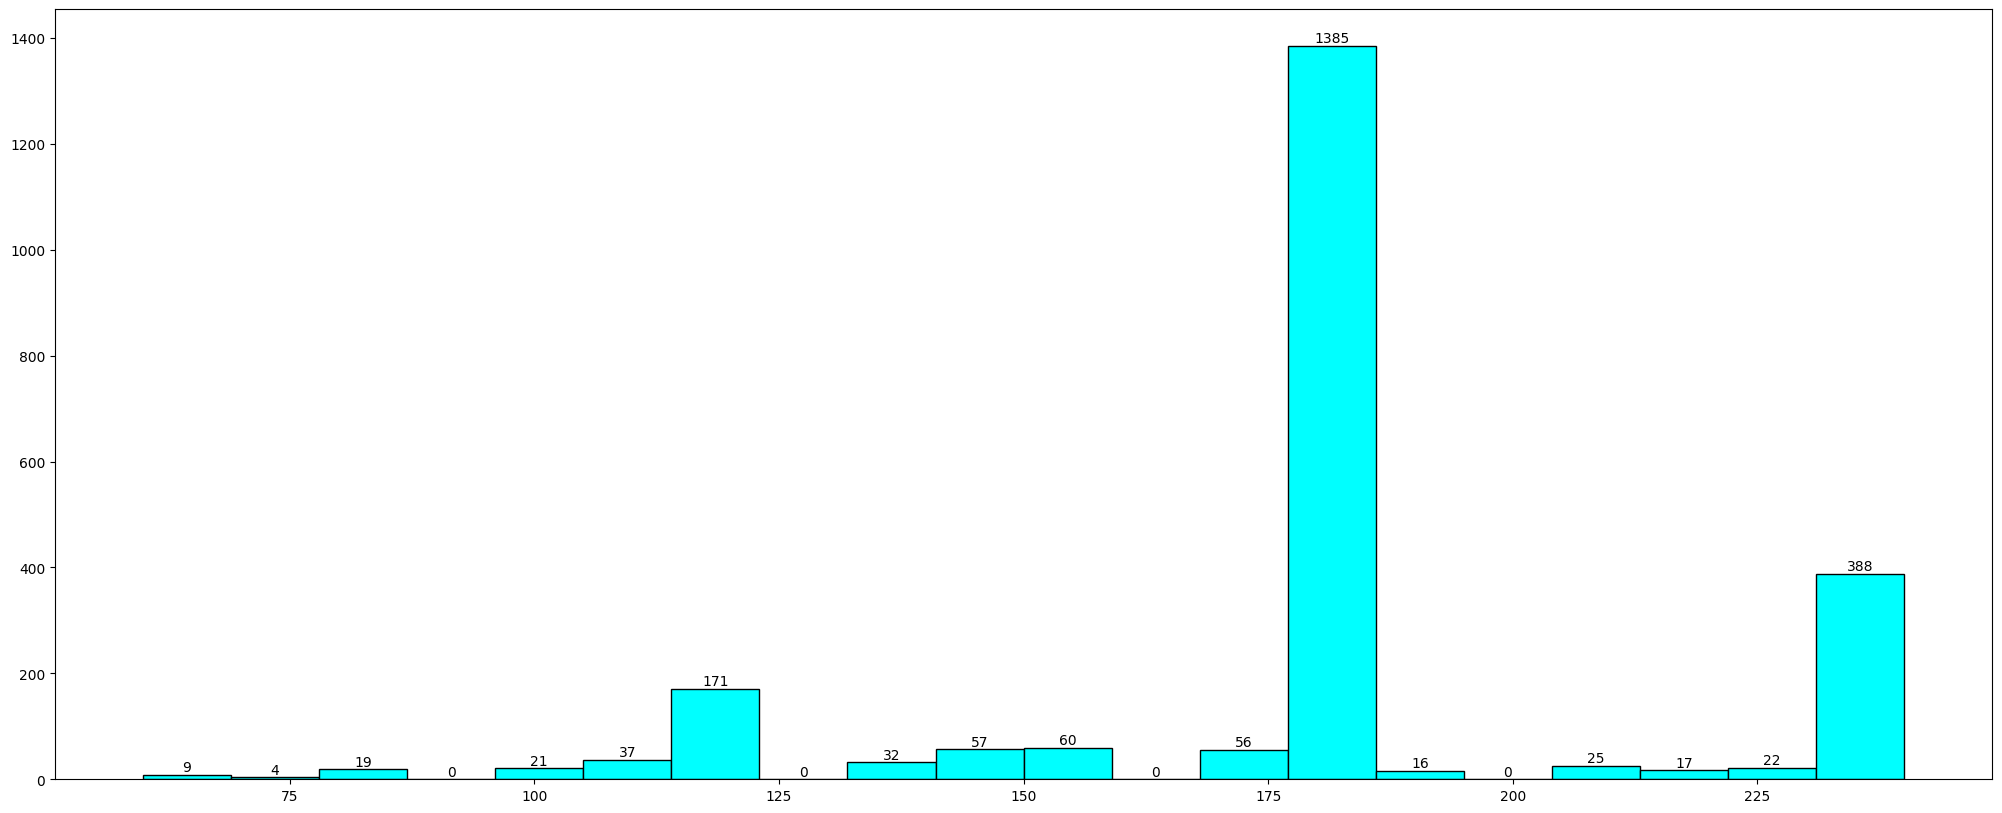

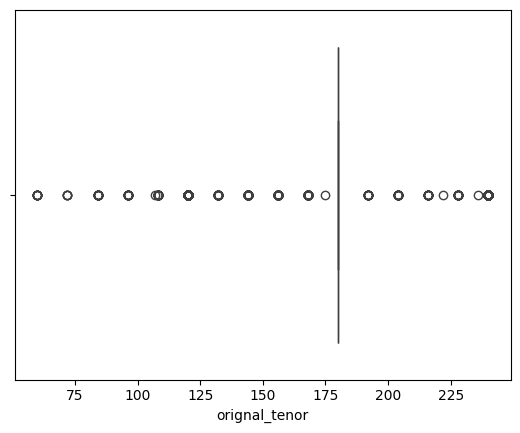

Description of outstanding_principal
----------------------------------------------------------------------------
count    2.319000e+03
mean     1.949442e+06
std      1.289269e+06
min      0.000000e+00
25%      1.065798e+06
50%      1.606862e+06
75%      2.546081e+06
max      1.080242e+07
Name: outstanding_principal, dtype: float64 Distribution of outstanding_principal
----------------------------------------------------------------------------
BoxPlot of outstanding_principal
----------------------------------------------------------------------------


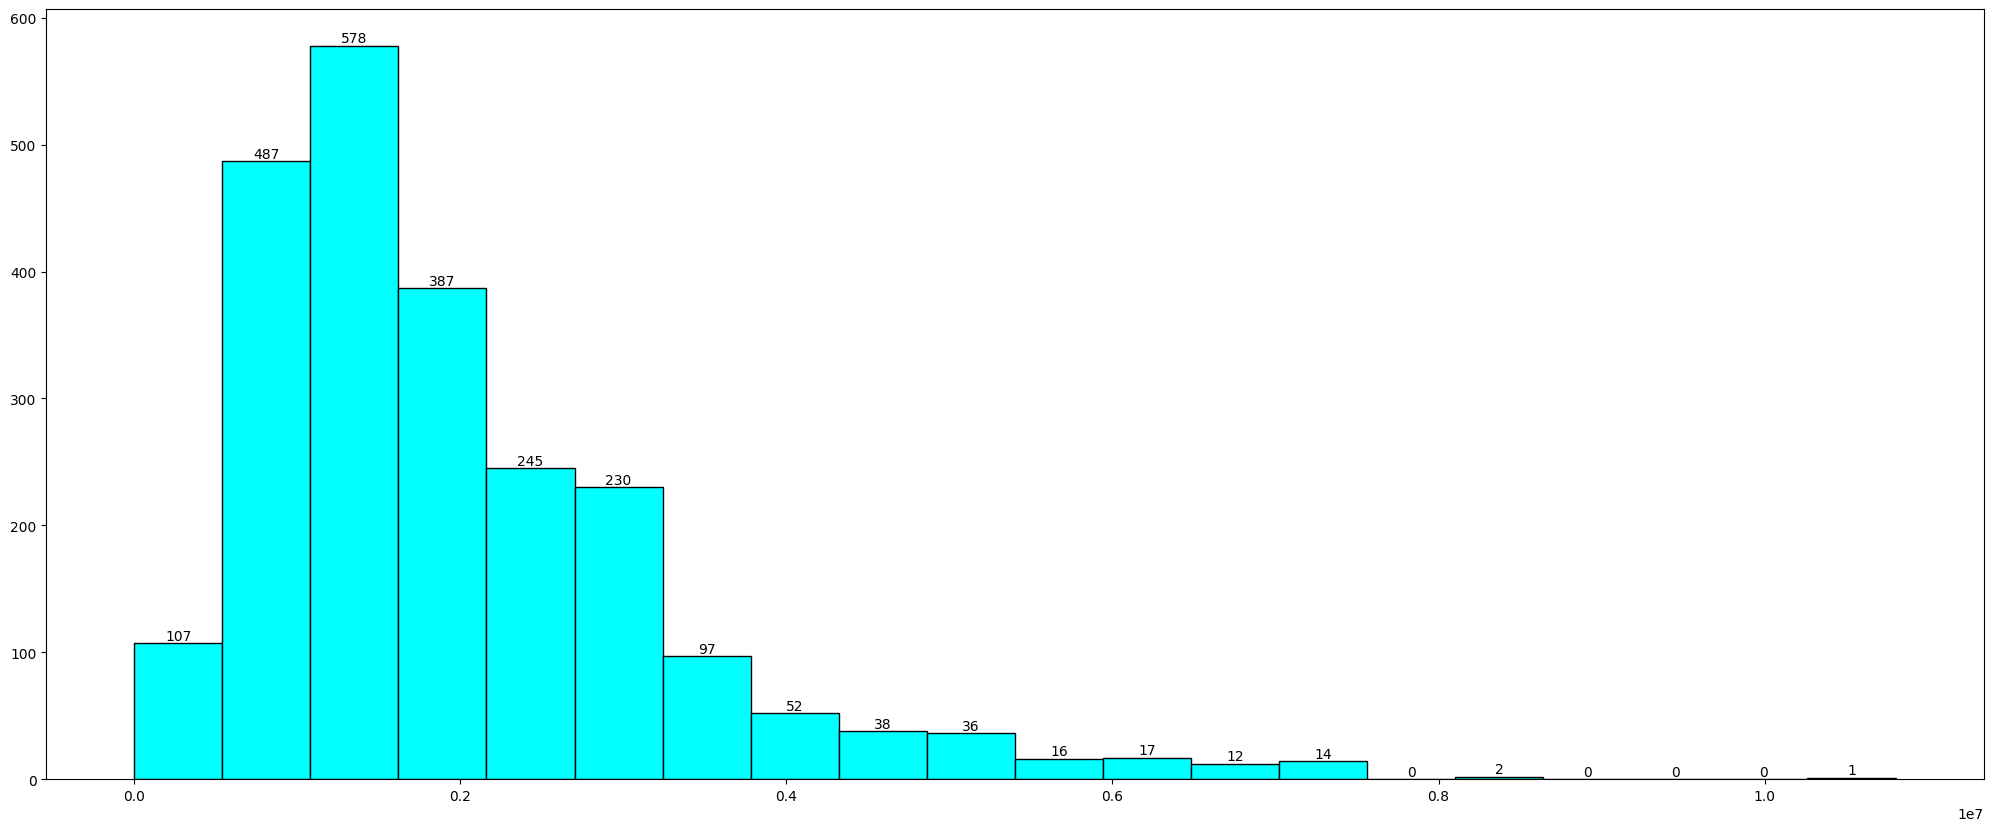

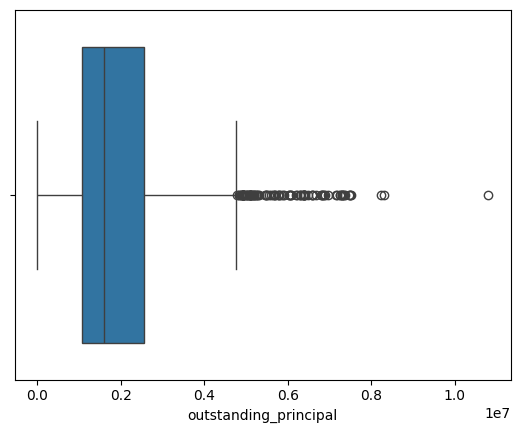

Description of paid_interest
----------------------------------------------------------------------------
count    2.319000e+03
mean     6.538977e+05
std      5.553356e+05
min      0.000000e+00
25%      3.083669e+05
50%      5.082382e+05
75%      8.067100e+05
max      5.588191e+06
Name: paid_interest, dtype: float64 Distribution of paid_interest
----------------------------------------------------------------------------
BoxPlot of paid_interest
----------------------------------------------------------------------------


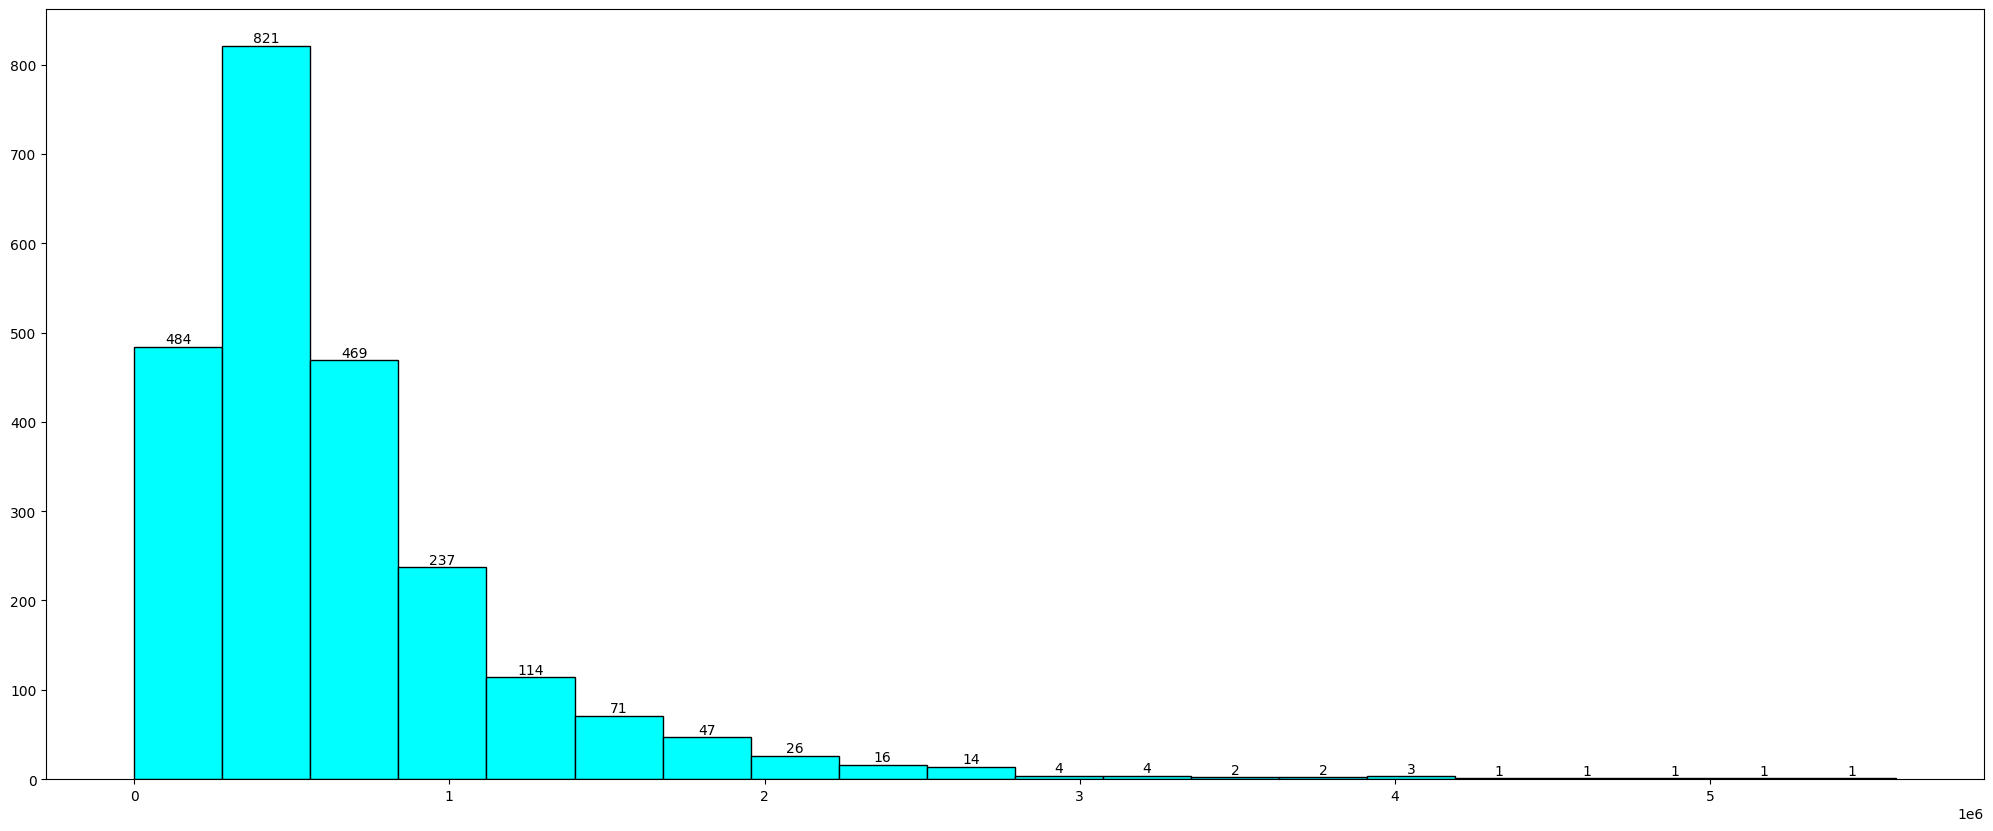

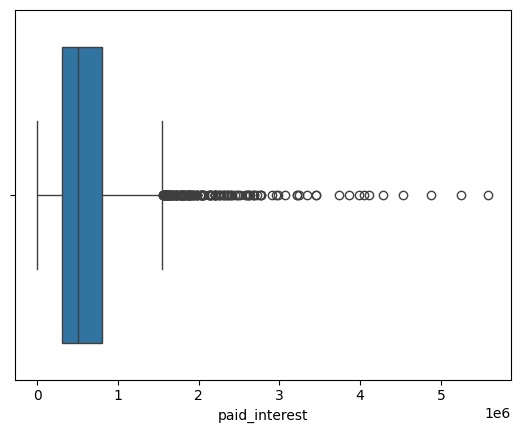

Description of paid_principal
----------------------------------------------------------------------------
count    2.319000e+03
mean     2.389494e+05
std      4.546814e+05
min      0.000000e+00
25%      6.463679e+04
50%      1.159271e+05
75%      2.208857e+05
max      7.458322e+06
Name: paid_principal, dtype: float64 Distribution of paid_principal
----------------------------------------------------------------------------
BoxPlot of paid_principal
----------------------------------------------------------------------------


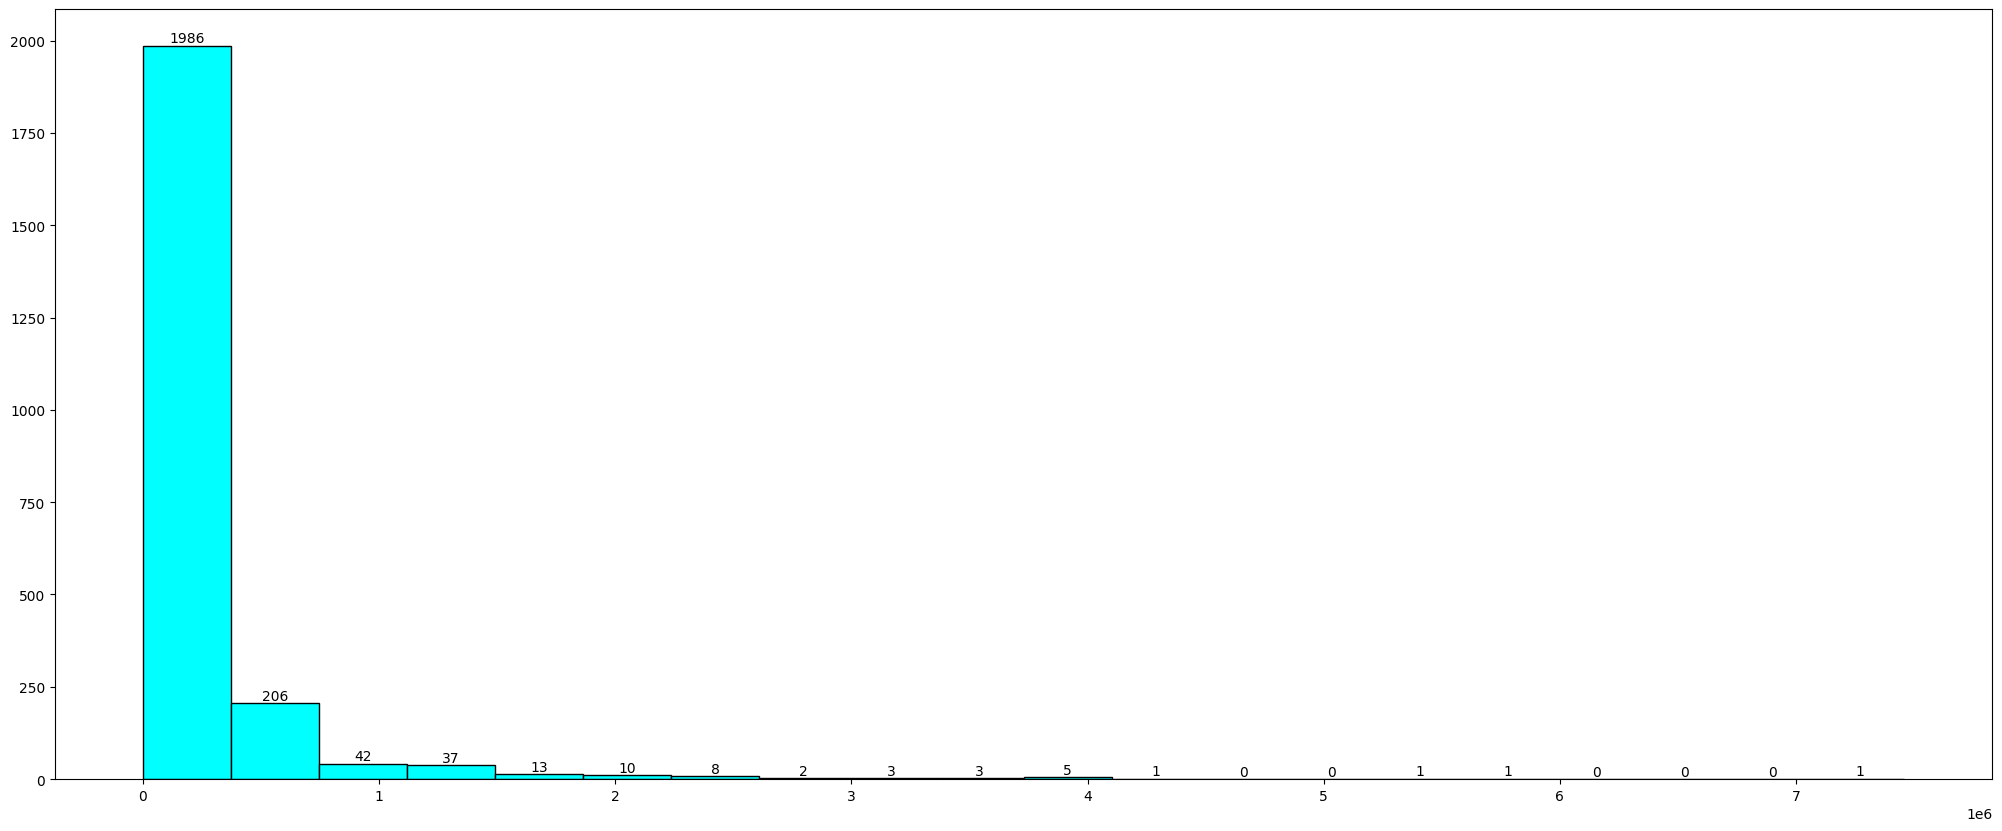

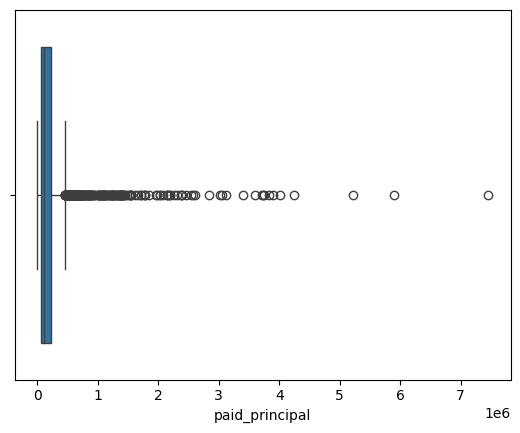

Description of pre_emi_dueamt
----------------------------------------------------------------------------
count    2.319000e+03
mean     5.630330e+04
std      1.176218e+05
min      0.000000e+00
25%      5.852663e+03
50%      1.687113e+04
75%      5.423541e+04
max      1.624202e+06
Name: pre_emi_dueamt, dtype: float64 Distribution of pre_emi_dueamt
----------------------------------------------------------------------------
BoxPlot of pre_emi_dueamt
----------------------------------------------------------------------------


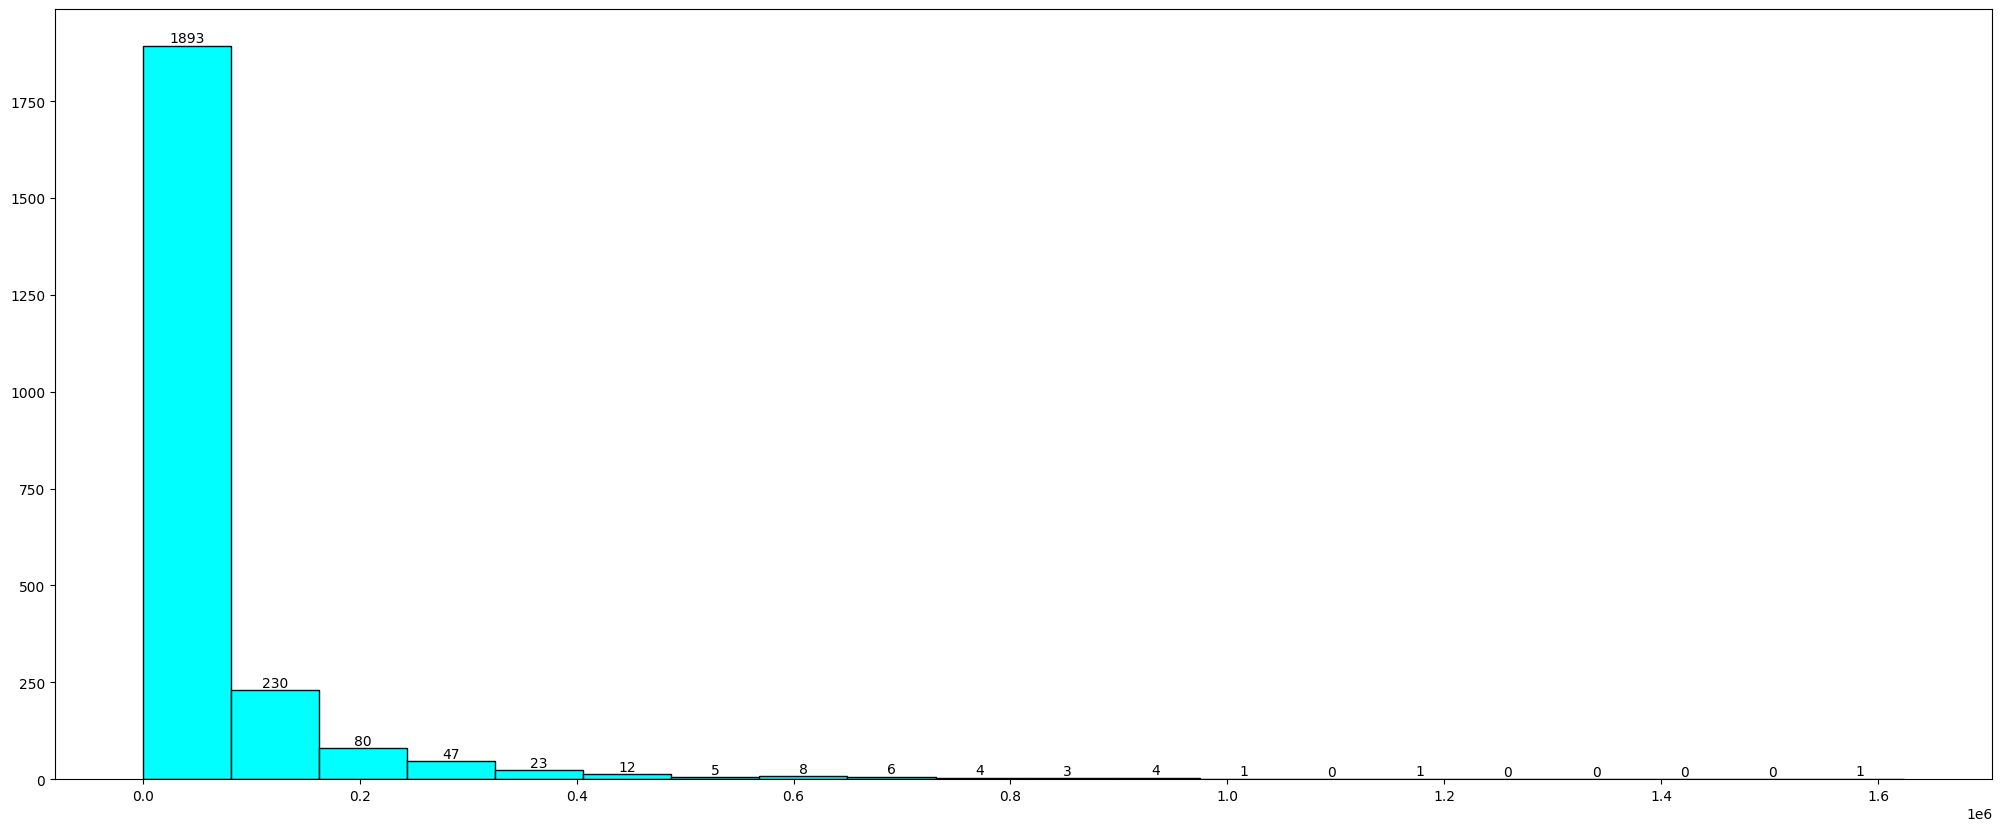

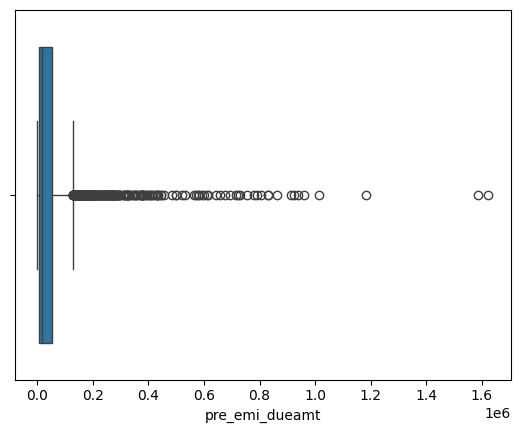

Description of pre_emi_received_amt
----------------------------------------------------------------------------
count    2.319000e+03
mean     5.562086e+04
std      1.155979e+05
min      0.000000e+00
25%      5.848246e+03
50%      1.687113e+04
75%      5.423541e+04
max      1.585701e+06
Name: pre_emi_received_amt, dtype: float64 Distribution of pre_emi_received_amt
----------------------------------------------------------------------------
BoxPlot of pre_emi_received_amt
----------------------------------------------------------------------------


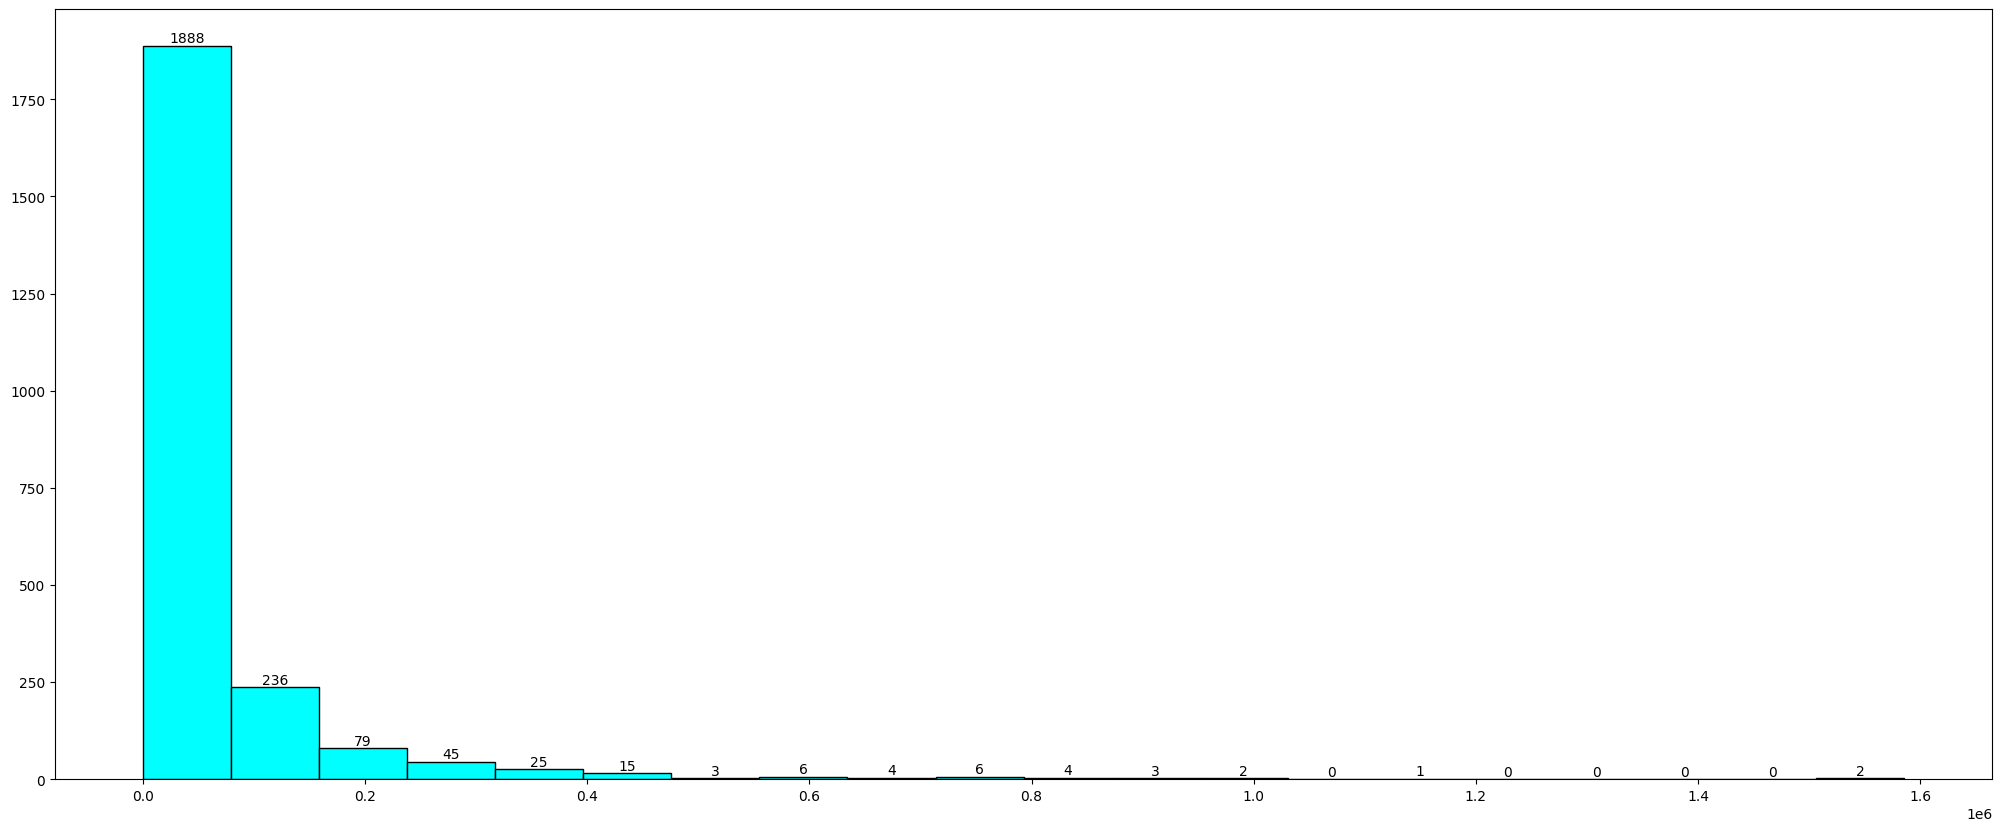

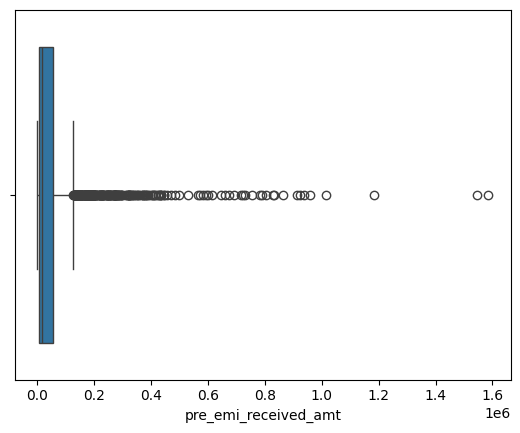

In [29]:
for x in lstnumericcolumns:
    univariateAnalysis_numeric(x,20)

#### Observations

- There are 33 numeric fields in the data

- Customer age ranges from 18 years to 65 years

- Only few customers have gross income more than 30L

- Current interest rate ranges from 11.07% to 19.97% with an average of 16%

- balance_tenure =0 (loans closed). Check outstanding_principal for these loans

- Average EMI amount being paid is around 18012

- Net Receivable of atleast 75% of customers is negative

- Average foir is 0.42

- Loan amount ranges from 175652 to max of 10893660

- Outliers to be treated

In [30]:
# Closed loans
df[df.balance_tenure==0]

,loan_account,age,gender,marital_status,qualification,gross_income,nettakehome,balance_tenure,city,completed_tenure,...,num_emi_changes,num_low_freq_transactions,num_of_emi_transactions,orignal_interest_rate,orignal_tenor,outstanding_principal,paid_interest,paid_principal,pre_emi_dueamt,pre_emi_received_amt
8,LA570,44,M,M,GRAD,90077.748,60502.22074,0,CHENNAI,49,...,2,6,50,17.479728,180,0.0,1.213050e+06,3.753240e+06,10737.979824,10737.979824
25,LA661,37,M,M,OTHERS,112597.185,112597.18500,0,COIMBATORE,56,...,1,2,61,17.479728,180,0.0,2.141698e+06,4.018367e+06,243530.403384,243530.403384


#### Observation

From above records looks like there are customers who are making advance payments to pay off their loan earlier.

num_low_freq_transactions maybe a field that will help us find these customers

In [31]:
df.num_low_freq_transactions.describe()

,num_low_freq_transactions
count,2319.000000
mean,4.567486
std,3.610644
min,0.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,21.000000


In [32]:
# Probable customers who are paying off their loans earlier
df[df.num_low_freq_transactions > 6]

,loan_account,age,gender,marital_status,qualification,gross_income,nettakehome,balance_tenure,city,completed_tenure,...,num_emi_changes,num_low_freq_transactions,num_of_emi_transactions,orignal_interest_rate,orignal_tenor,outstanding_principal,paid_interest,paid_principal,pre_emi_dueamt,pre_emi_received_amt
0,LA492,39,F,M,UG,63542.344735,63542.344735,111,MADURAI,70,...,11,10,73,17.479728,180,9.882910e+05,9.340537e+05,212745.625226,39959.331336,39959.331336
1,LA498,51,M,M,GRAD,81130.025032,81130.025032,107,MADURAI,68,...,3,11,73,17.479728,180,1.206218e+06,1.069305e+06,295078.188194,78774.632736,78774.632736
2,LA500,41,M,M,UG,56298.592500,56298.592500,50,MADURAI,70,...,13,10,73,17.479728,120,7.137100e+05,8.303592e+05,487326.621863,37918.629288,37918.629288
3,LA531,42,M,M,UG,74314.142100,74314.142100,110,MADURAI,70,...,13,17,72,17.479728,180,1.744746e+06,1.567354e+06,357068.193072,29375.950152,29375.950152
4,LA552,27,M,S,GRAD,64255.460240,64255.460240,112,MADURAI,69,...,14,10,71,17.479728,180,1.502039e+06,1.355995e+06,299516.018579,46048.309200,46048.309200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2293,LA5669,32,M,M,UG,40122.505579,40122.505579,220,MUMBAI,20,...,13,7,20,14.358348,240,2.180859e+06,3.936277e+05,47058.116851,5236.476792,5236.476792
2301,LA5697,44,M,M,GRAD,82314.051991,82314.047487,240,MUMBAI,0,...,4,8,18,14.358348,240,1.524213e+06,7.913330e+04,0.000000,376421.185776,116412.775920
2303,LA5699,35,M,M,MAT,74407.477660,74407.477660,223,MUMBAI,17,...,7,8,22,14.046210,240,2.753524e+06,5.205503e+05,53899.521812,151519.918512,151519.918512
2308,LA5709,53,M,M,UG,73053.053628,73053.053628,187,NAMAKKAL,17,...,9,9,22,16.231176,204,2.488135e+06,5.596275e+05,64067.798265,139688.705448,139688.705448


#### Observation

From above results we see that just *'num_low_freq_transactions'* may not be a feature driving advance closure. Other features like *'interest rate changes', 'emi_amount', 'pre_emi_recieved_amt', 'outstanding_principal'* are also contributing.

It is difficult to consider 33 numeric dimensions to analyze this behavior.
Hence, PCA can help to reduce dimensions, help in further analysis and derive patterns

Let us define a function **'univariateAnalysis_category'** to display information as part of univariate analysis of categorical variables.

The function should display the frequency of all the levels within the field and display a frequency plot

In [33]:
def univariateAnalysis_category(cat_column):
    print("Details of " + cat_column)
    print("----------------------------------------------------------------")
    print(df_cat[cat_column].value_counts())
    plt.figure()
    plt.figure(figsize=(12, 8))
    plots = df_cat[cat_column].value_counts().plot.bar(title="Frequency Distribution of " + cat_column)
    for bar in plots.patches:
        plots.annotate(format(bar.get_height(), '.2f'),
                   (bar.get_x() + bar.get_width() / 2,
                    bar.get_height()), ha='center', va='center',
                   size=15, xytext=(0, 8),
                   textcoords='offset points')
    plt.show()
    print("       ")

In [34]:
df_cat = df.select_dtypes(include = ['object'])
lstcatcolumns = list(df_cat.columns.values)
lstcatcolumns

['loan_account', 'gender', 'marital_status', 'qualification', 'city']

In [35]:
lstcatcolumns.remove('loan_account')

#### Bivariate Analysis

In [36]:
corr = df_num.corr(method='pearson')

Details of gender
----------------------------------------------------------------
gender
M    1994
F     325
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

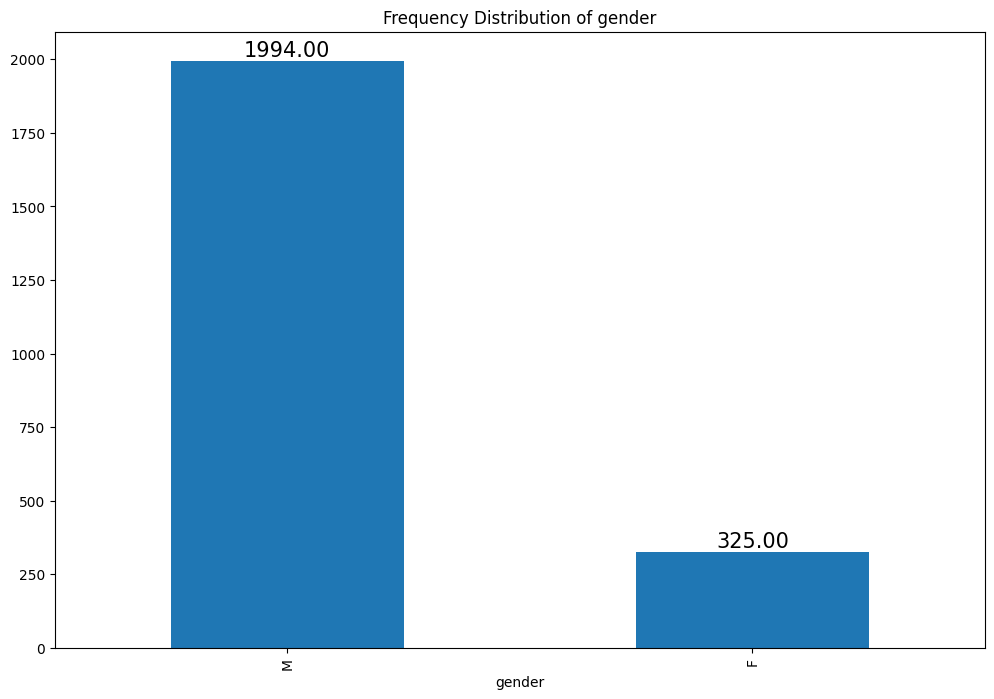

       
Details of marital_status
----------------------------------------------------------------
marital_status
M    2086
S     233
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

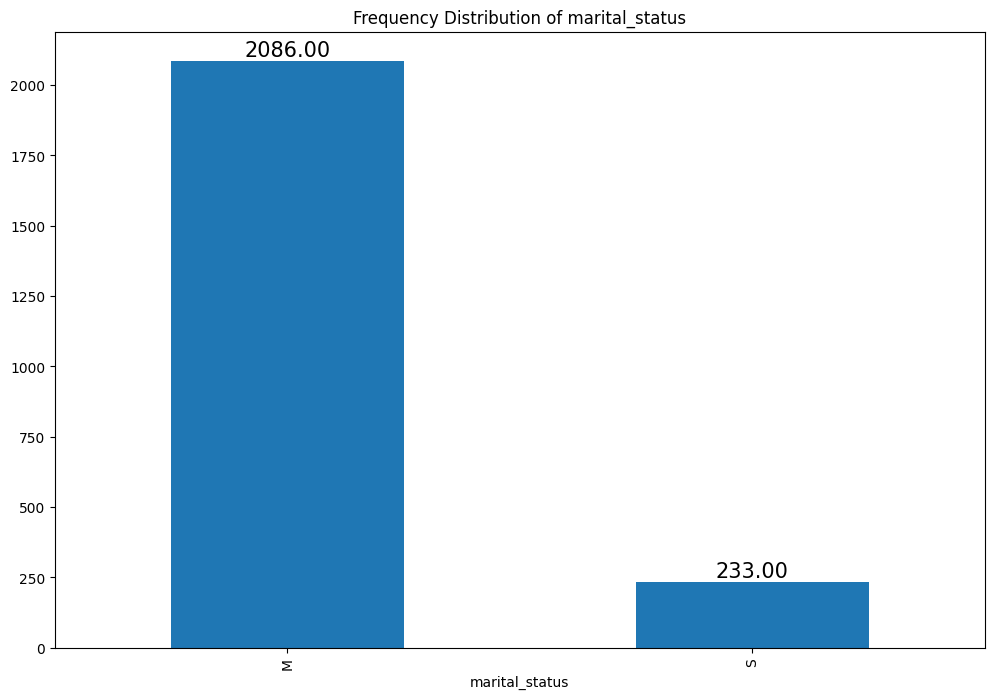

       
Details of qualification
----------------------------------------------------------------
qualification
UG          1548
GRAD         409
POSTGRAD     181
OTHERS       150
PRF           18
ENG            6
MAT            5
DOCTRATE       2
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

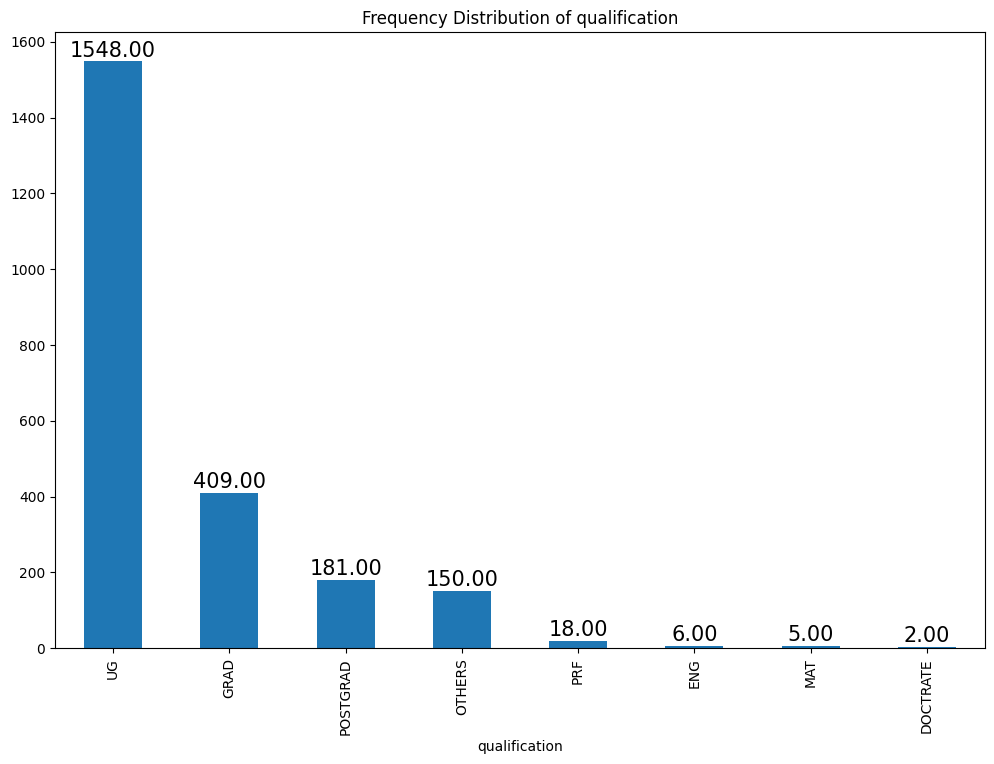

       
Details of city
----------------------------------------------------------------
city
MUMBAI             607
HYDERABAD          299
AHMEDABAD          165
CHENNAI            164
MADURAI            157
COIMBATORE         156
SURAT              136
ERODE               85
TIRUCHIRAPPALLI     78
PUNE                78
KARUR               65
TUTICORIN           64
TIRUPUR             63
WARANGAL            56
NAMAKKAL            56
BANGALORE           45
VISHAKHAPATNAM      45
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

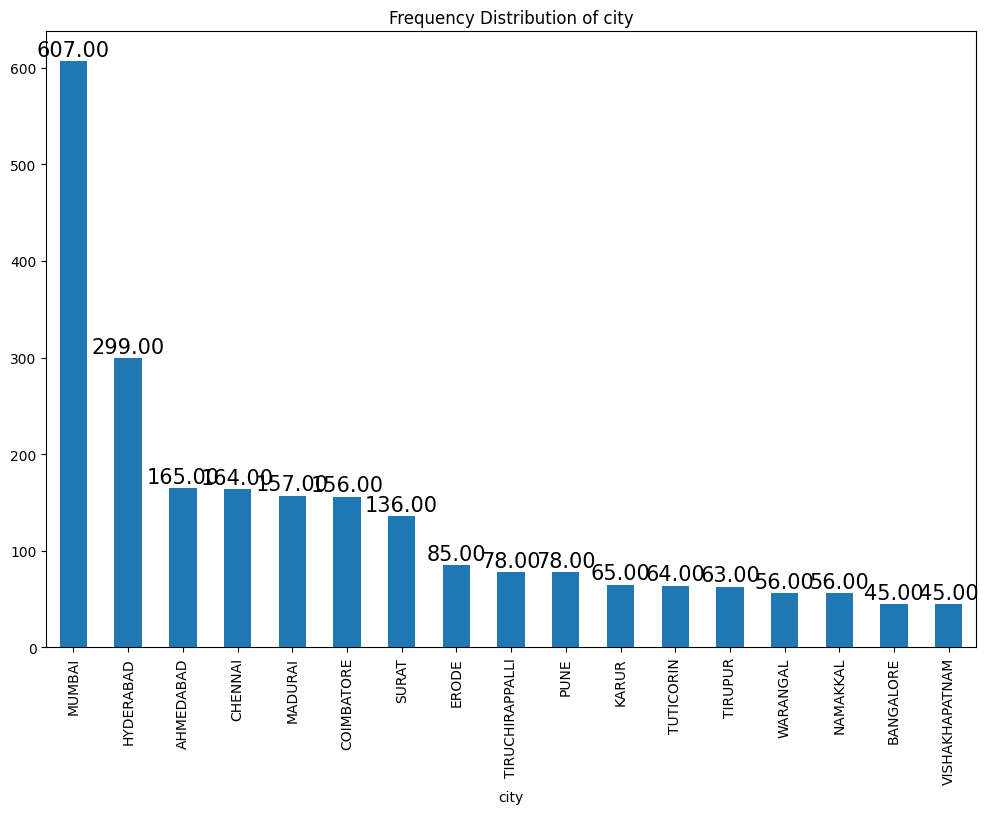

In [37]:
for x in lstcatcolumns:
    univariateAnalysis_category(x)

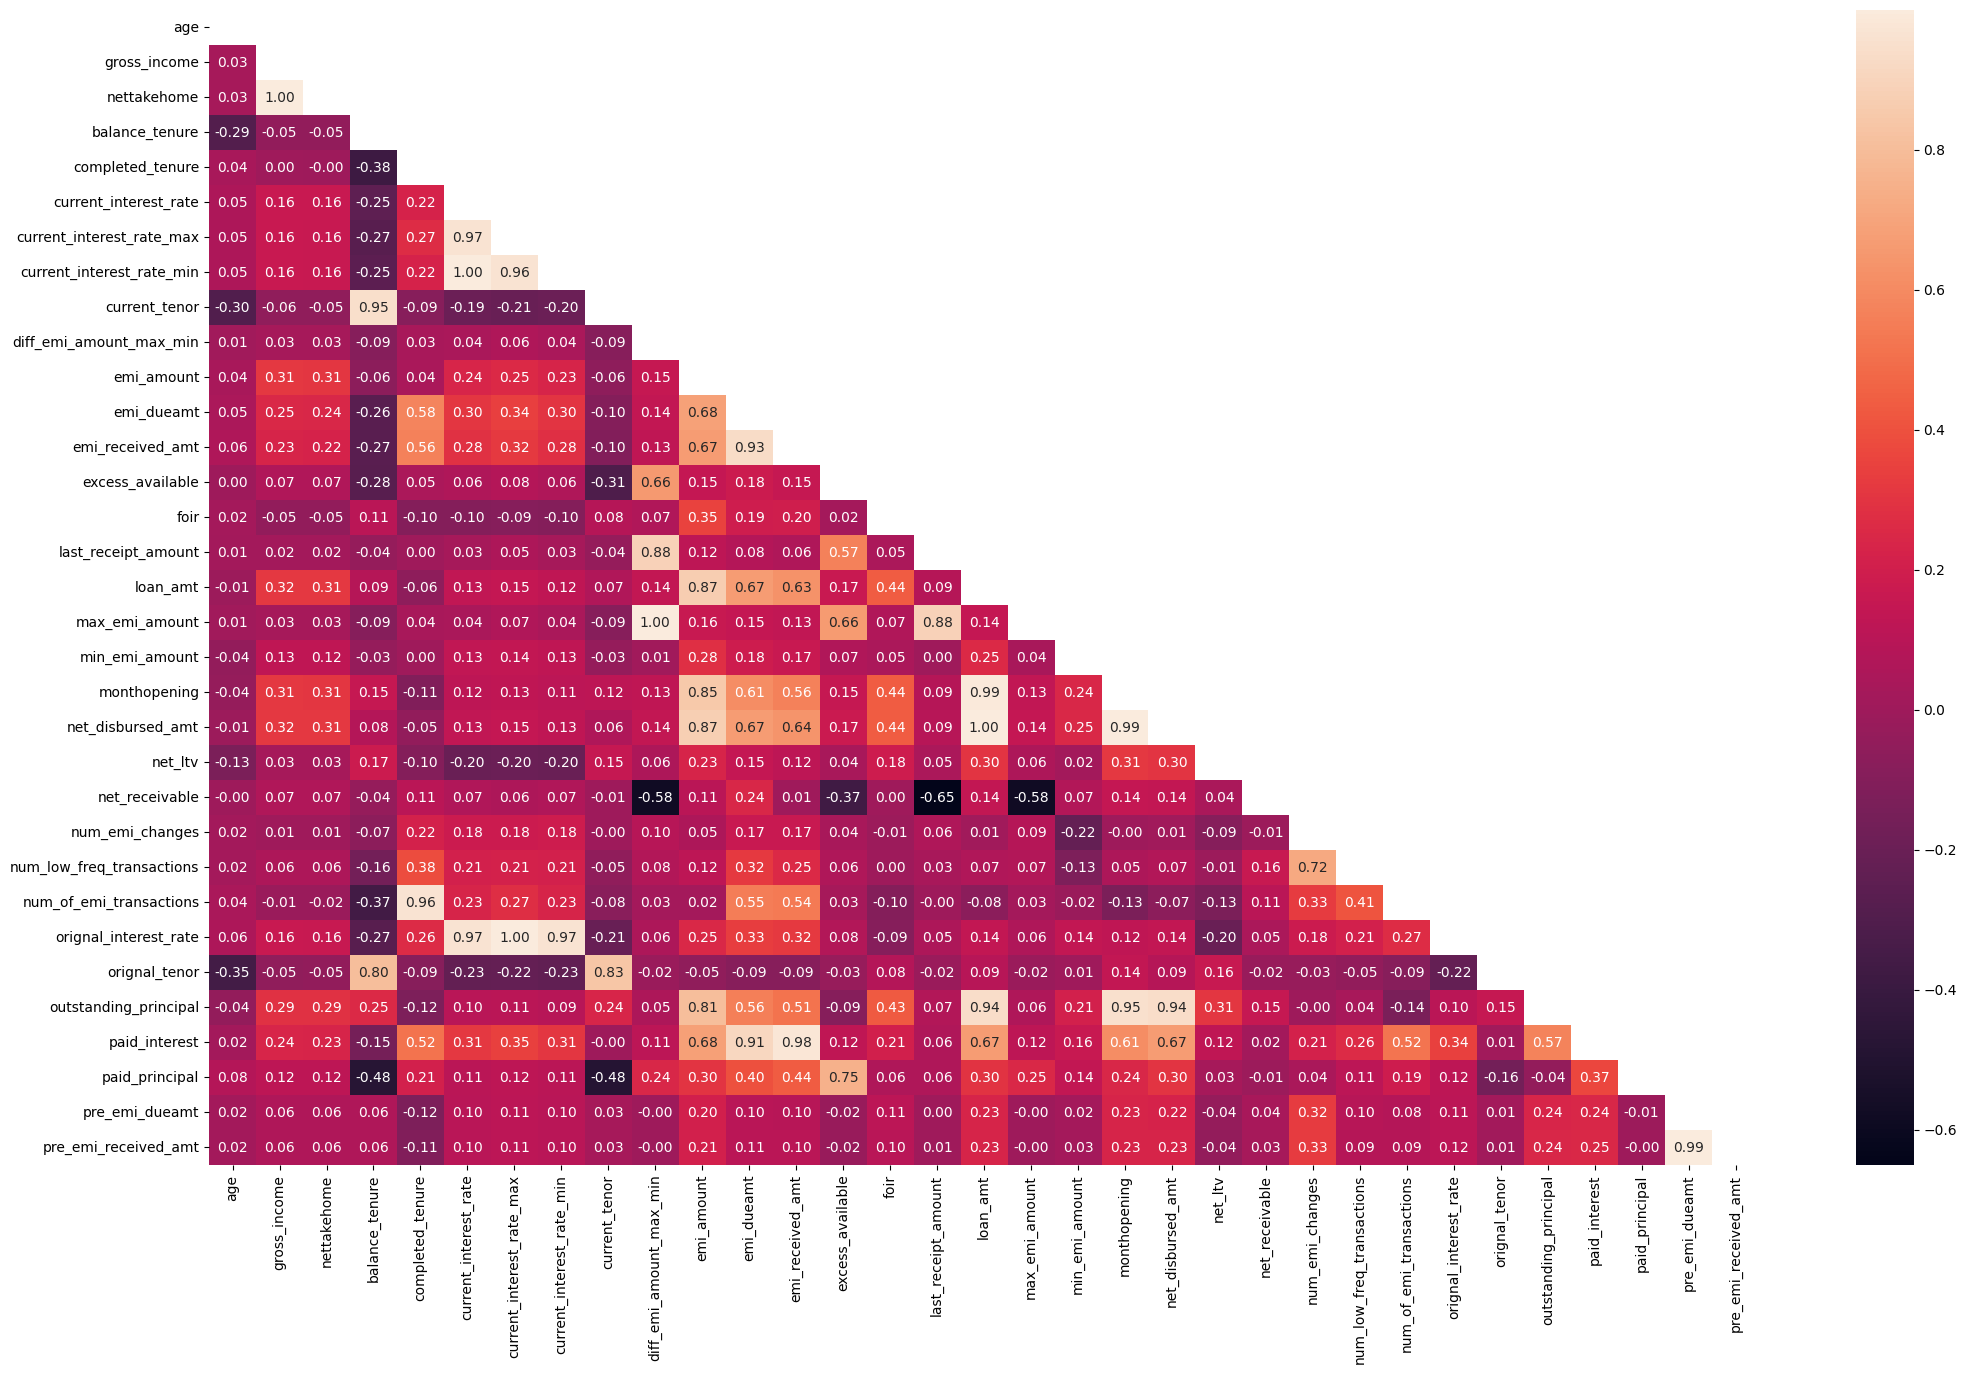

In [38]:
# Use 'bool' instead of 'np.bool'
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot the heatmap
fig, ax = plt.subplots(figsize=(25, 15))
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', mask=mask, ax=ax)
plt.show()

#### Observation

There are considerable number of features that are highly correlated.

- *'original_interest_rate'* shows high correlation with *'current_interest_rate','current_interest_rate_max','current_interest_rate_min'*

- *'paid_interest* has high correlation with *'emi_dueamt','emi_received_amt'* etc.

### Outlier Treatment

In [39]:
df_num.columns

Index(['age', 'gross_income', 'nettakehome', 'balance_tenure',
       'completed_tenure', 'current_interest_rate',
       'current_interest_rate_max', 'current_interest_rate_min',
       'current_tenor', 'diff_emi_amount_max_min', 'emi_amount', 'emi_dueamt',
       'emi_received_amt', 'excess_available', 'foir', 'last_receipt_amount',
       'loan_amt', 'max_emi_amount', 'min_emi_amount', 'monthopening',
       'net_disbursed_amt', 'net_ltv', 'net_receivable', 'num_emi_changes',
       'num_low_freq_transactions', 'num_of_emi_transactions',
       'orignal_interest_rate', 'orignal_tenor', 'outstanding_principal',
       'paid_interest', 'paid_principal', 'pre_emi_dueamt',
       'pre_emi_received_amt'],
      dtype='object')

In [40]:
len(lstnumericcolumns)

33

The description statistics for 'age' column is:


count    2319.000000
mean       39.451056
std         8.982396
min        18.000000
25%        32.000000
50%        39.000000
75%        46.000000
max        65.000000
Name: age, dtype: float64


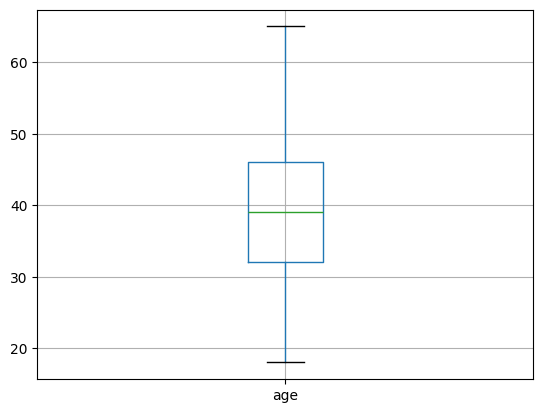

The description statistics for 'gross_income' column is:


count    2.319000e+03
mean     8.274157e+04
std      1.263460e+05
min      1.250579e+01
25%      4.203628e+04
50%      6.184963e+04
75%      9.118946e+04
max      4.261664e+06
Name: gross_income, dtype: float64


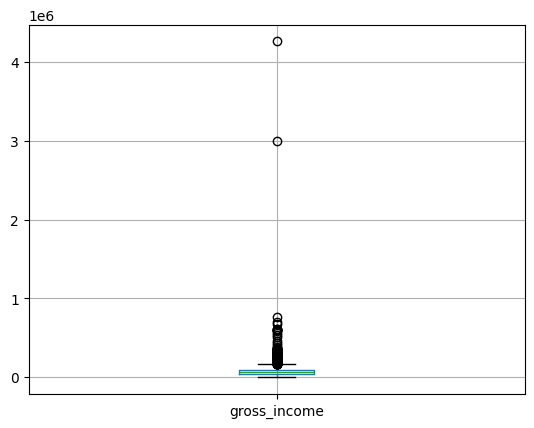

The description statistics for 'nettakehome' column is:


count    2.319000e+03
mean     8.194625e+04
std      1.266025e+05
min      1.246076e-01
25%      4.198749e+04
50%      6.050222e+04
75%      9.046402e+04
max      4.261664e+06
Name: nettakehome, dtype: float64


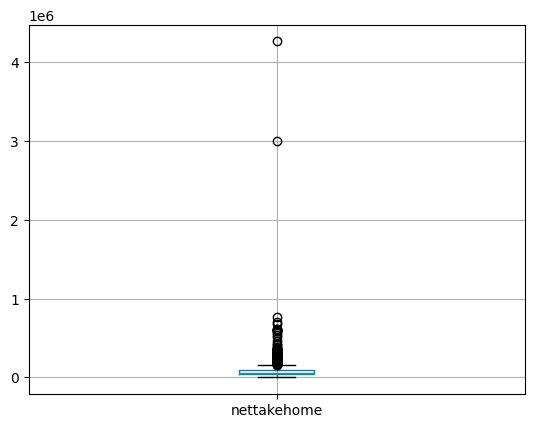

The description statistics for 'balance_tenure' column is:


count    2319.000000
mean      146.662786
std        45.138729
min         0.000000
25%       129.000000
50%       150.000000
75%       167.000000
max       307.000000
Name: balance_tenure, dtype: float64


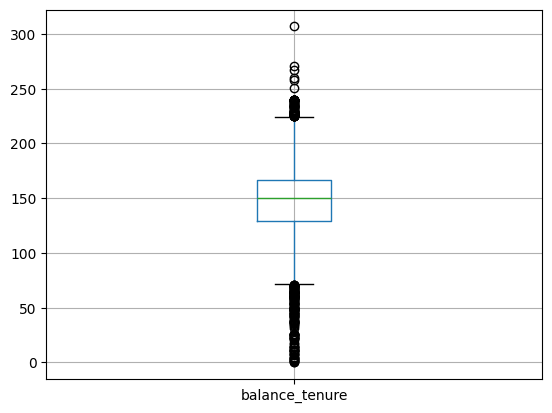

The description statistics for 'completed_tenure' column is:


count    2319.000000
mean       29.503665
std        13.490253
min         0.000000
25%        22.000000
50%        28.000000
75%        37.000000
max        70.000000
Name: completed_tenure, dtype: float64


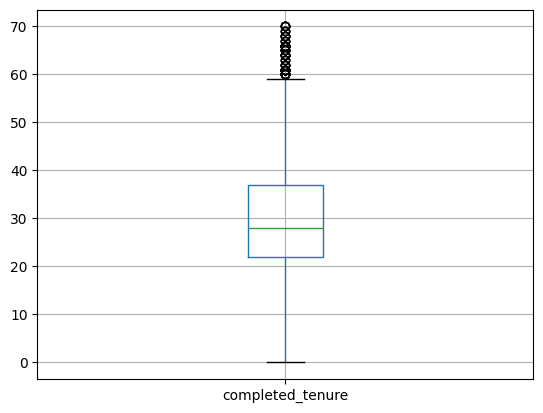

The description statistics for 'current_interest_rate' column is:


count    2319.000000
mean       15.698703
std         1.872893
min        11.074656
25%        14.046210
50%        15.919038
75%        17.479728
max        19.976832
Name: current_interest_rate, dtype: float64


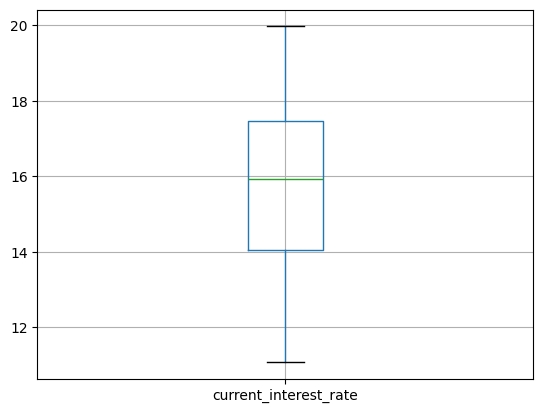

In [41]:
for i in range(0,6):
    print("The description statistics for '{}' column is:".format(lstnumericcolumns[i]))
    print('\n')
    print(df_num[lstnumericcolumns[i]].describe())
    df_num.boxplot(column=lstnumericcolumns[i])
    plt.show()

The description statistics for 'current_interest_rate_max' column is:


count    2319.000000
mean       15.783840
std         1.832462
min        11.074656
25%        14.358348
50%        15.919038
75%        17.479728
max        19.976832
Name: current_interest_rate_max, dtype: float64


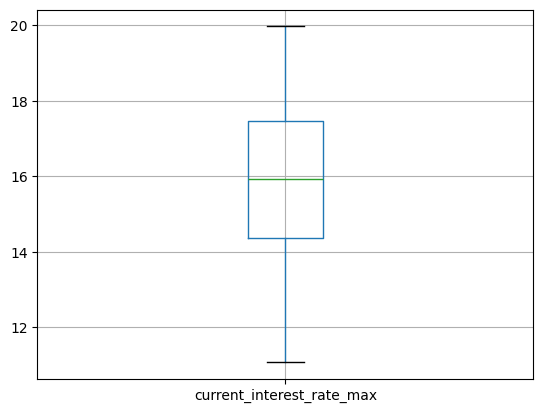

The description statistics for 'current_interest_rate_min' column is:


count    2319.000000
mean       15.684731
std         1.875045
min        11.074656
25%        14.046210
50%        15.919038
75%        17.479728
max        19.976832
Name: current_interest_rate_min, dtype: float64


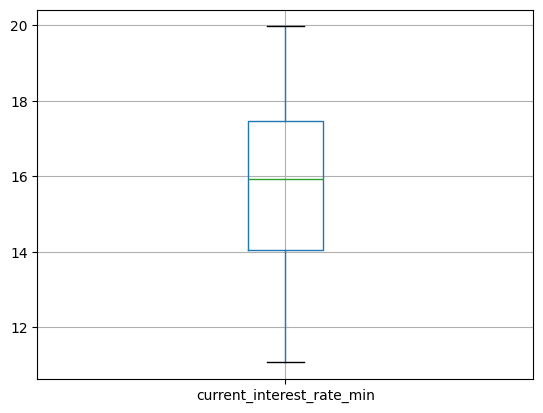

The description statistics for 'current_tenor' column is:


count    2319.000000
mean      175.971108
std        42.242628
min        10.000000
25%       173.000000
50%       180.000000
75%       181.000000
max       316.000000
Name: current_tenor, dtype: float64


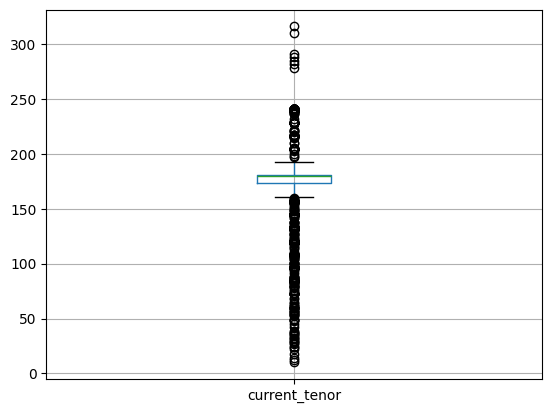

The description statistics for 'diff_emi_amount_max_min' column is:


count    2.319000e+03
mean     5.635589e+04
std      1.959045e+05
min      0.000000e+00
25%      1.029850e+04
50%      1.735000e+04
75%      2.860478e+04
max      3.229383e+06
Name: diff_emi_amount_max_min, dtype: float64


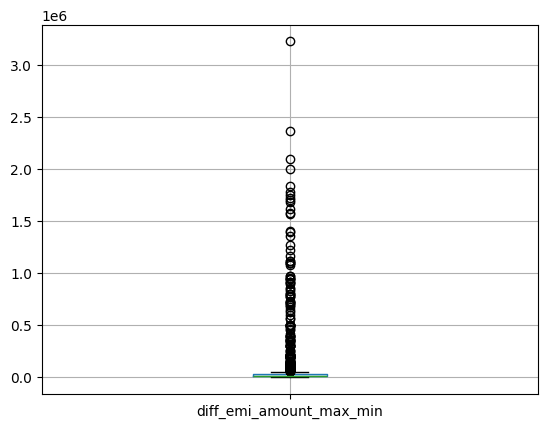

The description statistics for 'emi_amount' column is:


count      2319.000000
mean      18012.023109
std       12373.175124
min          14.370000
25%        9727.000000
50%       14650.000000
75%       22640.000000
max      120000.000000
Name: emi_amount, dtype: float64


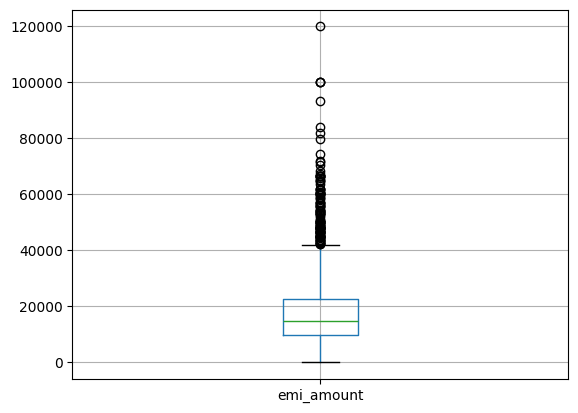

The description statistics for 'emi_dueamt' column is:


count    2.319000e+03
mean     1.191197e+06
std      1.064387e+06
min      0.000000e+00
25%      5.517018e+05
50%      8.936884e+05
75%      1.453225e+06
max      9.853225e+06
Name: emi_dueamt, dtype: float64


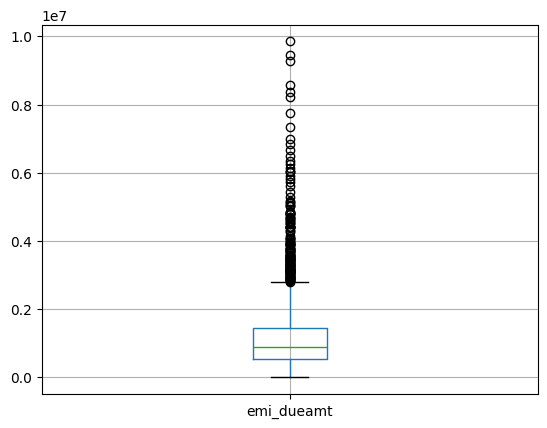

In [42]:
for i in range(6,12):
    print("The description statistics for '{}' column is:".format(lstnumericcolumns[i]))
    print('\n')
    print(df_num[lstnumericcolumns[i]].describe())
    df_num.boxplot(column=lstnumericcolumns[i])
    plt.show()

The description statistics for 'emi_received_amt' column is:


count    2.319000e+03
mean     1.132347e+06
std      9.800945e+05
min      0.000000e+00
25%      5.325923e+05
50%      8.662891e+05
75%      1.397185e+06
max      9.853225e+06
Name: emi_received_amt, dtype: float64


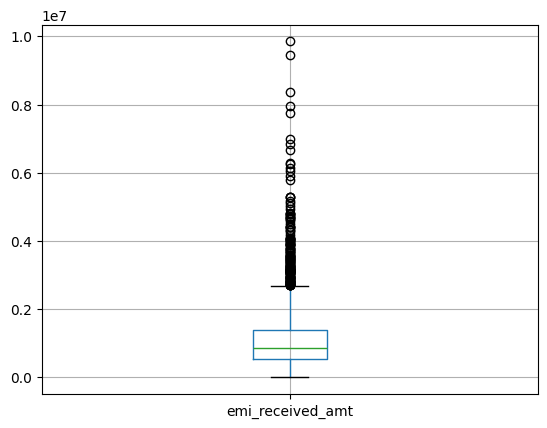

The description statistics for 'excess_available' column is:


count    2.319000e+03
mean     1.865469e+05
std      7.175169e+05
min      0.000000e+00
25%      0.000000e+00
50%      1.727088e+02
75%      3.881751e+03
max      1.021953e+07
Name: excess_available, dtype: float64


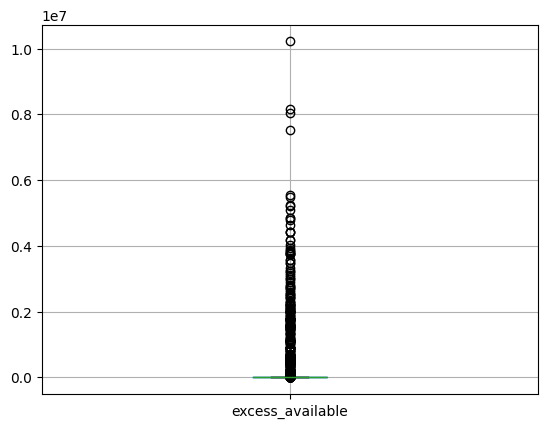

The description statistics for 'foir' column is:


count    2319.000000
mean        0.426229
std         0.146320
min         0.000000
25%         0.340000
50%         0.420000
75%         0.490000
max         1.001000
Name: foir, dtype: float64


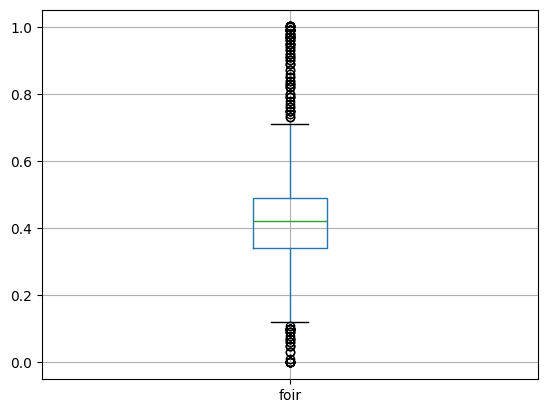

The description statistics for 'last_receipt_amount' column is:


count    2.319000e+03
mean     4.114352e+04
std      1.748835e+05
min      2.000000e+00
25%      9.316000e+03
50%      1.440500e+04
75%      2.307700e+04
max      3.229945e+06
Name: last_receipt_amount, dtype: float64


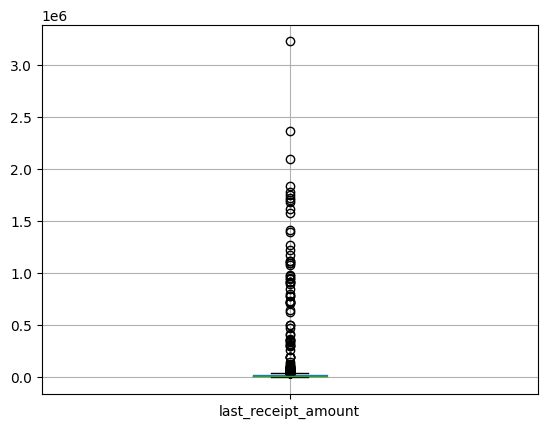

The description statistics for 'loan_amt' column is:


count    2.319000e+03
mean     2.194991e+06
std      1.349637e+06
min      1.756516e+05
25%      1.238569e+06
50%      1.801555e+06
75%      2.818683e+06
max      1.089366e+07
Name: loan_amt, dtype: float64


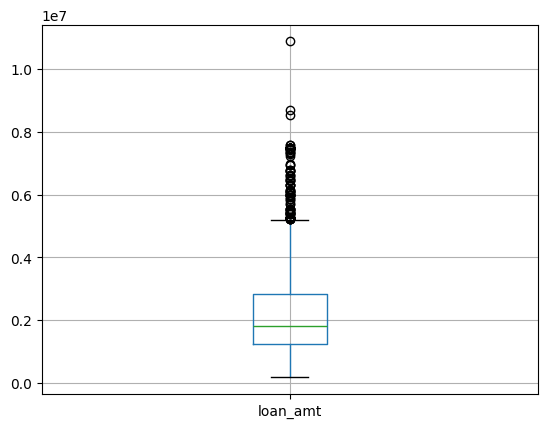

The description statistics for 'max_emi_amount' column is:


count    2.319000e+03
mean     5.807497e+04
std      1.960221e+05
min      5.620000e+02
25%      1.157300e+04
50%      1.897500e+04
75%      2.967650e+04
max      3.229945e+06
Name: max_emi_amount, dtype: float64


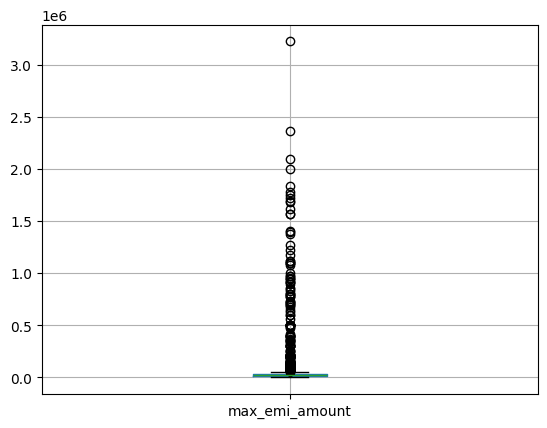

In [43]:
for i in range(12,18):
    print("The description statistics for '{}' column is:".format(lstnumericcolumns[i]))
    print('\n')
    print(df_num[lstnumericcolumns[i]].describe())
    df_num.boxplot(column=lstnumericcolumns[i])
    plt.show()

The description statistics for 'min_emi_amount' column is:


count     2319.000000
mean      1723.590298
std       5332.764547
min          0.090000
25%        115.000000
50%        115.000000
75%        573.000000
max      84001.000000
Name: min_emi_amount, dtype: float64


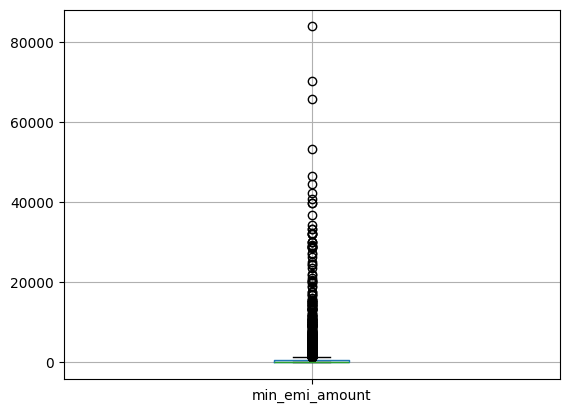

The description statistics for 'monthopening' column is:


count    2.319000e+03
mean     2.035442e+06
std      1.286849e+06
min      1.514357e+05
25%      1.135780e+06
50%      1.688189e+06
75%      2.620309e+06
max      1.080242e+07
Name: monthopening, dtype: float64


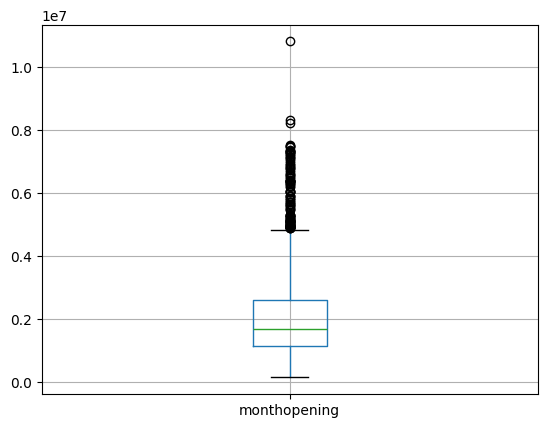

The description statistics for 'net_disbursed_amt' column is:


count    2.319000e+03
mean     2.189517e+06
std      1.349531e+06
min      1.756516e+05
25%      1.231063e+06
50%      1.801555e+06
75%      2.800199e+06
max      1.089366e+07
Name: net_disbursed_amt, dtype: float64


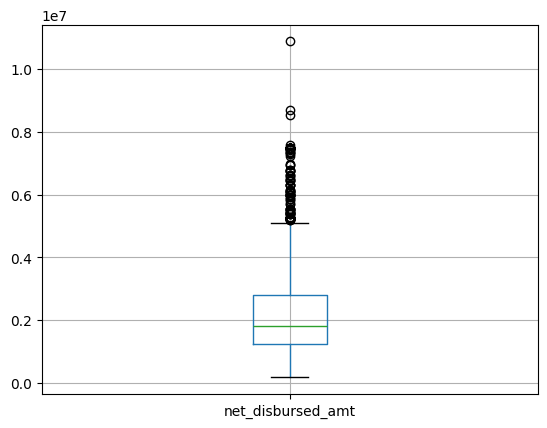

The description statistics for 'net_ltv' column is:


count    2319.000000
mean       51.570013
std        18.757921
min         5.220000
25%        36.800000
50%        52.070000
75%        68.890000
max        84.390000
Name: net_ltv, dtype: float64


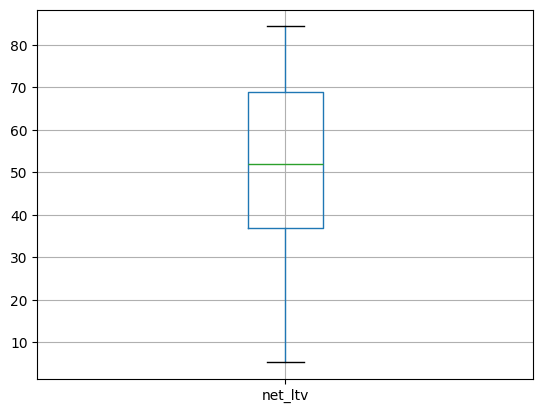

The description statistics for 'net_receivable' column is:


count    2.319000e+03
mean     4.978290e+03
std      5.257671e+05
min     -7.133502e+06
25%     -3.259933e+02
50%     -4.417104e-01
75%      0.000000e+00
max      8.252080e+06
Name: net_receivable, dtype: float64


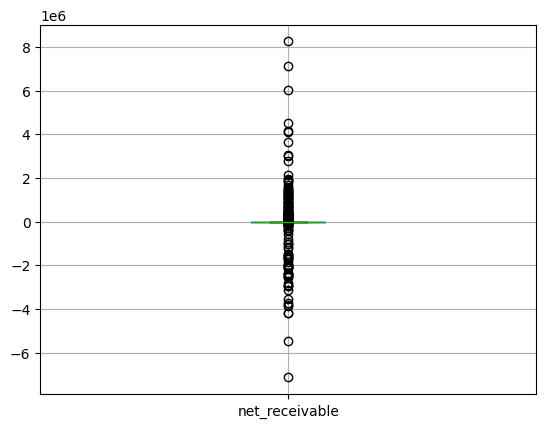

The description statistics for 'num_emi_changes' column is:


count    2319.000000
mean        5.356188
std         3.809970
min         0.000000
25%         3.000000
50%         4.000000
75%         7.000000
max        27.000000
Name: num_emi_changes, dtype: float64


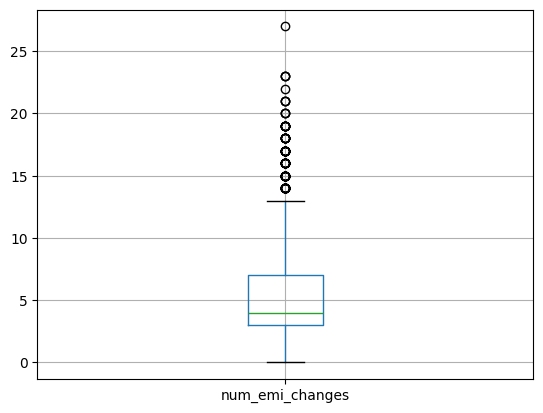

In [44]:
for i in range(18,24):
    print("The description statistics for '{}' column is:".format(lstnumericcolumns[i]))
    print('\n')
    print(df_num[lstnumericcolumns[i]].describe())
    df_num.boxplot(column=lstnumericcolumns[i])
    plt.show()

The description statistics for 'num_low_freq_transactions' column is:


count    2319.000000
mean        4.567486
std         3.610644
min         0.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        21.000000
Name: num_low_freq_transactions, dtype: float64


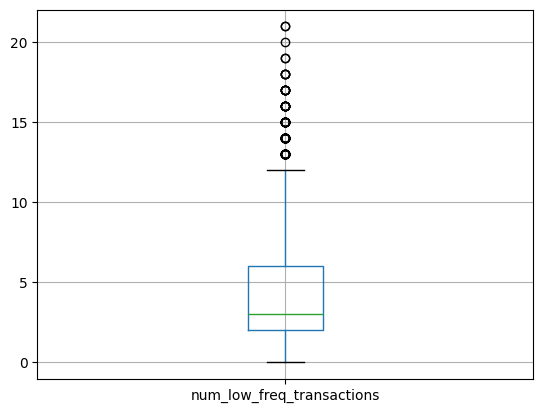

The description statistics for 'num_of_emi_transactions' column is:


count    2319.000000
mean       32.156102
std        13.251947
min         0.000000
25%        24.000000
50%        31.000000
75%        40.000000
max        73.000000
Name: num_of_emi_transactions, dtype: float64


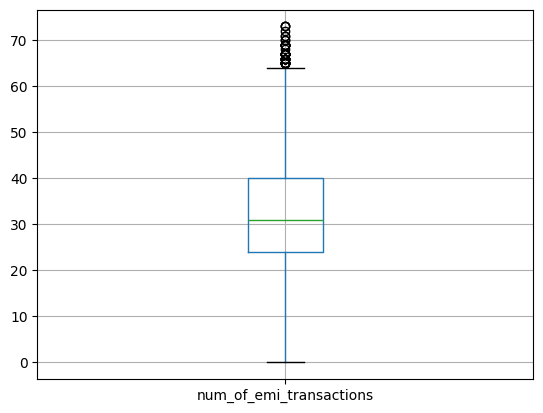

The description statistics for 'orignal_interest_rate' column is:


count    2319.000000
mean       15.768140
std         1.814290
min        11.074656
25%        14.358348
50%        15.919038
75%        17.479728
max        19.976832
Name: orignal_interest_rate, dtype: float64


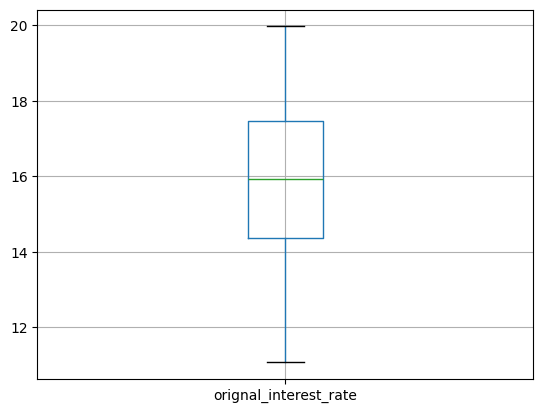

The description statistics for 'orignal_tenor' column is:


count    2319.000000
mean      180.867615
std        35.859160
min        60.000000
25%       180.000000
50%       180.000000
75%       180.000000
max       240.000000
Name: orignal_tenor, dtype: float64


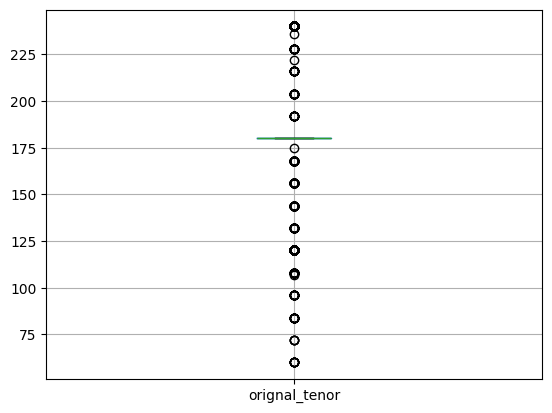

The description statistics for 'outstanding_principal' column is:


count    2.319000e+03
mean     1.949442e+06
std      1.289269e+06
min      0.000000e+00
25%      1.065798e+06
50%      1.606862e+06
75%      2.546081e+06
max      1.080242e+07
Name: outstanding_principal, dtype: float64


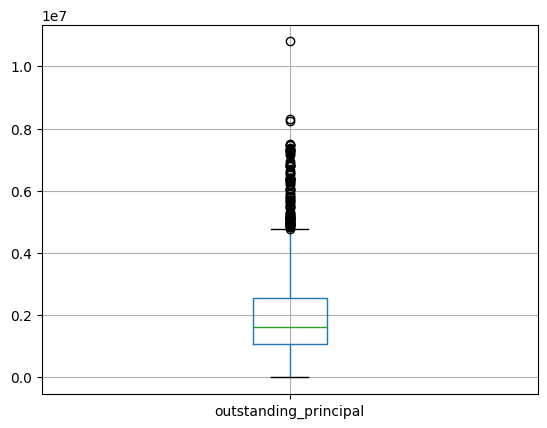

The description statistics for 'paid_interest' column is:


count    2.319000e+03
mean     6.538977e+05
std      5.553356e+05
min      0.000000e+00
25%      3.083669e+05
50%      5.082382e+05
75%      8.067100e+05
max      5.588191e+06
Name: paid_interest, dtype: float64


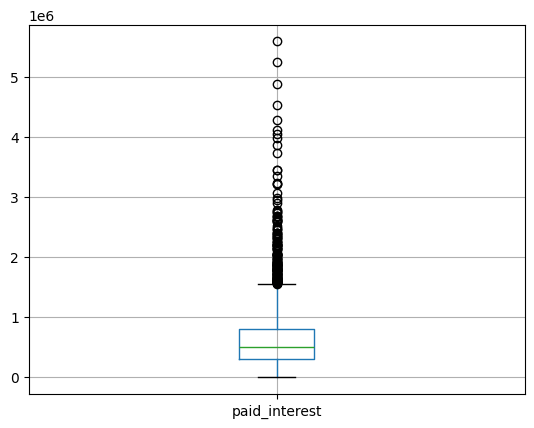

In [45]:
for i in range(24,30):
    print("The description statistics for '{}' column is:".format(lstnumericcolumns[i]))
    print('\n')
    print(df_num[lstnumericcolumns[i]].describe())
    df_num.boxplot(column=lstnumericcolumns[i])
    plt.show()

The description statistics for 'paid_principal' column is:


count    2.319000e+03
mean     2.389494e+05
std      4.546814e+05
min      0.000000e+00
25%      6.463679e+04
50%      1.159271e+05
75%      2.208857e+05
max      7.458322e+06
Name: paid_principal, dtype: float64


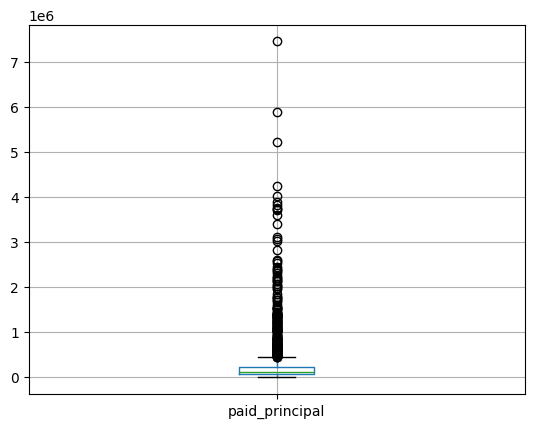

The description statistics for 'pre_emi_dueamt' column is:


count    2.319000e+03
mean     5.630330e+04
std      1.176218e+05
min      0.000000e+00
25%      5.852663e+03
50%      1.687113e+04
75%      5.423541e+04
max      1.624202e+06
Name: pre_emi_dueamt, dtype: float64


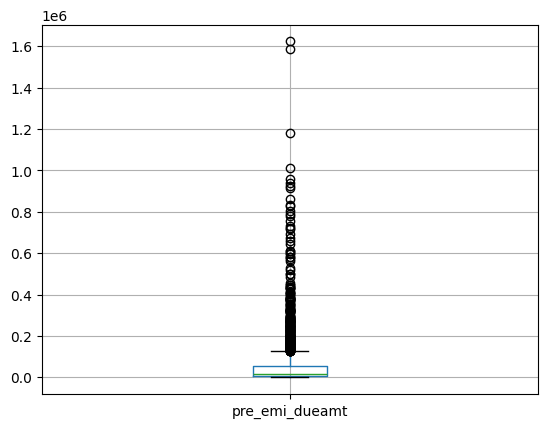

The description statistics for 'pre_emi_received_amt' column is:


count    2.319000e+03
mean     5.562086e+04
std      1.155979e+05
min      0.000000e+00
25%      5.848246e+03
50%      1.687113e+04
75%      5.423541e+04
max      1.585701e+06
Name: pre_emi_received_amt, dtype: float64


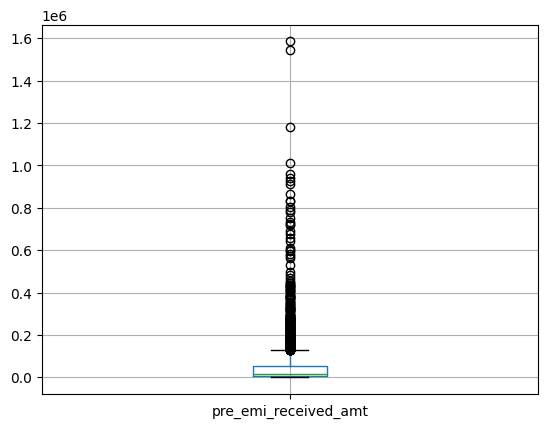

In [46]:
for i in range(30,33):
    print("The description statistics for '{}' column is:".format(lstnumericcolumns[i]))
    print('\n')
    print(df_num[lstnumericcolumns[i]].describe())
    df_num.boxplot(column=lstnumericcolumns[i])
    plt.show()

In [47]:
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

In [48]:
# The count of outliers in each column
((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR))).sum()

,0
age,0
gross_income,165
nettakehome,167
balance_tenure,222
completed_tenure,67
current_interest_rate,0
current_interest_rate_max,0
current_interest_rate_min,0
current_tenor,942
diff_emi_amount_max_min,233


In [49]:
((df_num > (Q3 + 1.5 * IQR)) & (df_num < df_num.quantile(0.95))).sum()

,0
age,0
gross_income,48
nettakehome,50
balance_tenure,0
completed_tenure,0
current_interest_rate,0
current_interest_rate_max,0
current_interest_rate_min,0
current_tenor,83
diff_emi_amount_max_min,116


In [50]:
no_outlier = ['age','current_interest_rate','current_interest_rate_max','current_interest_rate_min','net_ltv','orignal_interest_rate']

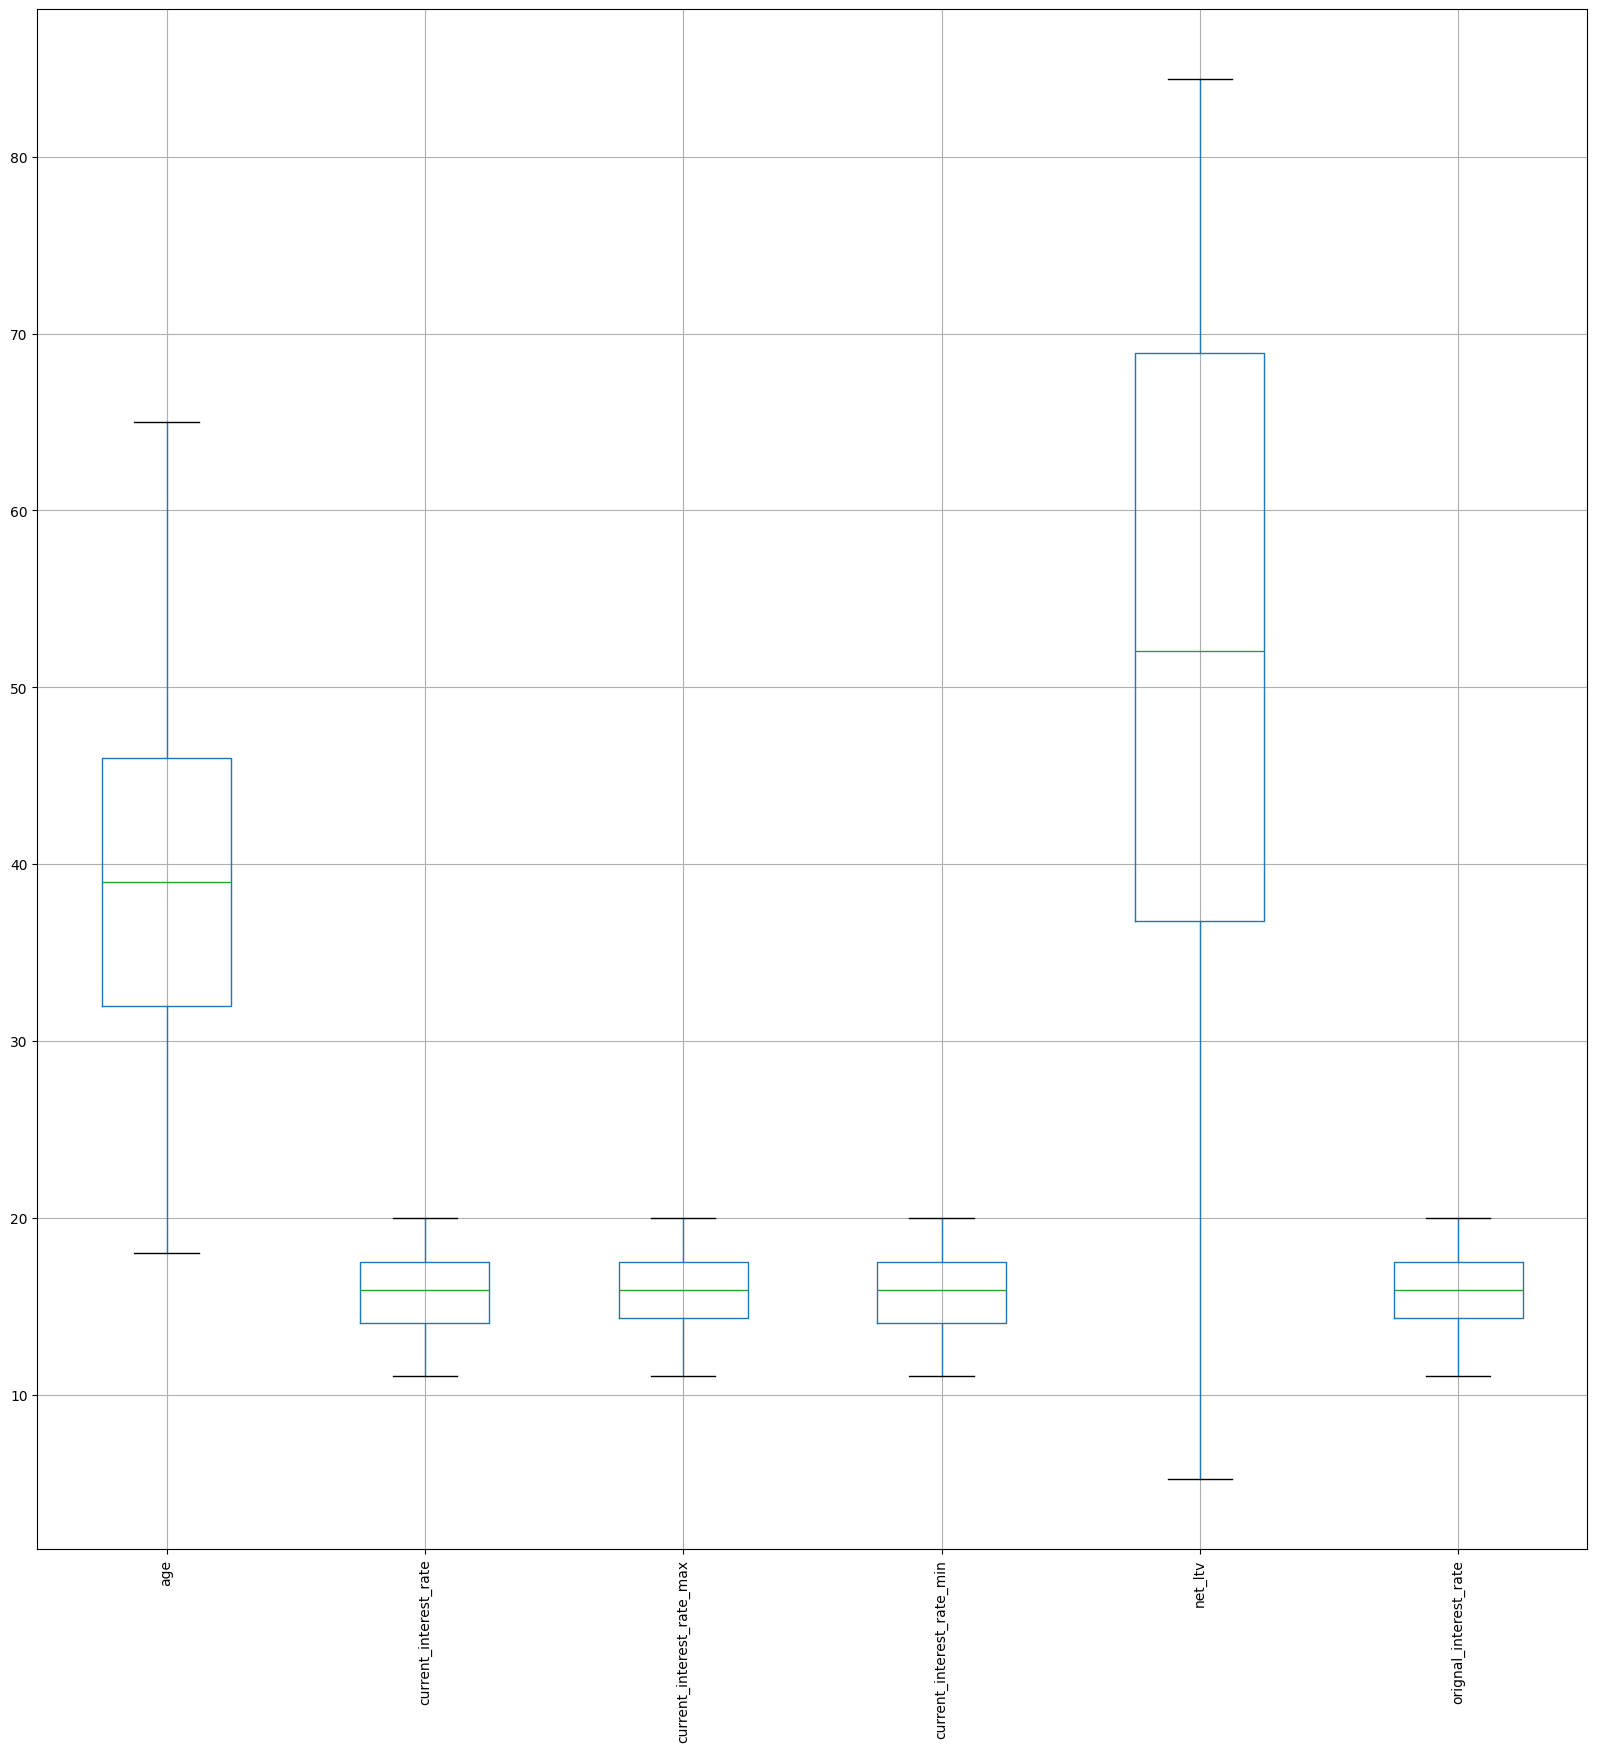

In [51]:
df_num[no_outlier].boxplot(figsize=(20,20))
plt.xticks(rotation=90)
plt.show()

To treat outliers lets define a function **'treat_outlier'**.

- For the higher outliers we will treat it to get it at 95 percentile value.

- Lower level outliers will be treated to get it at 5 percentile value.

In [52]:
def treat_outlier(x):
    # taking 5,25,75 percentile of column
    q5= np.percentile(x,5)
    q25=np.percentile(x,25)
    q75=np.percentile(x,75)
    q95=np.percentile(x,95)
    #calculationg IQR range
    IQR=q75-q25
    #Calculating minimum threshold
    lower_bound=q25-(1.5*IQR)
    upper_bound=q75+(1.5*IQR)
    #Capping outliers
    return x.apply(lambda y: q95 if y > q95 else y).apply(lambda y: q5 if y < q5 else y)

In [53]:
outlier_list = [x for x in df_num.columns if x not in no_outlier]

In [54]:
for i in df_num[outlier_list]:
    df_num[i]=treat_outlier(df_num[i])

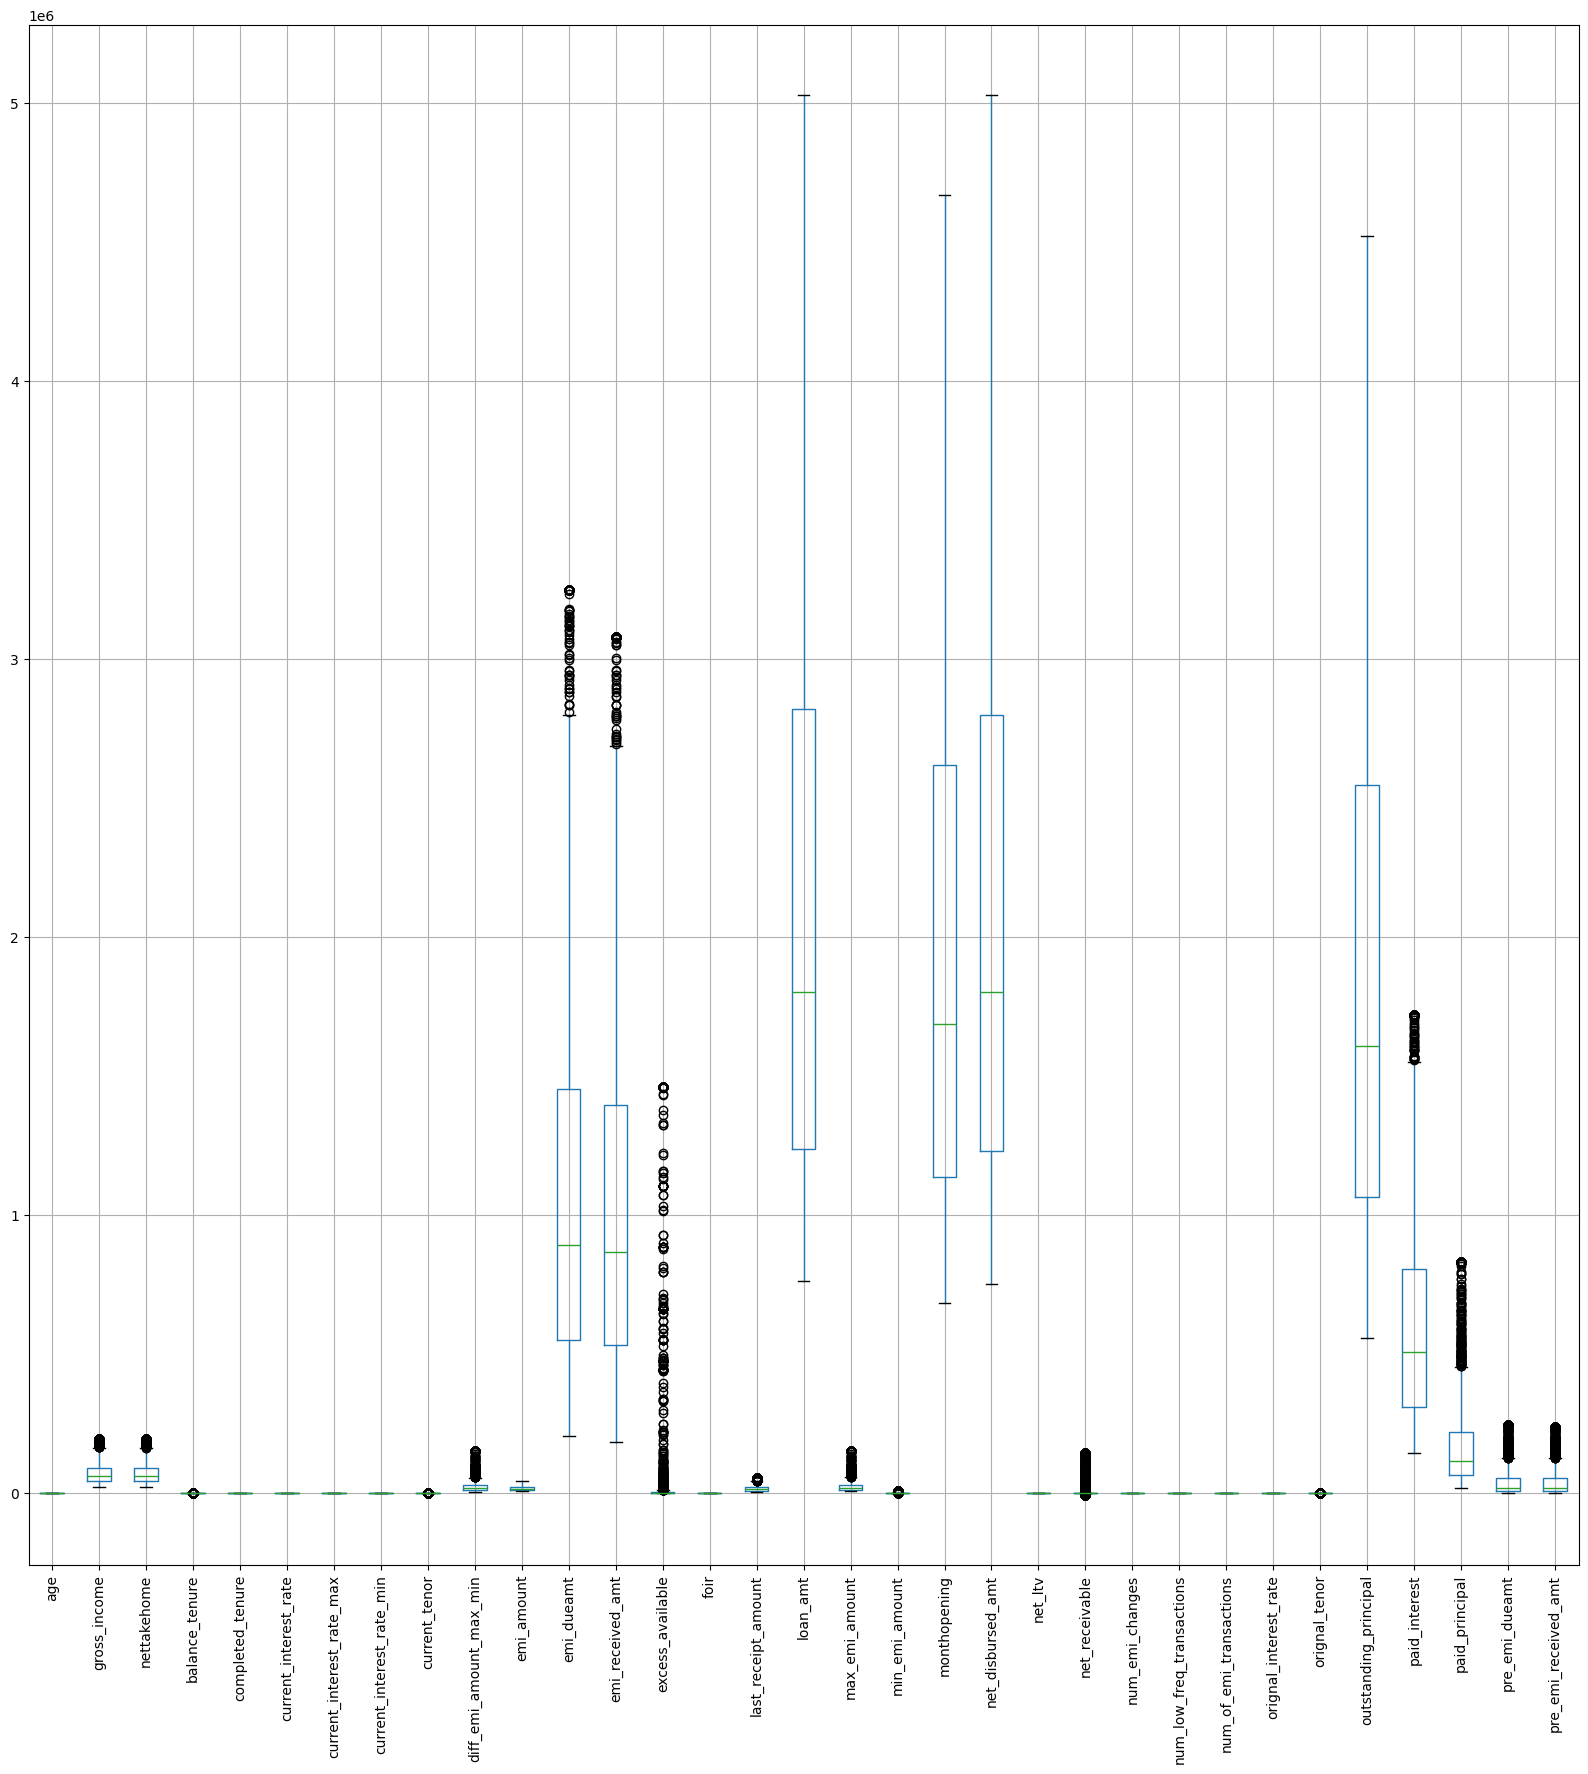

In [55]:
df_num.boxplot(figsize=(20,20))
plt.xticks(rotation=90)
plt.show()

## PCA

In [56]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2319 entries, 0 to 2318
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2319 non-null   int64  
 1   gross_income               2319 non-null   float64
 2   nettakehome                2319 non-null   float64
 3   balance_tenure             2319 non-null   float64
 4   completed_tenure           2319 non-null   float64
 5   current_interest_rate      2319 non-null   float64
 6   current_interest_rate_max  2319 non-null   float64
 7   current_interest_rate_min  2319 non-null   float64
 8   current_tenor              2319 non-null   float64
 9   diff_emi_amount_max_min    2319 non-null   float64
 10  emi_amount                 2319 non-null   float64
 11  emi_dueamt                 2319 non-null   float64
 12  emi_received_amt           2319 non-null   float64
 13  excess_available           2319 non-null   float

In [57]:
from scipy.stats import zscore
df_num_scaled=df_num.apply(zscore)
df_num_scaled.head()

,age,gross_income,nettakehome,balance_tenure,completed_tenure,current_interest_rate,current_interest_rate_max,current_interest_rate_min,current_tenor,diff_emi_amount_max_min,...,num_emi_changes,num_low_freq_transactions,num_of_emi_transactions,orignal_interest_rate,orignal_tenor,outstanding_principal,paid_interest,paid_principal,pre_emi_dueamt,pre_emi_received_amt
0,-0.050226,-0.246850,-0.238302,-0.890884,2.015377,0.951154,0.925669,0.957515,0.098061,-0.501624,...,1.758049,1.706934,2.065671,0.943596,-0.056297,-0.844576,0.737086,0.103205,-0.087763,-0.082033
1,1.286008,0.148167,0.156970,-0.988712,2.015377,-0.382421,0.925669,-0.374529,-0.060261,-0.443254,...,-0.692573,2.014859,2.065671,0.943596,-0.056297,-0.641724,1.057851,0.506657,0.516921,0.534626
2,0.172479,-0.409544,-0.401102,-2.089279,2.015377,0.951154,0.925669,0.957515,-1.511555,-0.440715,...,2.370704,1.706934,2.065671,0.943596,-1.845910,-1.100165,0.491162,1.448726,-0.119554,-0.114453
3,0.283832,-0.004917,0.003787,-0.915341,2.015377,0.951154,0.925669,0.957515,0.071674,0.295838,...,2.370704,2.322784,2.065671,0.943596,-0.056297,-0.140445,2.239032,0.810425,-0.252636,-0.250171
4,-1.386461,-0.230833,-0.222276,-0.866427,2.015377,0.951154,0.925669,0.957515,0.098061,0.115685,...,2.370704,1.706934,2.065671,0.943596,-0.056297,-0.366364,1.737770,0.528403,0.007095,0.014703


In [58]:
df_num_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2319 entries, 0 to 2318
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2319 non-null   float64
 1   gross_income               2319 non-null   float64
 2   nettakehome                2319 non-null   float64
 3   balance_tenure             2319 non-null   float64
 4   completed_tenure           2319 non-null   float64
 5   current_interest_rate      2319 non-null   float64
 6   current_interest_rate_max  2319 non-null   float64
 7   current_interest_rate_min  2319 non-null   float64
 8   current_tenor              2319 non-null   float64
 9   diff_emi_amount_max_min    2319 non-null   float64
 10  emi_amount                 2319 non-null   float64
 11  emi_dueamt                 2319 non-null   float64
 12  emi_received_amt           2319 non-null   float64
 13  excess_available           2319 non-null   float

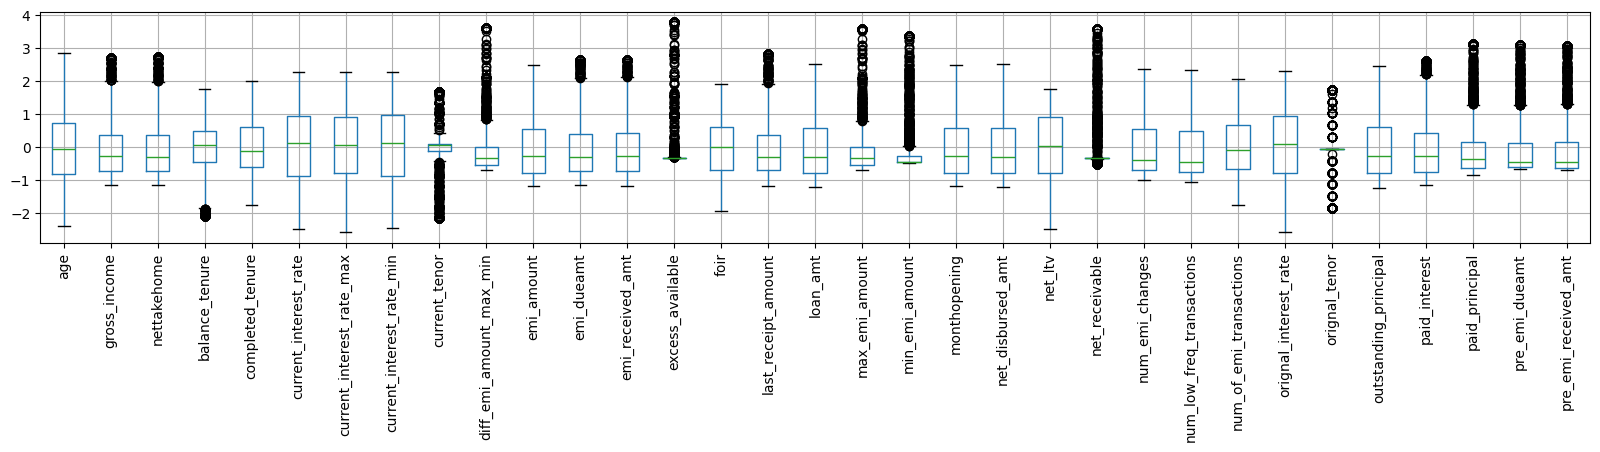

In [59]:
df_num_scaled.boxplot(figsize=(20,3))
plt.xticks(rotation=90)
plt.show()

### Statistical tests to be done before PCA

#### Bartletts Test of Sphericity
Bartlett's test of sphericity tests the hypothesis that the variables are uncorrelated in the population.

- H0: All variables in the data are uncorrelated
- Ha: At least one pair of variables in the data are correlated

If the null hypothesis cannot be rejected, then PCA is not advisable.

If the p-value is small, then we can reject the null hypothesis and agree that there is atleast one pair of vairbales in the data wihich are correlated hence PCA is recommended.

In [60]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value,p_value=calculate_bartlett_sphericity(df_num_scaled)
p_value

np.float64(0.0)

#### KMO Test

The Kaiser-Meyer-Olkin (KMO) - measure of sampling adequacy (MSA) is an index used to examine how appropriate PCA is.

Generally, if MSA is less than 0.5, PCA is not recommended, since no reduction is expected. On the other hand, MSA > 0.7 is expected to provide a considerable reduction is the dimension and extraction of meaningful components.

In [61]:
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all,kmo_model=calculate_kmo(df_num_scaled)
kmo_model

np.float64(0.8060961564266692)

In [62]:
from sklearn.decomposition import PCA
pca = PCA(n_components=33, random_state=123)
df_pca = pca.fit_transform(df_num_scaled)
df_pca.transpose().round(2)

array([[ 0.15,  0.69,  0.71, ..., -3.11, -1.75, -3.19],
       [-4.01, -2.94, -5.71, ...,  0.36,  0.87,  0.68],
       [-0.87,  0.28,  0.79, ..., -0.45,  0.37,  2.74],
       ...,
       [-0.  , -0.06, -0.  , ..., -0.  , -0.03, -0.  ],
       [ 0.01, -0.  ,  0.  , ...,  0.  , -0.  , -0.  ],
       [ 0.01,  0.01,  0.03, ...,  0.01,  0.  , -0.  ]])

In [63]:
#Step 1: Obtaining the Eigen Vectors when the Principal Components are kept exactly as the number of features in the scaled data
print('Eigen Vectors \n %s',pca.components_.round(2))

Eigen Vectors 
 %s [[ 0.02  0.22  0.22 ...  0.16  0.08  0.08]
 [-0.1   0.03  0.03 ... -0.12  0.02  0.01]
 [ 0.11 -0.06 -0.07 ...  0.34 -0.18 -0.18]
 ...
 [-0.    0.   -0.01 ...  0.    0.69 -0.69]
 [-0.   -0.    0.   ... -0.   -0.02  0.02]
 [-0.   -0.01  0.01 ... -0.    0.09 -0.1 ]]


In [64]:
var_exp = pca.explained_variance_ratio_
print(var_exp.round(2))

[0.3  0.15 0.09 0.08 0.07 0.06 0.04 0.04 0.03 0.03 0.02 0.02 0.02 0.01
 0.01 0.01 0.01 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.  ]


In [65]:
# Step 2: Obtaining the Cumulative Sum of the Expalained Variance
cum_var_exp = np.cumsum(var_exp)
print('Cumulative Variance Explained in Percentage:',(cum_var_exp*100).round(2))

Cumulative Variance Explained in Percentage: [ 29.77  45.05  54.5   62.7   69.7   75.51  79.95  83.54  86.4   88.96
  91.1   93.09  94.83  96.33  97.27  97.96  98.52  98.94  99.23  99.5
  99.67  99.77  99.85  99.89  99.91  99.94  99.96  99.97  99.98  99.99
  99.99 100.   100.  ]


- We can see above that more than 84% of the variance is explained by 8 Principal Components.
- Around 93% of the variance is explained by 12 Principal Components.
- Around 97% of the variance is explained by 15 Principal Components.

### Scree plot

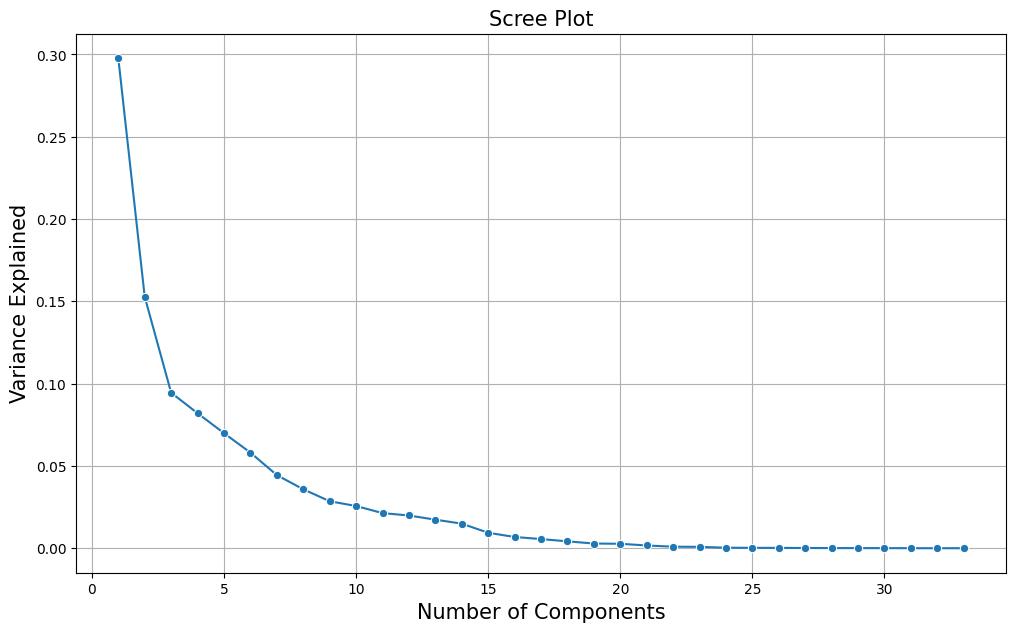

In [66]:
# Step 3 View Scree Plot to identify the number of components to be built
plt.figure(figsize=(12,7))
sns.lineplot(y=var_exp,x=range(1,len(var_exp)+1),marker='o')
plt.xlabel('Number of Components',fontsize=15)
plt.ylabel('Variance Explained',fontsize=15)
plt.title('Scree Plot',fontsize=15)
plt.grid()
plt.show()

#### The number of components can be decided based upon the explained variance. Here, it is decided to keep the number of components as 8 as the cumulative explained variance is around 84%

In [67]:
# Step 4 Apply PCA for the number of decided components to get the loadings and component output

# Using scikit learn PCA here. It does all the above steps and maps data to PCA dimensions in one shot
from sklearn.decomposition import PCA
# NOTE - we are generating only 8 PCA dimensions (dimensionality reduction from 33 to 8)
pca = PCA(n_components=8, random_state=123)
df_pca = pca.fit_transform(df_num_scaled)
df_pca.transpose().round(2) # Component output

array([[ 0.15,  0.69,  0.71, ..., -3.11, -1.75, -3.19],
       [-4.01, -2.94, -5.71, ...,  0.36,  0.87,  0.68],
       [-0.87,  0.28,  0.79, ..., -0.45,  0.37,  2.74],
       ...,
       [ 0.04, -1.33, -1.09, ...,  0.97,  0.14, -0.79],
       [ 0.24, -0.26,  0.87, ...,  0.19,  1.82,  0.21],
       [-0.42, -0.58,  0.1 , ...,  0.66,  1.17,  0.86]])

In [68]:
df_pca.shape

(2319, 8)

In [69]:
# Loading of each feature on the components
# Eigen Vectors when PC's are kept as 8
pca.components_.round(2)

array([[ 0.02,  0.22,  0.22, -0.07,  0.09,  0.15,  0.16,  0.15, -0.05,
         0.17,  0.28,  0.28,  0.27,  0.07,  0.11,  0.24,  0.27,  0.18,
         0.06,  0.26,  0.27,  0.06,  0.11,  0.07,  0.1 ,  0.09,  0.16,
        -0.04,  0.24,  0.27,  0.16,  0.08,  0.08],
       [-0.1 ,  0.03,  0.03,  0.31, -0.25, -0.27, -0.27, -0.27,  0.26,
         0.02,  0.13, -0.05, -0.05, -0.06,  0.16,  0.09,  0.21,  0.03,
         0.  ,  0.23,  0.2 ,  0.2 , -0.02, -0.12, -0.13, -0.25, -0.27,
         0.25,  0.24, -0.02, -0.12,  0.02,  0.01],
       [ 0.11, -0.06, -0.07, -0.28,  0.09, -0.29, -0.28, -0.29, -0.28,
         0.25,  0.  ,  0.06,  0.07,  0.3 ,  0.05,  0.09, -0.  ,  0.24,
        -0.06, -0.03, -0.  ,  0.08, -0.06, -0.07, -0.  ,  0.05, -0.28,
        -0.18, -0.1 , -0.01,  0.34, -0.18, -0.18],
       [-0.12, -0.19, -0.19,  0.14,  0.38, -0.15, -0.13, -0.15,  0.27,
        -0.01, -0.07,  0.19,  0.19, -0.1 ,  0.03, -0.06, -0.05, -0.03,
        -0.14, -0.06, -0.05,  0.05,  0.14,  0.29,  0.31,  0.4 , -0

In [70]:
var_exp_1 = pca.explained_variance_ratio_.round(2)

In [71]:
#Check the explained variance for each PC.
#Note: Explained variance = (eigen value of each PC)/(sum of eigen values of all PCs)
# It gives the Eigen Values when PC's are kept at 8
pca.explained_variance_ratio_.round(2)

array([0.3 , 0.15, 0.09, 0.08, 0.07, 0.06, 0.04, 0.04])

Let's create a dataframe of component loading against each field and identify the pattern

In [72]:
# Component loading when PC's are kept as 8
df_pca_loading = pd.DataFrame(pca.components_.round(2),columns=list(df_num_scaled))
df_pca_loading.shape

(8, 33)

In [73]:
df_pca_loading.head(8)

,age,gross_income,nettakehome,balance_tenure,completed_tenure,current_interest_rate,current_interest_rate_max,current_interest_rate_min,current_tenor,diff_emi_amount_max_min,...,num_emi_changes,num_low_freq_transactions,num_of_emi_transactions,orignal_interest_rate,orignal_tenor,outstanding_principal,paid_interest,paid_principal,pre_emi_dueamt,pre_emi_received_amt
0,0.02,0.22,0.22,-0.07,0.09,0.15,0.16,0.15,-0.05,0.17,...,0.07,0.10,0.09,0.16,-0.04,0.24,0.27,0.16,0.08,0.08
1,-0.10,0.03,0.03,0.31,-0.25,-0.27,-0.27,-0.27,0.26,0.02,...,-0.12,-0.13,-0.25,-0.27,0.25,0.24,-0.02,-0.12,0.02,0.01
2,0.11,-0.06,-0.07,-0.28,0.09,-0.29,-0.28,-0.29,-0.28,0.25,...,-0.07,-0.00,0.05,-0.28,-0.18,-0.10,-0.01,0.34,-0.18,-0.18
3,-0.12,-0.19,-0.19,0.14,0.38,-0.15,-0.13,-0.15,0.27,-0.01,...,0.29,0.31,0.40,-0.13,0.26,-0.03,0.21,-0.02,0.07,0.07
4,0.04,-0.06,-0.06,0.01,-0.24,-0.01,-0.02,-0.00,-0.06,0.27,...,0.39,0.21,-0.13,-0.02,-0.04,-0.04,-0.14,-0.01,0.45,0.45
5,-0.24,-0.03,-0.03,0.21,-0.00,0.16,0.15,0.16,0.23,0.35,...,-0.01,0.10,-0.08,0.15,0.29,-0.08,-0.09,-0.02,-0.33,-0.33
6,0.12,0.22,0.22,-0.06,-0.07,-0.04,-0.06,-0.04,-0.09,-0.05,...,0.22,0.40,-0.13,-0.06,-0.19,0.08,-0.13,-0.17,-0.26,-0.26
7,0.12,-0.47,-0.48,-0.06,-0.07,0.12,0.11,0.12,-0.09,-0.00,...,-0.02,0.05,-0.09,0.11,-0.14,0.08,-0.03,-0.09,-0.11,-0.11


Let's identify which features have maximum loading across the components.

- We will first plot the component loading on a heatmap.

- For each feature, we find the maximum loading value across the components and mark the same with help of rectangular box.

- Features marked with rectangular red box are the one having maximum loading on the respective component. We consider these marked features to decide the context that the component represents

In [74]:
from matplotlib.patches import Rectangle

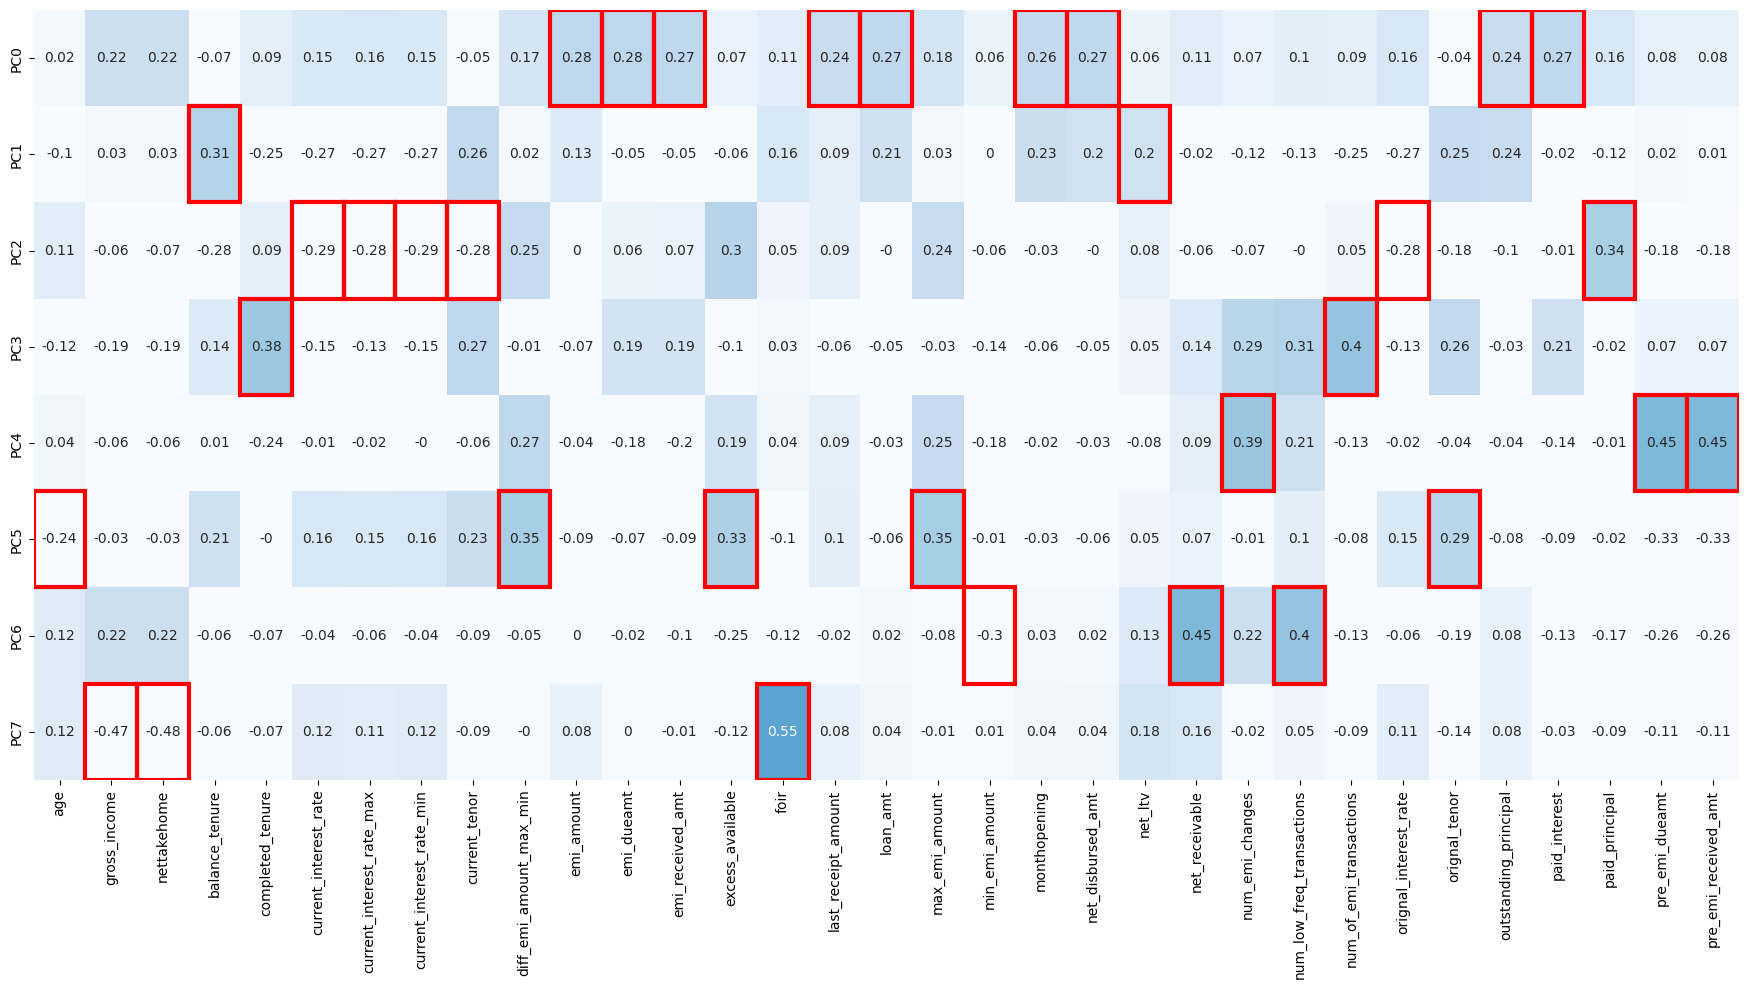

In [75]:
fig,ax = plt.subplots(figsize=(22, 10), facecolor='w', edgecolor='k')
ax = sns.heatmap(df_pca_loading, annot=True, vmax=1.0, vmin=0, cmap='Blues', cbar=False, fmt='.2g', ax=ax,
                 yticklabels=['PC0','PC1','PC2','PC3','PC4','PC5','PC6','PC7'])

column_max = df_pca_loading.abs().idxmax(axis=0)

for col, variable in enumerate(df_pca_loading.columns):
    position = df_pca_loading.index.get_loc(column_max[variable])
    ax.add_patch(Rectangle((col, position),1,1, fill=False, edgecolor='red', lw=3))

####  For every attribute (column, the corresponding PC's cell with the maximum magnitude has been highlighted using Rectangles.
#### For Example, for the age attribute, the PC5 has the maximum magnitude of 0.24

Principal components are linear combinations of the original variables. Each PC is a linear combination of all variables, or scaled variables, as the case may be. It is possible that some of the coefficients are very small numbers or close to 0. We present the linear combinations that make up the first 8 PC’s.

For each PC, the row of length 33 gives the weights with which the corresponding variables need to be multiplied to get the PC. Note that the weights can be positive or negative.

#### With the Business Understanding, the PC's have been renamed. This has been decided based upon the attributes that were highlighted for every PC.

## Note: The Following Data Frame includes the PC Scores

In [76]:
df_pca = pd.DataFrame(df_pca.round(2),columns=['pc_loan_repayment','pc_balance_loan','pc_interest_rate','pc_tenure',
                                  'pc_pre_emi','pc_emi','pc_receiveable','pc_income'])
df_pca.head()

,pc_loan_repayment,pc_balance_loan,pc_interest_rate,pc_tenure,pc_pre_emi,pc_emi,pc_receiveable,pc_income
0,0.15,-4.01,-0.87,2.75,-0.33,0.04,0.24,-0.42
1,0.69,-2.94,0.28,2.39,-0.81,-1.33,-0.26,-0.58
2,0.71,-5.71,0.79,2.01,0.09,-1.09,0.87,0.10
3,3.46,-3.43,-0.08,3.91,-0.43,0.22,1.31,0.36
4,2.27,-3.48,-0.59,3.63,-0.23,0.46,0.26,-0.15


In [77]:
df_pca.shape

(2319, 8)

#### Once the original variables are replaced by the PCs, the latter are used for any further analysis. Just as each observed unit has a particular value of each variable, similarly each observation has a particular value for each PC. These values are called PC scores.

### EDA (Categorical Fields & Principal Components)

In [78]:
df_new = pd.concat([df_cat, df_pca], axis=1)

In [79]:
df_new.shape

(2319, 13)

In [80]:
df_new.head()

,loan_account,gender,marital_status,qualification,city,pc_loan_repayment,pc_balance_loan,pc_interest_rate,pc_tenure,pc_pre_emi,pc_emi,pc_receiveable,pc_income
0,LA492,F,M,UG,MADURAI,0.15,-4.01,-0.87,2.75,-0.33,0.04,0.24,-0.42
1,LA498,M,M,GRAD,MADURAI,0.69,-2.94,0.28,2.39,-0.81,-1.33,-0.26,-0.58
2,LA500,M,M,UG,MADURAI,0.71,-5.71,0.79,2.01,0.09,-1.09,0.87,0.10
3,LA531,M,M,UG,MADURAI,3.46,-3.43,-0.08,3.91,-0.43,0.22,1.31,0.36
4,LA552,M,S,GRAD,MADURAI,2.27,-3.48,-0.59,3.63,-0.23,0.46,0.26,-0.15


In [81]:
df_new.describe(include='all')

,loan_account,gender,marital_status,qualification,city,pc_loan_repayment,pc_balance_loan,pc_interest_rate,pc_tenure,pc_pre_emi,pc_emi,pc_receiveable,pc_income
count,2319,2319,2319,2319,2319,2319.000000,2319.000000,2319.000000,2319.000000,2319.000000,2319.000000,2319.000000,2319.000000
unique,2319,2,2,8,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,LA5737,M,M,UG,MUMBAI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1994,2086,1548,607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.000043,0.000095,0.000065,0.000056,0.000047,-0.000017,-0.000022,0.000047
std,NaN,NaN,NaN,NaN,NaN,3.135112,2.245715,1.766369,1.645681,1.519488,1.385173,1.211514,1.087717
min,NaN,NaN,NaN,NaN,NaN,-5.620000,-6.120000,-4.400000,-5.390000,-4.340000,-4.800000,-5.430000,-4.730000
25%,NaN,NaN,NaN,NaN,NaN,-2.325000,-1.655000,-1.250000,-1.030000,-0.940000,-0.830000,-0.700000,-0.610000
50%,NaN,NaN,NaN,NaN,NaN,-0.620000,-0.020000,-0.330000,0.150000,-0.310000,0.040000,-0.010000,0.050000
75%,NaN,NaN,NaN,NaN,NaN,1.680000,1.610000,0.960000,1.145000,0.730000,0.770000,0.665000,0.710000


<Axes: xlabel='city', ylabel='pc_loan_repayment'>

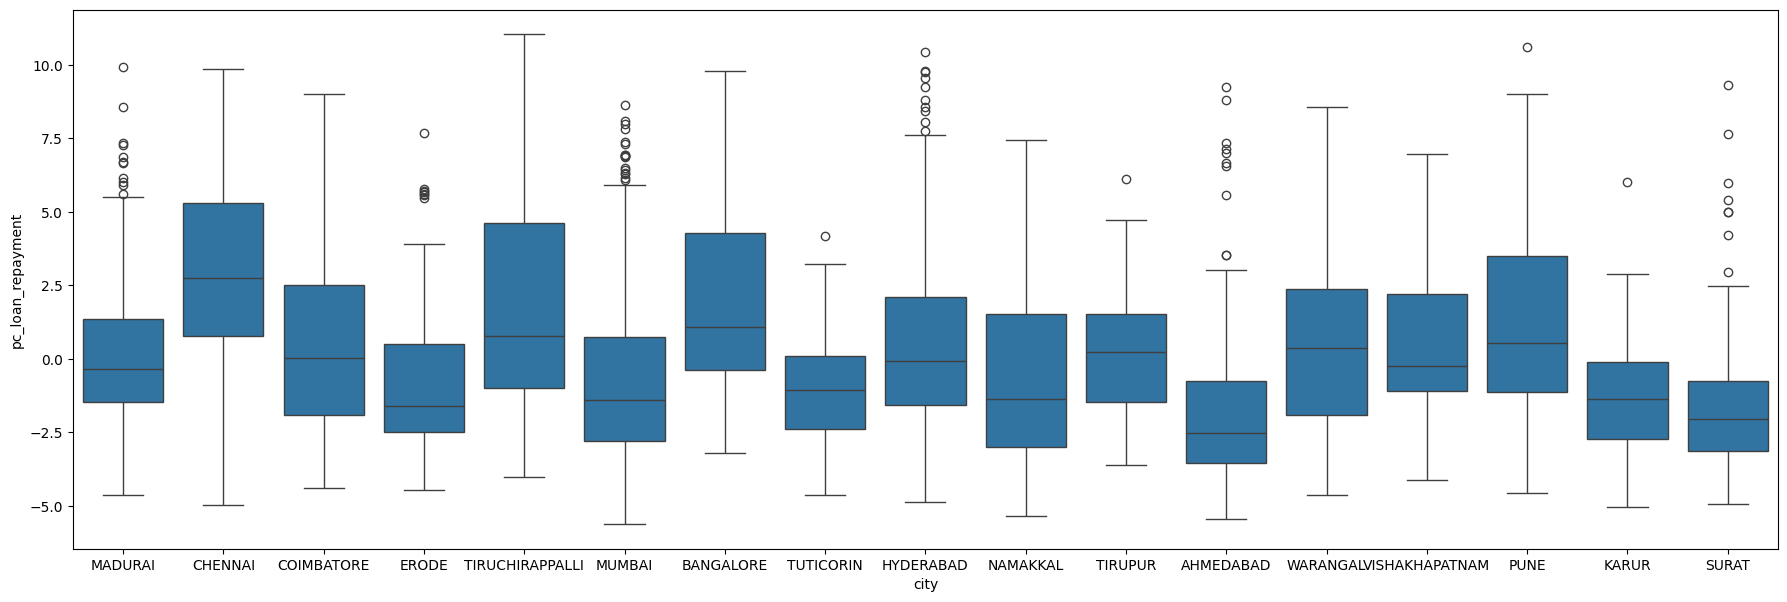

In [82]:
fig,ax = plt.subplots(figsize=(22,7))
sns.boxplot(x='city',y='pc_loan_repayment', data=df_new)

From above plots we observe that for Ahmedabad & Surat the loan repayment amount is comparatively lower than other cities.

Loan repayment amount is highest for Chennai compared to other cities

<Axes: xlabel='city', ylabel='pc_interest_rate'>

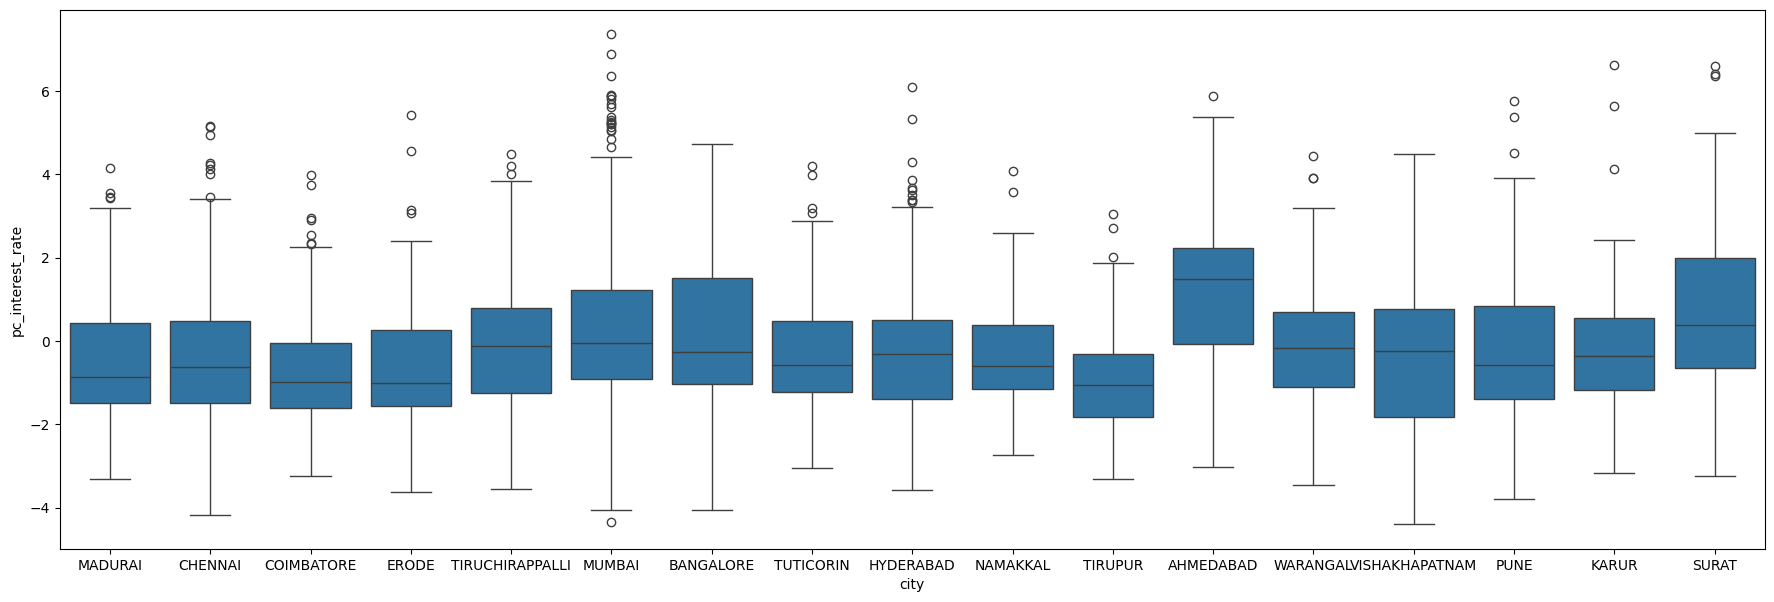

In [83]:
fig,ax = plt.subplots(figsize=(22,7))
sns.boxplot(x='city',y='pc_interest_rate', data=df_new)

Interest rate is highest for Ahmedabad and lowest for Tirupur

<Axes: xlabel='city', ylabel='pc_pre_emi'>

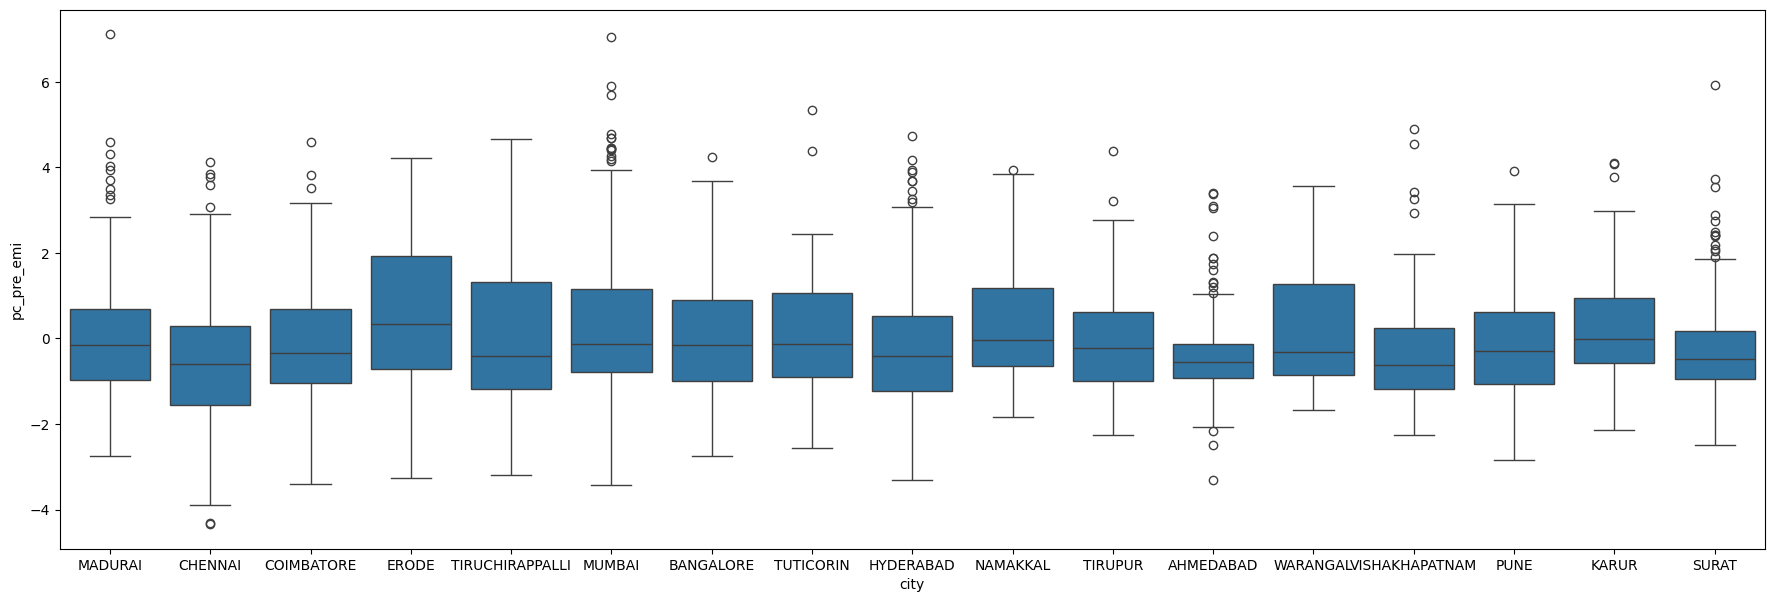

In [84]:
fig,ax = plt.subplots(figsize=(22,7))
sns.boxplot(x='city',y='pc_pre_emi', data=df_new)

City of Erode seems to have highest pre-emi payments

#### Observation

- From above plots we observe that for Ahmedabad city, loan repayment amount is comparatively lower than other cities however, the interest rate charged to the customers is much higher

- For Erode city, loan repayment amount is low, interest rate is comparative high and the pre-emi amount paid by customers from this city is also high

### Apply rules & analyze patterns in data

#### Case 1 - Advance Closure
Customer who
- has to pay lesser loan,
- has done some payment as part of pre-emi and
- has an high income
have higher chances to do *advance payment* and close the loan in advance thus causing loss to the financial institute

Let's create a subset dataframe *df_adv_closure* which satisfies all above conditions and analyze it further

In [85]:
cond1 = df_new.pc_loan_repayment < df_new.pc_loan_repayment.quantile(0.25) # customers paying lesser loan
cond2 = df_new.pc_pre_emi > df_new.pc_pre_emi.quantile(0.75) # customers who have paid high pre-emi
cond3 = df_new.pc_income > df_new.pc_income.quantile(0.75) # customers who have high income
df_adv_closure = df_new[cond1 & cond2 & cond3] # Find customers satisifying all above conditions

In [86]:
df_adv_closure.index

Index([787, 791, 2049, 2216, 2231], dtype='int64')

Above index corresponds to the rows or loan accounts which satisfy the Case 1 conditions. Let's create a new field 'advance_closure' which will hold a value of 1 for above indexed rows

In [87]:
df_adv_closure=df_adv_closure.assign(advance_closure=1)
df_adv_closure.head()

,loan_account,gender,marital_status,qualification,city,pc_loan_repayment,pc_balance_loan,pc_interest_rate,pc_tenure,pc_pre_emi,pc_emi,pc_receiveable,pc_income,advance_closure
787,LA2617,M,M,UG,AHMEDABAD,-2.64,-0.05,-2.59,-1.98,1.20,0.77,-0.80,0.82,1
791,LA2622,M,M,UG,AHMEDABAD,-3.00,-0.51,-2.20,-1.97,1.02,0.51,0.39,1.37,1
2049,LA5094,M,S,UG,MUMBAI,-2.95,0.27,0.43,1.54,0.75,0.28,1.31,1.09,1
2216,LA5467,M,M,UG,MUMBAI,-3.51,-1.56,1.49,-0.91,0.90,-1.29,2.06,0.84,1
2231,LA5511,F,M,UG,MUMBAI,-3.52,1.22,-0.34,-0.05,2.41,-1.60,-0.71,1.15,1


Let's merge *advance_closure* field with our original dataframe for the selected index and analyze further

In [88]:
df_merge = df.merge(
    df_adv_closure[['advance_closure']],
    left_index=True,
    right_index=True,
    how='left')

In [90]:
df_merge.advance_closure.fillna(0, inplace=True)

In [91]:
df_merge.advance_closure.value_counts()

,count
advance_closure,
0.0,2314
1.0,5


#### Analyze data for probable customers who may payoff the loan in advance

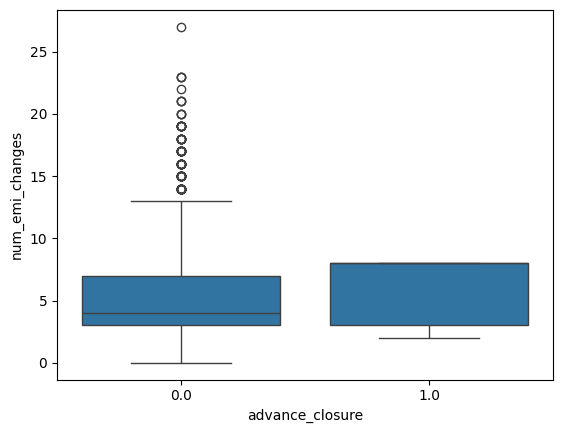

In [92]:
sns.boxplot(x=df_merge['advance_closure'], y=df_merge['num_emi_changes'])
plt.show()


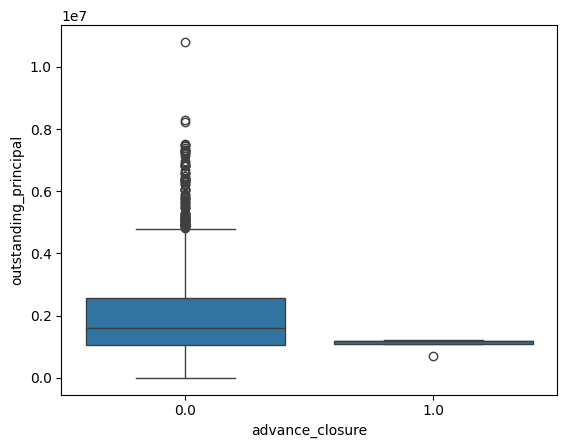

In [93]:
sns.boxplot(x=df_merge['advance_closure'], y=df_merge['outstanding_principal'])
plt.show()


<Axes: xlabel='advance_closure', ylabel='paid_interest'>

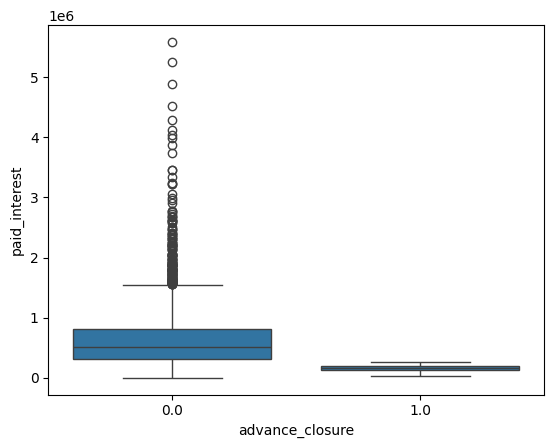

In [94]:
sns.boxplot(x=df_merge['advance_closure'], y=df_merge['paid_interest'])

#### Observation:

28 customers have low outstanding principal, have paid less interest so far and we also see that there are more changes in emi value being paid. Hence, there is high probability that these customers may close the loans in advance

#### Case 2 - Loan Default:

Customers
- with high loan,
- low income and
- high loan interest rate
are probable customers to default.

Let's create a subset dataframe *df_delay_closure* which satisfies all above conditions and analyze further

In [95]:
cond1 = df_new.pc_loan_repayment > df_new.pc_loan_repayment.quantile(0.75)# customers paying higher loan
cond2 = df_new.pc_income < df_new.pc_income.quantile(0.25) # customers with lesser income
cond3 = df_new.pc_interest_rate > df_new.pc_interest_rate.quantile(0.75) # customers paying higher interest

df_delay_closure = df_new[cond1 & cond2 & cond3]# Find customers satisifying all above conditions

In [96]:
df_delay_closure.index

Index([  25,   31,   38,   47,   71,   74,  101,  115,  137,  178,  186,  237,
        242,  274,  316,  345,  364,  409,  445,  486,  492,  609,  700,  701,
        957,  972, 1016, 1067, 1078, 1105, 1122, 1278, 1349, 1364, 1385, 1394,
       1409, 1410, 1413, 1454, 1472, 1700, 1723, 1751],
      dtype='int64')

Above index corresponds to the rows or loan accounts which satisfy the Case 2 conditions. Let's create a new field *'delay_closure'* which will hold a value of 1 for above indexed rows

In [97]:
df_delay_closure = df_delay_closure.assign(delay_closure=1)
df_delay_closure.head()

,loan_account,gender,marital_status,qualification,city,pc_loan_repayment,pc_balance_loan,pc_interest_rate,pc_tenure,pc_pre_emi,pc_emi,pc_receiveable,pc_income,delay_closure
25,LA661,M,M,OTHERS,COIMBATORE,6.57,-2.90,1.63,0.00,-0.01,-2.59,-5.43,-1.49,1
31,LA698,M,M,UG,CHENNAI,8.53,-2.03,3.40,-0.68,-0.97,1.04,-0.60,-2.99,1
38,LA735,M,S,UG,COIMBATORE,4.25,-2.59,1.69,1.25,-0.79,0.85,-2.03,-1.33,1
47,LA769,M,M,POSTGRAD,CHENNAI,8.96,-0.81,4.28,-3.15,-0.79,2.64,-2.32,-2.64,1
71,LA829,M,M,UG,TIRUCHIRAPPALLI,10.29,-1.24,3.84,-1.40,-0.67,1.63,-3.38,-2.44,1


Let's merge the *df_delay_closure* with original dataframe *'df'* and just add the *'delay_closure'* field

In [98]:
#df_merge = df.merge(df_delay_closure['delay_closure'],left_on=df.index, right_index=True,
 #                   right_on=df_delay_closure.index, how='left')
#df_merge.head(79)

In [99]:
df_merge = df.merge(
    df_delay_closure[['delay_closure']],  # Selecting the specific column to merge
    left_index=True,                     # Merge on the index of df
    right_index=True,                    # Merge on the index of df_delay_closure
    how='left'
)

In [102]:
df_merge = df.reset_index().merge(
    df_delay_closure[['delay_closure']].reset_index(),
    on='index',                          # Merge using the reset index as a column
    how='left'
)

In [103]:
df_merge['delay_closure'].fillna(0, inplace=True)

In [104]:
df_merge.delay_closure.value_counts()

,count
delay_closure,
0.0,2275
1.0,44


#### Analyze data for probable customers who may default

<Axes: xlabel='delay_closure', ylabel='net_ltv'>

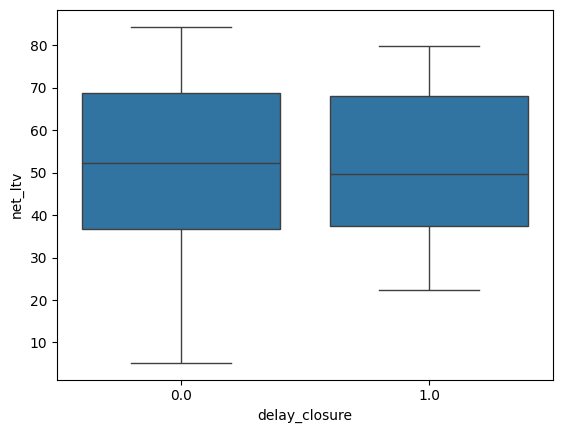

In [105]:
sns.boxplot(x=df_merge.delay_closure, y=df_merge.net_ltv)

<Axes: xlabel='delay_closure', ylabel='outstanding_principal'>

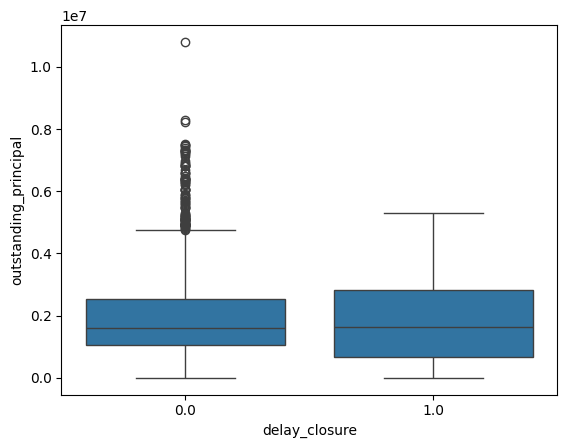

In [106]:
sns.boxplot(x=df_merge.delay_closure, y=df_merge.outstanding_principal)

<Axes: xlabel='delay_closure', ylabel='paid_interest'>

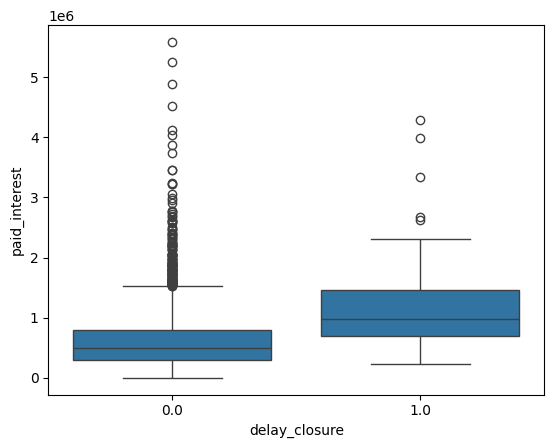

In [107]:
sns.boxplot(x=df_merge.delay_closure, y=df_merge.paid_interest)